# Inertial modes modified by magnetic forces

In [1]:
%load_ext autoreload
%autoreload 2

import os, h5py, pgpy_utils
import numpy as np
import sympy as sym
import matplotlib.pyplot as plt
import utils
from scipy import special as specfun
from scipy import interpolate
import inertial_modes as m_inert
from inertial_modes import s, z, r, phi, theta

---
## Boundary layer correction

In [53]:
map_cyl2sph = {s: r*sym.sin(theta), z: r*sym.cos(theta)}
alpha = sym.Symbol(r'\alpha')

def cross(vA, vB):
    prod_A_B = [
        vA[1]*vB[2] - vA[2]*vB[1],
        vA[2]*vB[0] - vA[0]*vB[2],
        vA[0]*vB[1] - vA[1]*vB[0],
    ]
    return prod_A_B

def dot(vA, vB):
    prod_A_B = vA[0]*vB[0] + vA[1]*vB[1] + vA[2]*vB[2]
    return prod_A_B

def conj(vA):
    v_conj = [sym.conjugate(v_comp) for v_comp in vA]
    return v_conj

def curl_sph_m(v, m_val):
    curl_v = [
        (sym.diff(sym.sin(theta)*v[2], theta) - sym.I*m_val*v[1])/(r*sym.sin(theta)),
        (sym.I*m_val*v[0]/sym.sin(theta) - sym.diff(r*v[2], r))/r,
        (sym.diff(r*v[1], r) - sym.diff(v[0], theta))/r
    ]
    return curl_v

def curl_cyl_m(v, m_val):
    curl_v = [
        sym.I*m_val/s*v[2] - sym.diff(v[1], z),
        sym.diff(v[0], z) - sym.diff(v[2], s),
        sym.diff(s*v[1], s)/s - sym.I*m_val/s*v[0]
    ]
    return curl_v

### Magnetic boundary layer solution

Base state

In [55]:
m_val = 1
i_val = 0
N_geo = 0
symmetry = 'A'
mode_name = f'({m_val},{N_geo},{i_val+1}){symmetry}'
mode_code = f'{m_val}{N_geo}{i_val+1}{symmetry}'
mode_name_spheroidal = f'({m_val},{m_val+2*N_geo+(symmetry=='A')},{i_val+1})'

# Frequency
sigma_0 = m_inert.eigenfreq_inviscid(N_geo, m_val, parity=symmetry.lower(), n=18)[i_val]/2
# sigma_0 = 0.5
lambda_0 = 2*sym.I*sigma_0

# Pressure
p_cyl = m_inert.pressure_mode_invisicid(N_geo, parity=symmetry.lower()).subs({m_inert.m: m_val})
p_sph = p_cyl.subs(map_cyl2sph)

# Velocity
u0_cyl = m_inert.eigenmode_poly_inviscid(N_geo, parity=symmetry.lower())
u0_cyl = [u_comp.subs({m_inert.m: m_val}) for u_comp in u0_cyl]
# u0_cyl = [sym.I*z, -z, -sym.I*s]
u0_sph = [u_comp.subs(map_cyl2sph) for u_comp in u0_cyl]
u0_sph = [
    u0_sph[0]*sym.sin(theta) + u0_sph[2]*sym.cos(theta), 
    u0_sph[0]*sym.cos(theta) - u0_sph[2]*sym.sin(theta),
    u0_sph[1]
]

parsub = {
    m_inert.elamb: lambda_0, 
    m_inert.sigma: sigma_0, 
    alpha: (1 + sym.I*sym.sign(sym.im(lambda_0)))*sym.sqrt(sym.Abs(sym.im(lambda_0))/2)}
print(mode_name, ':', lambda_0)
print(mode_name_spheroidal, ':', lambda_0)

(1,0,1)A : 1.0*I
(1,2,1) : 1.0*I


In [6]:
import iw_magbl

u0_sph, pars = iw_magbl.iw_mode_sph(3, 2, 2, 'S')
B0 = iw_magbl.B0_sph_lib['U']
mag_corr = iw_magbl.magbl_correction(u0_sph, pars, B0)

In [77]:
for comp in u0_sph:
    # display(comp.subs(parsub).simplify())
    display(comp)
    # break

-3*I*r*(\sigma + 1)*sin(\theta)*cos(\theta)/(2*(1 - \sigma**2)) + 3*I*r*sin(\theta)*cos(\theta)/(2*\sigma)

-3*I*r*(\sigma + 1)*cos(\theta)**2/(2*(1 - \sigma**2)) - 3*I*r*sin(\theta)**2/(2*\sigma)

3*r*(\sigma + 1)*cos(\theta)/(2*(1 - \sigma**2))

z-profiles

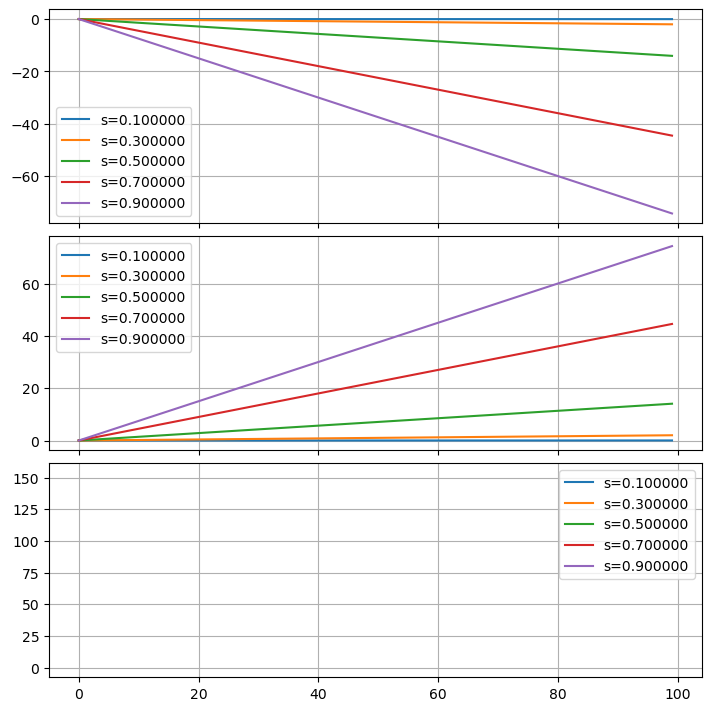

In [360]:
u0_f = [sym.lambdify([m_inert.s, m_inert.z, m_inert.sigma], comp, modules=['scipy', 'numpy'])
    for comp in u0_cyl]

s_locs = [0.1, 0.3, 0.5, 0.7, 0.9]
z_arr = np.linspace(0., 1., num=100)

def plot_profile(f, s_loc, z, sigma, ax, label=None):
    H = np.sqrt(1 - s_loc**2)
    f_vals = f(s_loc, H*z, sigma)
    ax.plot(np.real(f_vals) + np.imag(f_vals), label=label)

fig, axes = plt.subplots(nrows=3, figsize=(7, 7), layout='constrained', sharex=True)
for i_comp in range(3):
    ax = axes[i_comp]
    for i_s, s_tmp in enumerate(s_locs):
        plot_profile(u0_f[i_comp], s_tmp, z_arr, float(sigma_0), ax, label='s=%f' % s_tmp)
    ax.legend(fontsize=10)
    ax.grid(True, which='both')
    
plt.show()

### Poloidal vs toroidal, spherical harmonic

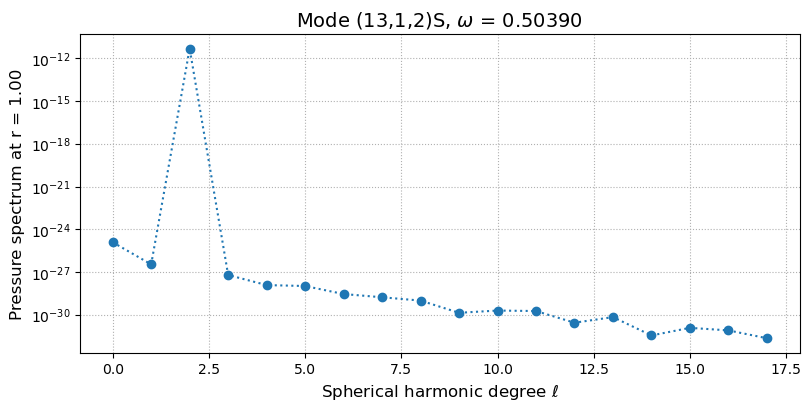

In [22]:
N_SH = 30

p_func = sym.lambdify([r, theta], p_sph.subs(parsub), modules=['numpy', 'scipy'])

r_SH = 1.0
p_SHc = m_inert.transform_SH(lambda cla: p_func(r_SH, cla), N_SH, m_val=m_val)

code_sphtp = 'Mode {}, $\\omega$ = {:.5f}'.format(mode_name, complex(lambda_0).imag)

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
ax.plot(np.abs(p_SHc), 'o:')
ax.set_yscale('log')
ax.set_xlabel('Spherical harmonic degree $\\ell$', fontsize=12)
ax.set_ylabel('Pressure spectrum at r = {:.2f}'.format(r_SH), fontsize=12)
ax.grid(which='both', linestyle=':')
ax.set_title(code_sphtp, fontsize=14)

# fname = f'./runs/Axial_Le_Eeta_mesh_m1/SHc_{mode_code}'
fname = None
if fname is not None:
    plt.savefig(fname + '.png', bbox_inches='tight', dpi=100)
    plt.savefig(fname + '.pdf', bbox_inches='tight')
plt.show()

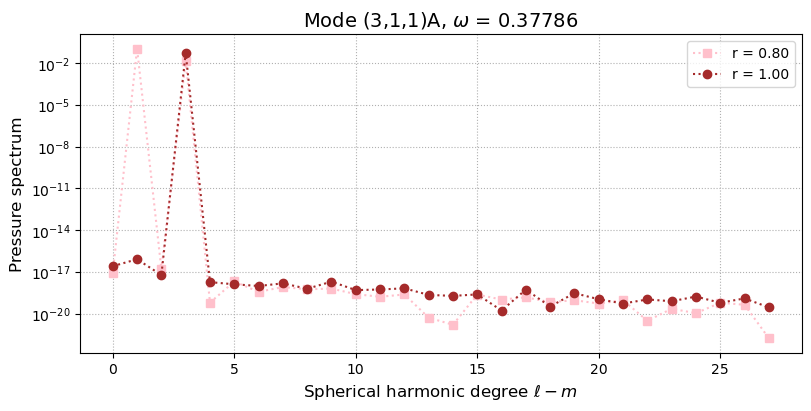

In [8]:
N_SH = 30

p_func = sym.lambdify([r, theta], p_sph.subs(parsub), modules=['numpy', 'scipy'])

# r_colors = plt.cm.tab10(np.linspace(0., 1., num=len(r_list)))

code_sphtp = 'Mode {}, $\\omega$ = {:.5f}'.format(mode_name, complex(lambda_0).imag)

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
r_SH = 0.8
p_SHc = m_inert.transform_SH(lambda cla: p_func(r_SH, cla), N_SH, m_val=m_val)
ax.plot(np.abs(p_SHc), 's:', label='r = {:.2f}'.format(r_SH), color='pink')
r_SH = 1.0
p_SHc = m_inert.transform_SH(lambda cla: p_func(r_SH, cla), N_SH, m_val=m_val)
ax.plot(np.abs(p_SHc), 'o:', label='r = {:.2f}'.format(r_SH), color='brown')
ax.set_yscale('log')
ax.set_xlabel('Spherical harmonic degree $\\ell - m$', fontsize=12)
ax.set_ylabel('Pressure spectrum', fontsize=12)
ax.grid(which='both', linestyle=':')
ax.set_title(code_sphtp, fontsize=14)
ax.legend(fontsize=10)

fname = f'./docs/Inertial_modes/SHc-p_{mode_code}'
# fname = None
if fname is not None:
    plt.savefig(fname + '.png', bbox_inches='tight', dpi=150)
    plt.savefig(fname + '.pdf', bbox_inches='tight')
plt.show()

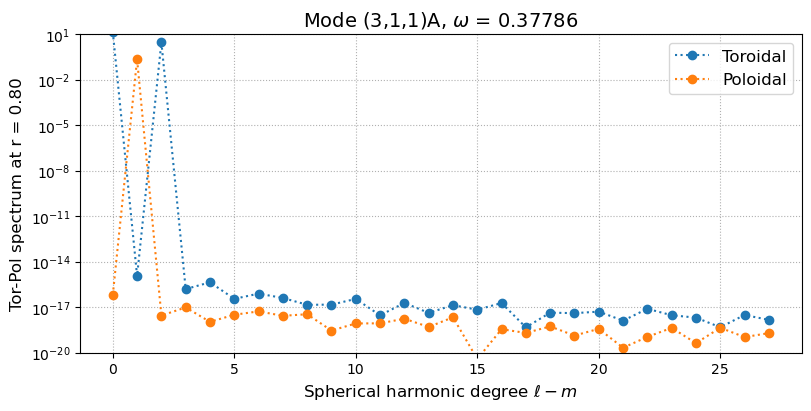

In [9]:
N_SH = 30

u0_r_func = sym.lambdify([r, theta], u0_sph[0].subs(parsub), modules=['numpy', 'scipy'])
curl_u0_r_func = sym.lambdify([r, theta], curl_sph_m(u0_sph, m_val=m_val)[0].subs(parsub), modules=['numpy', 'scipy'])

r_SH = 0.8
pol_SHc = m_inert.transform_SH(lambda z: u0_r_func(r_SH, z), N_SH, m_val=m_val)
tor_SHc = m_inert.transform_SH(lambda z: curl_u0_r_func(r_SH, z), N_SH, m_val=m_val)

i_pol = np.argmax(np.abs(pol_SHc))
i_tor = np.argmax(np.abs(tor_SHc))
# if np.abs(pol_SHc[i_pol]) < 1e-7*np.abs(tor_SHc[i_tor]):
#     code_sphtp = '({},{})T'.format(m_val + i_tor, m_val)
# elif np.abs(tor_SHc[i_tor]) < 1e-7*np.abs(pol_SHc[i_pol]):
#     code_sphtp = '({},{})P'.format(m_val + i_pol, m_val)
# else:
#     code_sphtp = '{:+.2e}({},{})P {:+.2e}({},{})T'.format(
#         np.abs(pol_SHc[i_pol]), m_val + i_pol, m_val,
#         np.abs(tor_SHc[i_tor]), m_val + i_tor, m_val
#     )
code_sphtp = 'Mode {}, $\\omega$ = {:.5f}'.format(mode_name, complex(lambda_0).imag)

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
ax.plot(np.abs(tor_SHc), 'o:', label='Toroidal')
ax.plot(np.abs(pol_SHc), 'o:', label='Poloidal')
ax.set_yscale('log')
ax.grid(which='both', linestyle=':')
ax.set_xlabel('Spherical harmonic degree $\\ell - m$', fontsize=12)
ax.set_ylabel('Tor-Pol spectrum at r = {:.2f}'.format(r_SH), fontsize=12)
ax.set_ylim([1e-20, 10])
ax.legend(fontsize=12)
ax.set_title(code_sphtp, fontsize=14)

fname = f'./docs/Inertial_modes/SHc-u_{mode_code}'
fname = None
if fname is not None:
    plt.savefig(fname + '.png', bbox_inches='tight', dpi=150)
    plt.savefig(fname + '.pdf', bbox_inches='tight')
plt.show()

### Boundary layers

Background field

In [56]:
# B0 = [sym.S.Zero, sym.S.Zero, sym.S.One]                              # Uniform
B0 = [3*s*z/5, sym.S.Zero, (5 - 6*s**2 - 3*z**2)/5]                   # S1
# B0 = [sym.S.Zero, 3*sym.sqrt(3)/2*s*(1 - s**2 - z**2), sym.S.Zero]    # T1
# B0 = [sym.S.Zero, 4*s*z*(s**2 + z**2)*(sym.Rational(3, 2) - s**2 - z**2), sym.S.Zero]                # T2-max@boundary
# B0 = [3*s*z/5, 8*s*z*(1 - s**2 - z**2), (5 - 6*s**2 - 3*z**2)/5]      # S1+T2
# B0 = [sym.S.Zero, 8*s*z*(1 - s**2 - z**2), sym.S.Zero]                # T2
B0_sph = [B_comp.subs(map_cyl2sph).simplify() for B_comp in B0]
B0_sph = [
    B0_sph[0]*sym.sin(theta) + B0_sph[2]*sym.cos(theta), 
    B0_sph[0]*sym.cos(theta) - B0_sph[2]*sym.sin(theta),
    B0_sph[1]
]

# B0_name = r'$\mathbf{B}_0 = \hat{\mathbf{z}}$'
B0_name = 'U'
B0_code = 'U'

Interior solution

In [57]:
order = 0

b1_in_cyl = curl_cyl_m(cross(u0_cyl, B0), m_val=m_val)
for i_order in range(order):
    b1_in_cyl = -curl_cyl_m(curl_cyl_m(b1_in_cyl), m_val=m_val)
b1_in_cyl = [b_comp/(m_inert.elamb**(int(order) + 1)) for b_comp in b1_in_cyl]

b1_in_sph = [b_comp.subs(map_cyl2sph) for b_comp in b1_in_cyl]
b1_in_sph = [
    b1_in_sph[0]*sym.sin(theta) + b1_in_sph[2]*sym.cos(theta), 
    b1_in_sph[0]*sym.cos(theta) - b1_in_sph[2]*sym.sin(theta),
    b1_in_sph[1]
]

First-order boundary layer solution

In [58]:
N_SH = 30

# u0_b = [u_comp.subs({r: 1}).trigsimp() for u_comp in u0_sph]
# b1_in_b = [b_comp.subs({r: 1}).trigsimp() for b_comp in b1_in_sph]

u0_b = [u_comp.subs({r: 1}) for u_comp in u0_sph]
b1_in_b = [b_comp.subs({r: 1}) for b_comp in b1_in_sph]

f_b1r = sym.lambdify([theta,], b1_in_b[0].subs(parsub), modules=['numpy', 'scipy'])
f_b1t_b_int = sym.lambdify([theta,], b1_in_b[1].subs(parsub), modules=['numpy', 'scipy'])
f_b1p_b_int = sym.lambdify([theta,], b1_in_b[2].subs(parsub), modules=['numpy', 'scipy'])
f_b1t_b, f_b1p_b, cf = m_inert.rad2tan_B_single_m(f_b1r, N_SH, m_val)
print(cf)

f_b1t_bl = lambda t: f_b1t_b(t) - f_b1t_b_int(t)
f_b1p_bl = lambda t: f_b1p_b(t) - f_b1p_b_int(t)

[ 6.00000000e-01+0.j  2.64943010e-18-0.j  3.28047477e-18+0.j
 -5.81736164e-19+0.j -5.05222171e-18+0.j -1.73839959e-18+0.j
 -4.03841729e-18+0.j -1.66275765e-18+0.j  3.02374700e-18+0.j
 -1.71603138e-18+0.j  1.74072940e-18+0.j -2.09637187e-19+0.j
 -2.24514018e-19+0.j -4.51187905e-19+0.j  3.28717276e-19+0.j
 -1.03619327e-18+0.j  1.94135673e-18+0.j  1.66982883e-19-0.j
  2.44954995e-20+0.j -7.64940881e-19+0.j  6.30166840e-19+0.j
  2.66039567e-21-0.j  6.73685736e-19+0.j -6.66398091e-19+0.j
  1.05725107e-18+0.j -1.73068869e-19+0.j  1.25835431e-18+0.j
 -8.53809823e-20+0.j  1.87360539e-18+0.j  4.80765747e-20+0.j]


Second-order boundary layer solution

In [59]:
dr_r2_b1r_in_b = sym.diff(r**2*b1_in_sph[0], r).subs({r: 1})
f_dr_r2_b1r_in_b = sym.lambdify([theta,], dr_r2_b1r_in_b.subs(parsub), modules=['numpy', 'scipy'])

def f_b1hr_bl0(t):
    xi_t = np.cos(t)
    # basis = np.stack([specfun.assoc_legendre_p_all(m_val, N_SH, xi_tmp)[0][m_val:, m_val] for xi_tmp in xi_t], axis=0)
    basis = specfun.assoc_legendre_p_all(N_SH, m_val, xi_t)[0, m_val:, m_val].T
    n_arr = np.arange(m_val, N_SH + 1)
    return (-1/complex(parsub[alpha]))*(basis @ (cf*n_arr*(n_arr + 1)) + f_dr_r2_b1r_in_b(t))

f_b1ht_bl0, f_b1hp_bl0, cf_1h = m_inert.rad2tan_B_single_m(f_b1hr_bl0, N_SH, m_val)
print(cf_1h)

f_b1ht_bl1 = f_b1t_bl
f_b1hp_bl1 = f_b1p_bl

[-3.74121009e-16+3.74121009e-16j -2.19952032e-17+2.19952032e-17j
  1.37463269e-17-1.37463269e-17j  7.00713444e-18-7.00713444e-18j
  9.72607093e-18-9.72607093e-18j  1.40125604e-17-1.40125604e-17j
  1.81885245e-17-1.81885245e-17j  1.36584026e-17-1.36584026e-17j
 -3.01029190e-17+3.01029190e-17j  1.23364702e-17-1.23364702e-17j
 -1.67176887e-17+1.67176887e-17j -6.72189061e-19+6.72189061e-19j
  3.31653423e-18-3.31653423e-18j  5.52549071e-18-5.52549071e-18j
  1.59613736e-19-1.59613736e-19j  1.57651260e-17-1.57651260e-17j
 -2.98692426e-17+2.98692426e-17j -2.18996530e-18+2.18996530e-18j
  2.95478744e-19-2.95478744e-19j  1.19763252e-17-1.19763252e-17j
 -1.13313800e-17+1.13313800e-17j  5.80048850e-20-5.80048850e-20j
 -1.08732418e-17+1.08732418e-17j  1.21664442e-17-1.21664442e-17j
 -2.07599230e-17+2.07599230e-17j  3.37338026e-18-3.37338026e-18j
 -2.64705327e-17+2.64705327e-17j  2.73062019e-18-2.73062019e-18j
 -4.16031371e-17+4.16031371e-17j -7.64945418e-19+7.64945418e-19j]


### Eigenvalue correction

Normalizer

In [60]:
u0_mod_sq = dot(conj(u0_sph), u0_sph)
f_u0_mod_sq = sym.lambdify([r, theta], u0_mod_sq.subs(parsub), modules=['numpy', 'scipy'])
# u0_l2 = float(m_inert.int_ball_axisym(u0_mod_sq))
u0_l2 = m_inert.quad_ball_axisym(f_u0_mod_sq)

Interior contribution

In [61]:
L_in_A = cross(curl_sph_m(b1_in_sph, m_val=m_val), B0_sph)
L_in_B = cross(curl_sph_m(B0_sph, m_val=0), b1_in_sph)
L_in_sph = [(L_in_A[i_comp] + L_in_B[i_comp]) for i_comp in range(3)]
# L_in_sph = [(L_in_A[i_comp] + L_in_B[i_comp]).simplify() for i_comp in range(3)]

f_uL_in = sym.lambdify([r, theta], dot(conj(u0_sph), L_in_sph).subs(parsub), modules=['numpy', 'scipy'])
inner_u_L_in = m_inert.quad_ball_axisym(f_uL_in)

First-order boundary layer contribution

In [62]:
f_u0t_b = sym.lambdify([theta,], u0_b[1].subs(parsub), modules=['numpy', 'scipy'])
f_u0p_b = sym.lambdify([theta,], u0_b[2].subs(parsub), modules=['numpy', 'scipy'])
f_B0r = sym.lambdify([theta,], B0_sph[0].subs({r: 1}), modules=['numpy', 'scipy'])
f_surf = lambda t: f_B0r(t)*(
    + np.conj(f_u0t_b(t))*f_b1t_bl(t)
    + np.conj(f_u0p_b(t))*f_b1p_bl(t)
)
inner_u_L_bl = m_inert.quad_sph_surf_axisym(f_surf)

Second-order boundary layer contribution

In [63]:
psi_0 = [cross(u0_sph, curl_sph_m(B0_sph, m_val=0)), curl_sph_m(cross(u0_sph, B0_sph), m_val=m_val)]
psi_0 = [psi_0[0][i_comp] - psi_0[1][i_comp] for i_comp in range(3)]
f_psi_0t = sym.lambdify([theta,], psi_0[1].subs({r: 1, **parsub}), modules=['numpy', 'scipy'])
f_psi_0p = sym.lambdify([theta,], psi_0[2].subs({r: 1, **parsub}), modules=['numpy', 'scipy'])
f_surf_1 = lambda t: f_B0r(t)*(
    + np.conj(f_u0t_b(t))*f_b1ht_bl0(t)
    + np.conj(f_u0p_b(t))*f_b1hp_bl0(t)
)
f_surf_2 = lambda t: (
    + np.conj(f_psi_0t(t))*f_b1t_bl(t)
    + np.conj(f_psi_0p(t))*f_b1p_bl(t)
)/complex(parsub[alpha])
inner_u_L_bl2_1 = m_inert.quad_sph_surf_axisym(f_surf_1)
inner_u_L_bl2_2 = m_inert.quad_sph_surf_axisym(f_surf_2)

In [64]:
Lprime_u0_1 = cross(u0_sph, curl_sph_m(B0_sph, m_val=0)) 
Lprime_u0_2 = curl_sph_m(cross(u0_sph, B0_sph), m_val=m_val)
Lprime_u0 = [Lprime_u0_1[comp] - Lprime_u0_2[comp] for comp in range(3)]
f_Lprime_u0_t_b = sym.lambdify([theta,], Lprime_u0[1].subs({r: 1, **parsub}), modules=['numpy', 'scipy'])
f_Lprime_u0_p_b = sym.lambdify([theta,], Lprime_u0[2].subs({r: 1, **parsub}), modules=['numpy', 'scipy'])
f_surf_prime = lambda t: f_B0r(t)*(
    + np.conj(f_u0t_b(t))*f_b1t_b_int(t)*complex(lambda_0)
    + np.conj(f_u0p_b(t))*f_b1p_b_int(t)*complex(lambda_0)
    + np.conj(f_Lprime_u0_t_b(t))*f_u0t_b(t)
    + np.conj(f_Lprime_u0_p_b(t))*f_u0p_b(t)
)
inner_prime_b = m_inert.quad_sph_surf_axisym(f_surf_prime)

Final contributions

In [65]:
# lambda_2_0 = (inner_u_L_in + inner_u_L_bl)/u0_l2
# lambda_2_1 = inner_u_L_bl2/u0_l2
# print(inner_u_L_in, inner_u_L_bl, lambda_2_0, lambda_2_1, sep='\n')
lambda_2_0_in = inner_u_L_in/u0_l2
lambda_2_0_bl = inner_u_L_bl/u0_l2
lambda_2_0 = lambda_2_0_in + lambda_2_0_bl

lambda_2_1_blh = inner_u_L_bl2_1/u0_l2
lambda_2_1_bl0 = inner_u_L_bl2_2/u0_l2
lambda_2_1 = lambda_2_1_blh + lambda_2_1_bl0

print(lambda_2_0, lambda_2_0_in, lambda_2_0_bl, lambda_2_1, lambda_2_1_blh, lambda_2_1_bl0, sep='\n')

-8.76111114086553e-15j
-8.808977379169486e-15j
4.786623830395643e-17j
(-9.457269379761814e-17-9.457269379761814e-17j)
(-1.2470700305935406e-16-1.2470700305935406e-16j)
(3.013430926173592e-17+3.013430926173592e-17j)


### Batch calculation

In [29]:
m_val = 2
eigs_ref = list()

for n_val in range(9):
    eigs_tmp = m_inert.eigenfreq_inviscid(n_val, m_val, parity='a', n=24)
    eigs_ref.append(1j*eigs_tmp.astype(np.float64))
    eigs_tmp = m_inert.eigenfreq_inviscid(n_val+1, m_val, parity='s', n=24)
    eigs_ref.append(1j*eigs_tmp.astype(np.float64))

eigs_ref = np.concatenate(eigs_ref)
eigs_ref

array([ 0.+0.66666667j, -0.-0.23192505j,  0.+1.23192505j,  0.+0.46690059j,
       -0.-0.76333668j,  0.+1.49643608j, -0.-0.10179042j,  0.+0.88424897j,
       -0.-1.09256839j,  0.+1.64344318j,  0.+0.35953566j, -0.-0.50999352j,
        0.+1.15305755j, -0.-1.30799963j,  0.+1.73397136j, -0.-0.05770957j,
        0.+0.68967539j, -0.-0.80583384j,  0.+1.3358916j , -0.-1.45580853j,
        0.+1.79378495j,  0.+0.2924047j , -0.-0.38410854j,  0.+0.93205452j,
       -0.-1.02457712j,  0.+1.46566011j, -0.-1.5612872j ,  0.+1.83540909j,
       -0.-0.03727171j,  0.+0.56534411j, -0.-0.64007505j,  0.+1.11434027j,
       -0.-1.18982761j,  0.+1.56097884j, -0.-1.63904678j,  0.+1.86555795j,
        0.+0.24643285j, -0.-0.30831905j,  0.+0.7805447j , -0.-0.84266056j,
        0.+1.25444302j, -0.-1.31722706j,  0.+1.63299515j, -0.-1.6979483j ,
        0.+1.88810289j, -0.-0.02608854j,  0.+0.4790234j , -0.-0.53126286j,
        0.+0.95236824j, -0.-1.00483498j,  0.+1.36421937j, -0.-1.41726979j,
        0.+1.68870271j, -

In [30]:
eigs_ref[np.imag(eigs_ref) > 0]

array([0.+0.66666667j, 0.+1.23192505j, 0.+0.46690059j, 0.+1.49643608j,
       0.+0.88424897j, 0.+1.64344318j, 0.+0.35953566j, 0.+1.15305755j,
       0.+1.73397136j, 0.+0.68967539j, 0.+1.3358916j , 0.+1.79378495j,
       0.+0.2924047j , 0.+0.93205452j, 0.+1.46566011j, 0.+1.83540909j,
       0.+0.56534411j, 0.+1.11434027j, 0.+1.56097884j, 0.+1.86555795j,
       0.+0.24643285j, 0.+0.7805447j , 0.+1.25444302j, 0.+1.63299515j,
       0.+1.88810289j, 0.+0.4790234j , 0.+0.95236824j, 0.+1.36421937j,
       0.+1.68870271j, 0.+1.90540684j, 0.+0.21296831j, 0.+0.67081513j,
       0.+1.09128221j, 0.+1.45170853j, 0.+1.73266358j, 0.+1.91897969j,
       0.+0.41558701j, 0.+0.83011985j, 0.+1.20492837j, 0.+1.52248972j,
       0.+1.76795369j, 0.+1.92982347j, 0.+0.1875139j , 0.+0.58787548j,
       0.+0.96347276j, 0.+1.29893174j, 0.+1.58051978j, 0.+1.7967067j ,
       0.+1.93862461j, 0.+0.36699635j, 0.+0.73503717j, 0.+1.07597149j,
       0.+1.37747854j, 0.+1.62866139j, 0.+1.82043954j, 0.+1.9458663j ,
      

In [31]:
m_inert.eigenfreq_inviscid(8, 2, 'a')

array([0.151347501926262, -0.172550119378539, 0.471047584498164,
       -0.492258466559773, 0.778271269728746, -0.799500625797283,
       1.06506237782891, -1.08632537886535, 1.32399361025735,
       -1.34531671493196, 1.54835893429966, -1.56979645594913,
       1.73234707984585, -1.75403706520589, 1.87119101613521,
       -1.89364449958774, 1.96128363596603], dtype=object)

In [32]:
import iw_magbl

B0 = iw_magbl.B0_sph_lib['S1']
u0_sph, pars = iw_magbl.iw_mode_sph(m_val, 8, 2, 'A')
mag_corr = iw_magbl.magbl_correction(u0_sph, pars, B0)

In [33]:
mag_corr

{'ev_Le2_Em0': np.complex128(148.31094382277462j),
 'ev_Le2_Em0_in': np.complex128(46.279029839292356j),
 'ev_Le2_Em0_bl': np.complex128(102.03191398348226j),
 'VSH_Le2_Em0': array([-2.36968138e+02+0.j,  1.12320660e-09+0.j,  7.98516054e+01+0.j,
        -2.61051938e-10+0.j, -4.43077414e+01+0.j,  2.48261496e-11+0.j,
         2.44054380e+01+0.j,  2.14813848e-11+0.j, -1.05797438e+01+0.j,
        -2.29865254e-11+0.j,  8.56278768e-01+0.j,  3.17791101e-11+0.j,
         5.38492255e+00+0.j, -4.76379505e-11+0.j, -8.56315636e+00+0.j,
         5.01036871e-11+0.j,  9.18384507e+00+0.j, -3.60970317e-11+0.j,
         6.90192858e-12+0.j,  1.69446553e-11+0.j,  3.38576985e-12+0.j,
        -1.73307466e-12+0.j, -4.98354452e-12+0.j, -4.72166674e-12+0.j,
         4.31472252e-12+0.j,  6.99515591e-12+0.j, -5.47189509e-12+0.j,
        -4.71213731e-12+0.j,  4.20371246e-12+0.j]),
 'ev_Le2_Emh': np.complex128(-17799.04871777052-17799.04871777052j),
 'ev_Le2_Emh_bl0': np.complex128(-17322.155659753036-17322.1556597

In [81]:
import iw_magbl

m_val = 3
N_max = 5
B0 = iw_magbl.B0_sph_lib['S1']

eigv_corr = np.full((2, 2*N_max + 1, 2*N_max + 1), np.nan, dtype=np.complex128)

for n in range(N_max+1):

    w_list = m_inert.eigenfreq_inviscid(n, m_val, parity='a')
    for k in range(w_list.size):
        u0_sph, pars = iw_magbl.iw_mode_sph(m_val, n, k, 'A')
        mag_corr = iw_magbl.magbl_correction(u0_sph, pars, B0)
        eigv_corr[0, 2*n, k] = mag_corr['ev_Le2_Em0']
        eigv_corr[1, 2*n, k] = mag_corr['ev_Le2_Emh']
        # print(mag_corr['ev_Le2_Em0'].item(), mag_corr['ev_Le2_Emh'].item())
    
    if n == 0:
        continue
    w_list = m_inert.eigenfreq_inviscid(n, m_val, parity='s')
    for k in range(w_list.size):
        u0_sph, pars = iw_magbl.iw_mode_sph(m_val, n, k, 'S')
        mag_corr = iw_magbl.magbl_correction(u0_sph, pars, B0)
        eigv_corr[0, 2*n-1, k] = mag_corr['ev_Le2_Em0']
        eigv_corr[1, 2*n-1, k] = mag_corr['ev_Le2_Emh']
    
    print(f'N={n} finished.')
    

N=1 finished.
N=2 finished.
N=3 finished.
N=4 finished.
N=5 finished.


In [68]:
eigv_corr[np.abs(eigv_corr) < 1e-10] = 0.

In [4]:
m_val = 1
N_max = 5
with h5py.File('./runs/iw_magbl_theory/corrections.h5', 'r') as fp:
    eigv_corr = fp['S1'][f'm{m_val}-N{N_max}'][()]

C:\Users\gentle\AppData\Local\Temp\ipykernel_22936\2256730126.py:8: RuntimeWarning: divide by zero encountered in log10
  ax.text(j, i, '{:.1f}'.format(np.log10(np.abs(M[i, j]))),
C:\Users\gentle\AppData\Local\Temp\ipykernel_22936\2256730126.py:16: RuntimeWarning: invalid value encountered in divide
  imshow_abs_annot(eigv_corr[1]/eigv_corr[0], axes[2], title=r'$|\lambda^{(0,1/2)}|$/$|\lambda^{(0,0)}|$')


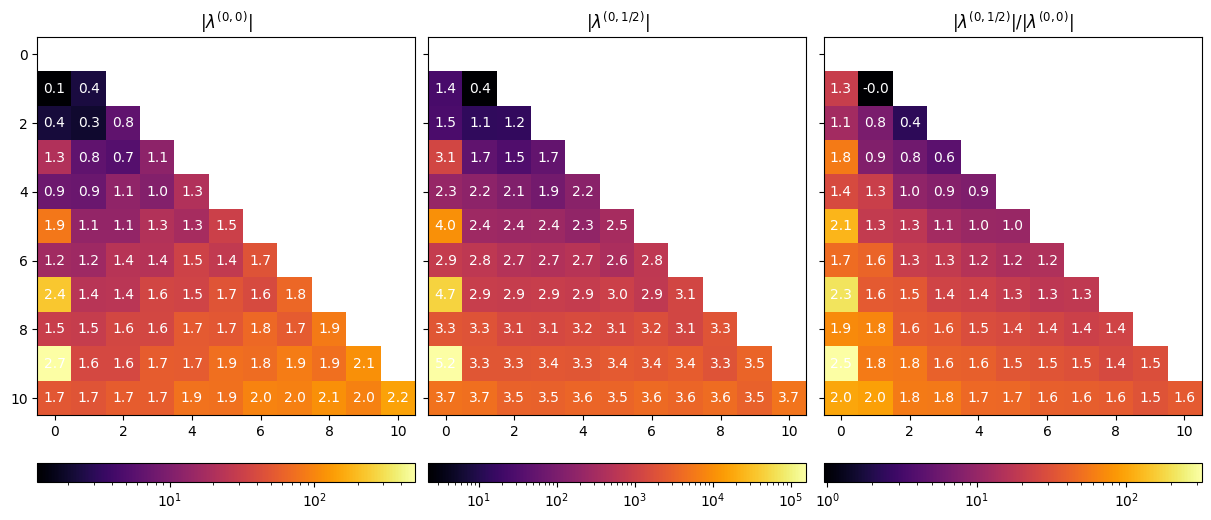

In [5]:
import matplotlib as mpl

def imshow_abs_annot(M, ax, title=None):
    im = ax.imshow(np.abs(M), cmap='inferno', norm=mpl.colors.LogNorm())
    plt.colorbar(im, ax=ax, orientation='horizontal')
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, '{:.1f}'.format(np.log10(np.abs(M[i, j]))),
                ha="center", va="center", color="w")
    if title is not None:
        ax.set_title(title)

fig, axes = plt.subplots(ncols=3, figsize=(12, 5), layout='constrained', sharey=True)
imshow_abs_annot(eigv_corr[0], axes[0], title=r'$|\lambda^{(0,0)}|$')
imshow_abs_annot(eigv_corr[1], axes[1], title=r'$|\lambda^{(0,1/2)}|$')
imshow_abs_annot(eigv_corr[1]/eigv_corr[0], axes[2], title=r'$|\lambda^{(0,1/2)}|$/$|\lambda^{(0,0)}|$')

save_name = f'./runs/iw_magbl_theory/S1_m{m_val}'
save_name = None
if save_name is not None:
    plt.savefig(save_name + '.png', bbox_inches='tight', dpi=120)
    plt.savefig(save_name + '.pdf', bbox_inches='tight')
plt.show()

In [86]:
def get_create_gp(fp, name):
    if name in fp.keys():
        return fp[name]
    gp_new = fp.create_group(name)
    return gp_new

with h5py.File('./runs/iw_magbl_theory/corrections.h5', 'a') as fp:
    gp_bg = get_create_gp(fp, 'S1')
    gp_bg.create_dataset(f'm{m_val}-N{N_max}', data=eigv_corr)

---
## Numerical solutions

In [30]:
import models
from operators.polynomials import SphericalHarmonicMode
from operators.worland_transform import WorlandTransform
from operators.associated_legendre_transform import AssociatedLegendreTransformSingleM
from fields import VectorFieldSingleM

nr, maxnl, m_val = 100, 90, 1

# bg_modes = [SphericalHarmonicMode("pol", 1, 0, "Sqrt[pi/3] r")]
bg_modes = [SphericalHarmonicMode("pol", 1, 0, "1/5 Sqrt[pi/3] r(5 - 3r^2)")]
# bg_modes = [SphericalHarmonicMode("tor", 1, 0, "3 Sqrt[pi] r(1 - r^2)")]
model = models.MagnetoCoriolis_Spin_bAlfven(nr, maxnl, m_val, inviscid=True,
    induction_eq_params={'galerkin': False, 'ideal': False, 'boundary_condition': True})

# model = models.InertialModes(nr, maxnl, m_val, inviscid=True, bc_type=None)

c:\Users\gentle\Documents\Projects\MCmodes\quicc\geometry\spherical\sphere_radius_boundary_worland.py:262: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  return spsp.diags(diags, offsets, (nrows, ncols))


In [31]:
Le_list = np.logspace(-6, -2, num=13)
Em_list = np.logspace(-8, -2, num=19)
Le_mesh, Em_mesh = np.meshgrid(Le_list, Em_list, indexing='ij')

seeds = np.array([
    # -0.0476406312805127j, 
    # +0.5129638919619019j, 
    # +0.514433j,
    # -1.022179200470604j,
    # +1.00000001j
    +0.5653j
])

### Inviscid inertial modes

In [ ]:
Nev = 5
eigenvals = list()
eigenvecs = list()

A, B = model.setup_operator(setup_eigen=True)
for i_target, target in enumerate(seeds):
    w, v = utils.single_eig(A, B, target=target, nev=Nev)
    eigenvals.append(w)
    eigenvecs.append(v.T)

eigenvals = np.array(eigenvals)
eigenvecs = np.array(eigenvecs)

In [32]:
with h5py.File('./runs/Inertial_inviscid/emodes_m1.h5', 'w') as fh5:
    n_gp = len(fh5.keys())
    for i_eig in range(seeds.size):
        gp = fh5.create_group(f'eig_{n_gp}')
        gp.create_dataset('eigenvals', data=eigenvals[i_eig, :])
        gp.create_dataset('eigenvecs', data=eigenvecs[i_eig, ...])
        n_gp += 1

#### Inertial mode visualisation

Prepare spectral transforms

In [42]:
nr, maxnl, m_val = 91, 91, 1

rg = specfun.roots_chebyt(401)[0]
rg = rg[rg.size//2:]
tg = np.linspace(0, np.pi, 201)
rr, tt = np.meshgrid(rg, tg)

worland_transform = WorlandTransform(nr, maxnl, m_val, r_grid=rg)
legendre_transform = AssociatedLegendreTransformSingleM(maxnl, m_val, tg)

In [43]:
with h5py.File('./runs/Inertial_inviscid/emodes_m1.h5', 'r') as fh5:
    for i_gp in range(len(fh5.keys())):
        print(i_gp, fh5[f'eig_{i_gp}']['eigenvals'][()], sep='\n')

0
[-1.65853784e-20+1.j          5.35246057e-18+1.00013892j
  5.09245457e-18+1.00014379j  1.55870667e-17+1.00014902j
 -4.93429681e-19+1.00015464j]


Select a mode

In [44]:
i_eig = 0
i_ev = 0

with h5py.File('./runs/Inertial_inviscid/emodes_m1.h5', 'r') as fh5:
    gp = fh5[f'eig_{i_eig}']
    eigval = gp['eigenvals'][i_ev]
    eigvec = gp['eigenvecs'][i_ev, :]

usp = VectorFieldSingleM(nr, maxnl, m_val, eigvec)
usp.normalise(np.sqrt(usp.energy))
u_sph = usp.physical_field(worland_transform, legendre_transform).data

Visualise

In [45]:
# lon_deg = 30
# lon_rad = np.radians(lon_deg)
max_id = np.unravel_index(np.argmax(np.abs(u_sph['phi'])), u_sph['phi'].shape)
lon_rad = -np.angle(u_sph['phi'][max_id])/m_val + np.pi/15
lon_deg = np.degrees(lon_rad)

X1, X2 = rr*np.sin(tt), rr*np.cos(tt)

fields = {
    'v_r': u_sph['r']*np.exp(1j*m_val*lon_rad), 
    'v_t': u_sph['theta']*np.exp(1j*m_val*lon_rad),
    'v_p': u_sph['phi']*np.exp(1j*m_val*lon_rad), 
    'v_s': (u_sph['r']*np.sin(tt) + u_sph['theta']*np.cos(tt))*np.exp(1j*m_val*lon_rad), 
    'v_z': (u_sph['r']*np.cos(tt) - u_sph['theta']*np.sin(tt))*np.exp(1j*m_val*lon_rad),
}

C:\Users\gentle\AppData\Local\Temp\ipykernel_9892\2081593415.py:47: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cm = ax.pcolormesh(X1, X2, field_plot/norm, vmin=-1e-7, vmax=+1e-7, cmap='coolwarm')


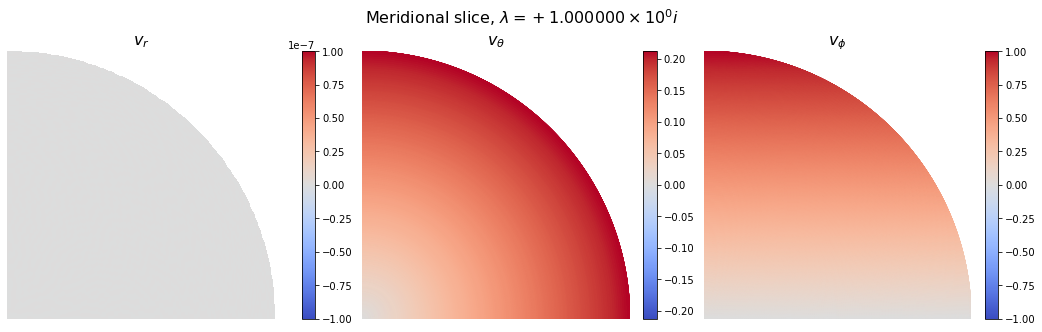

In [46]:
coordinates = 'sph'
override = False
force_lines = False
force_symmetric_cmap = True
domain = 'hemi'
save_name = f"./runs/Inertial_inviscid/v_m1_md_spinover_{coordinates}_{domain}"
save_name = None

if coordinates == 'sph':
    plot_fields = [['v_r', 'v_t', 'v_p'],]
    plot_fnames = [[r"$v_r$", r"$v_\theta$", r"$v_\phi$"],]
else:
    plot_fields = [['v_s', 'v_z', 'v_p'],]
    plot_fnames = [[r"$v_s$", r"$v_z$", r"$v_\phi$"],]

norm = np.abs(np.real(fields['v_p'])).max()
if force_lines:
    x_grid = np.linspace(0., 1., num=100)
    y_grid = np.linspace(-1., 1., num=200)
    XX, YY = np.meshgrid(x_grid, y_grid)
    vs_grid = interpolate.griddata((X1.flatten(), X2.flatten()), np.real(fields['v_s']).flatten(), (XX, YY))
    vz_grid = interpolate.griddata((X1.flatten(), X2.flatten()), np.real(fields['v_z']).flatten(), (XX, YY))

nrows, ncols = len(plot_fields), len(plot_fields[0])
rowheight = 4.5 if domain == 'hemi' else 8.4
cbar_aspect = 20 if domain == 'hemi' else 30
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4.8, nrows*rowheight), layout='constrained')
axes = np.atleast_2d(axes)

for i_r in range(nrows):
    for i_c in range(ncols):
        fname = plot_fields[i_r][i_c]
        ax = axes[i_r][i_c]
        if fname is None:
            ax.remove()
            continue
        field_plot = np.real(fields[fname])
        if np.abs(field_plot/norm).max() > 1e-7:
            if force_symmetric_cmap:
                climit = np.max(np.abs(field_plot/norm))
                cm = ax.pcolormesh(X1, X2, field_plot/norm, shading="gouraud", cmap="coolwarm", vmin=-climit, vmax=+climit)
                plt.colorbar(cm, ax=ax, aspect=cbar_aspect)
            else:
                cm = ax.pcolormesh(X1, X2, field_plot/norm, shading="gouraud", cmap="coolwarm")
                plt.colorbar(cm, ax=ax, aspect=cbar_aspect)
        else:
            cm = ax.pcolormesh(X1, X2, field_plot/norm, vmin=-1e-7, vmax=+1e-7, cmap='coolwarm')
            plt.colorbar(cm, ax=ax, aspect=cbar_aspect)
        
        if force_lines:
            ax.streamplot(XX, YY, vs_grid, vz_grid, color='k', density=1.0, minlength=.5)
        
        ax.set_title(plot_fnames[i_r][i_c], fontsize=16)
        ax.set_aspect('equal', 'box')
        # ax.grid()
        ax.set_xlim([0, 1])
        if domain == 'hemi':
            ax.set_ylim([0, 1])
        else:
            ax.set_ylim([-1, 1])
        ax.axis("off")

real_dec = pgpy_utils.decimal_decomp(eigval.real)
imag_dec = pgpy_utils.decimal_decomp(eigval.imag)
fig.suptitle(r'Meridional slice, $\lambda=%+.6f\times10^{%d}i$' % \
    imag_dec, fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not override:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

### Modified inertial modes

In [137]:
Nev = 2
eigenvals = np.zeros((*Le_mesh.shape, seeds.size, Nev), dtype=np.complex128)
eigenvecs = np.zeros((*Le_mesh.shape, seeds.size, Nev, model.dim['u'] + model.dim['b']), dtype=np.complex128)

n_count = 0
for i_row in range(Le_mesh.shape[0]):
    for i_col in range(Em_mesh.shape[1]):
        Le, Em = Le_mesh[i_row, i_col], Em_mesh[i_row, i_col]
        A, B = model.setup_operator(field_modes=bg_modes, setup_eigen=True, lehnert=Le, magnetic_ekman=Em)
        for i_target, target in enumerate(seeds):
            w, v = utils.single_eig(A, B, target=target, nev=Nev)
            eigenvals[i_row, i_col, i_target, :] = w
            eigenvecs[i_row, i_col, i_target, ...] = v.T
        n_count += 1
        print('{}/{}: Le={:.2e}, Em={:.2e}'.format(n_count, Le_mesh.size, Le, Em))

1/2: Le=1.00e-04, Em=1.00e-07
2/2: Le=1.00e-04, Em=1.00e-06


In [ ]:
i_eig = 0
eig_0 = +1j
eigenvals = eigenvals[..., i_eig, :]
eigenvecs = eigenvecs[..., i_eig, :, :]

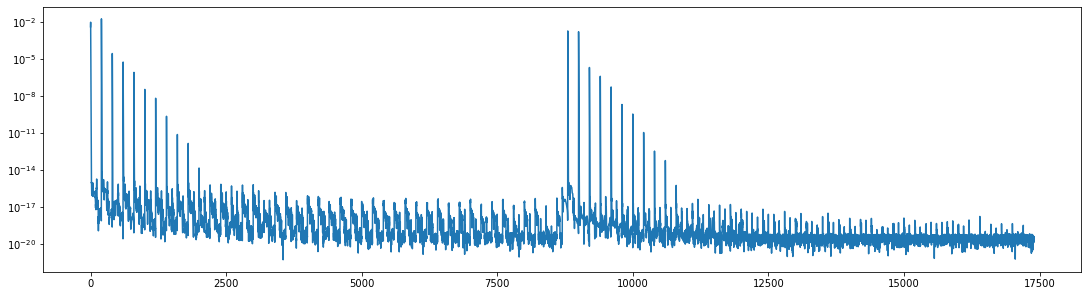

In [106]:
fig, ax = plt.subplots(figsize=(15, 4), layout='constrained')
ax.semilogy(np.abs(eigenvecs[0, 0, 2, 0, -eigenvecs.shape[-1]//2:]))
plt.show()

#### Load pre-computed

In [34]:
fname = './runs/S1_Le_Eeta_mesh_m2/emodes_mesh_N120L100Trace.h5'
with h5py.File(fname, 'r') as fh5:
    Le_list = fh5['Le'][()]
    Em_list = fh5['Em'][()]
    for i_eig in range(len(fh5.keys()) - 2):
        print(fh5[f'eig_{i_eig}']['eigenvals'][4,4,:])

[-1.08523856e-09-0.0577096j  -2.05297070e-07-0.05794245j
 -2.67014027e-06-0.05840239j]
[-2.05084275e-10+0.56534413j -3.09052029e-06+0.56559357j
 -1.09242147e-06+0.56597456j]


In [35]:
i_eig = 1
eig_0 = +0.5653441141518917j

# -0.0476406312805127j    # (3,4,1)S
# +0.5129638919619019j 
# -1.022179200470604j
# +1.0000000j             # (1,0,1)A
# +1.04559704979255j      # (1,2,2)S
# +1.50994070937823j
# -0.0577095733496785j,   # (2,3,1)S
# +0.5653441141518917j,   # (2,4,2)S

with h5py.File(fname, 'r') as fh5:
    gp = fh5[f'eig_{i_eig}']
    basevec = gp['eigenvecs'][0, 0, 0, :]
    eigenvals = gp['eigenvals'][()]
    eigenvecs = gp['eigenvecs'][()]

Choose eigenmodes: inner product criteria

In [36]:
basevec = eigenvecs[0, 0, 0, :]
Ndim = eigenvecs.shape[-1]
scalar_lsq = (eigenvecs[..., :Ndim//2] @ basevec[:Ndim//2].conj()) \
    / (basevec[:Ndim//2].conj().T @ basevec[:Ndim//2])
err = np.linalg.norm(eigenvecs[..., :Ndim//2] - np.tensordot(scalar_lsq, basevec[:Ndim//2], axes=0), axis=-1)
idx = np.argmin(err, axis=-1, keepdims=True)
eigenvals = np.squeeze(np.take_along_axis(eigenvals, idx, axis=2))
eigenvecs = np.squeeze(np.take_along_axis(eigenvecs, idx[..., np.newaxis], axis=2))
eigenvecs /= np.take_along_axis(scalar_lsq, idx, axis=2)
err_fine = np.squeeze(np.take_along_axis(err, idx, axis=2))

Choose eigenmodes: choose first criteria

In [9]:
basevec = eigenvecs[0, 0, 0, :]
Ndim = eigenvecs.shape[-1]
scalar_lsq = (eigenvecs[..., :Ndim//2] @ basevec[:Ndim//2].conj()) \
    / (basevec[:Ndim//2].conj().T @ basevec[:Ndim//2])
err = np.linalg.norm(eigenvecs[..., :Ndim//2] - np.tensordot(scalar_lsq, basevec[:Ndim//2], axes=0), axis=-1)
idx = np.zeros((eigenvals.shape[0], eigenvals.shape[1], 1), dtype=np.int32)
eigenvals = np.squeeze(np.take_along_axis(eigenvals, idx, axis=2))
eigenvecs = np.squeeze(np.take_along_axis(eigenvecs, idx[..., np.newaxis], axis=2))
eigenvecs /= np.take_along_axis(scalar_lsq, idx, axis=2)
err_fine = np.squeeze(np.take_along_axis(err, idx, axis=2))

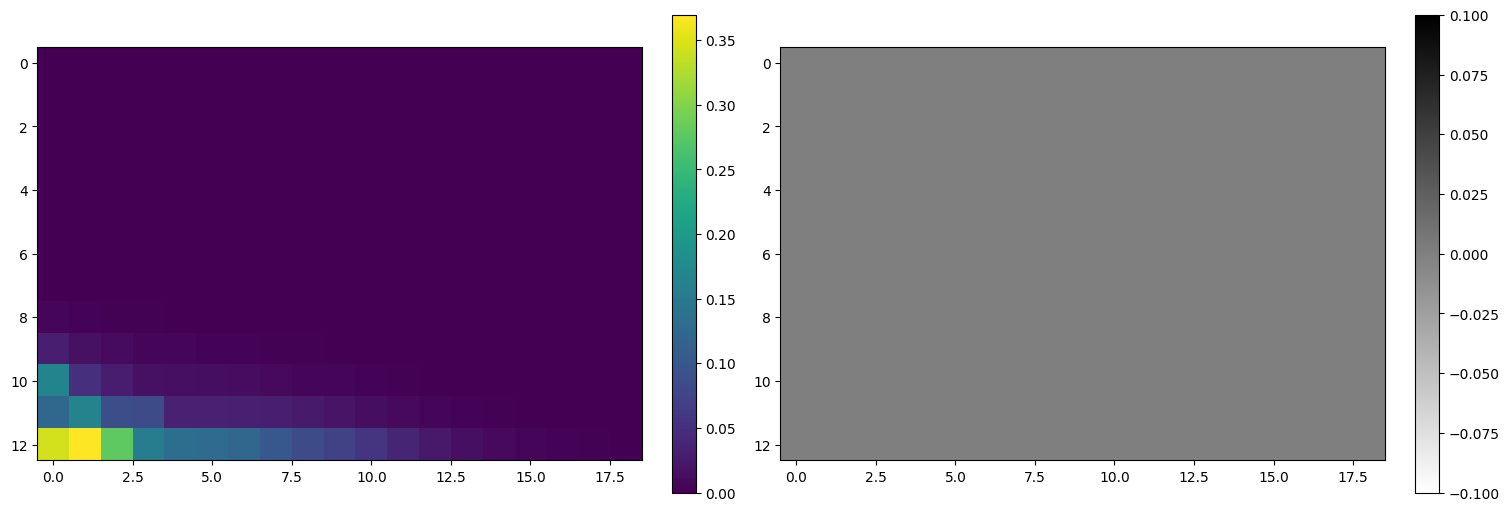

In [37]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5), layout='constrained')

im = axes[0].imshow(err_fine)
# im = axes[0].imshow(err_fine >= 0.1)
plt.colorbar(im, ax=axes[0])

im = axes[1].imshow(np.squeeze(idx), cmap='binary')
plt.colorbar(im, ax=axes[1])

plt.show()

Convergence filtering with lower resolution

In [ ]:
from fields.spectrum import SpectrumOrderingSingleM
import matplotlib as mpl

fname_cmp = './runs/T1_Le_Eeta_mesh_m1/emodes_mesh_N100L90Trace.h5'
eval_thresh = 1e-2
evec_thresh = 3e-2
spec_order = SpectrumOrderingSingleM(120, 100, 3)
spec_order_cmp = SpectrumOrderingSingleM(100, 90, 3)

with h5py.File(fname_cmp, 'r') as fh5:
    gp = fh5[f'eig_{i_eig}']
    eigenvals_cmp = gp['eigenvals'][()]
    eigenvecs_cmp = gp['eigenvecs'][()]

Ndim_cmp = eigenvecs_cmp.shape[-1]
Ntp_cmp = Ndim_cmp // 4
Ntp = Ndim // 4
# eigenvecs_sec = np.concatenate([eigenvecs[..., :Ndim_cmp//2], eigenvecs[..., Ndim//2:Ndim//2+Ndim_cmp//2]], axis=-1)
eigenvecs_sec = np.zeros((*eigenvecs.shape[:-1], Ndim_cmp), dtype=np.complex128)
for l_tmp in range(spec_order_cmp.m, spec_order_cmp.maxnl):
    i_range_cmp = spec_order_cmp.mode_l(l_tmp)
    i_range = spec_order.mode_l(l_tmp)
    eigenvecs_sec[..., 0*Ntp_cmp + i_range_cmp[0] : 0*Ntp_cmp + i_range_cmp[1]] = \
        eigenvecs[..., 0*Ntp + i_range[0] : 0*Ntp + i_range[0] + i_range_cmp[1] - i_range_cmp[0]]
    eigenvecs_sec[..., 1*Ntp_cmp + i_range_cmp[0] : 1*Ntp_cmp + i_range_cmp[1]] = \
        eigenvecs[..., 1*Ntp + i_range[0] : 1*Ntp + i_range[0] + i_range_cmp[1] - i_range_cmp[0]]
    eigenvecs_sec[..., 2*Ntp_cmp + i_range_cmp[0] : 2*Ntp_cmp + i_range_cmp[1]] = \
        eigenvecs[..., 2*Ntp + i_range[0] : 2*Ntp + i_range[0] + i_range_cmp[1] - i_range_cmp[0]]
    eigenvecs_sec[..., 3*Ntp_cmp + i_range_cmp[0] : 3*Ntp_cmp + i_range_cmp[1]] = \
        eigenvecs[..., 3*Ntp + i_range[0] : 3*Ntp + i_range[0] + i_range_cmp[1] - i_range_cmp[0]]
eval_drift = np.abs(eigenvals_cmp - eigenvals[..., np.newaxis])/np.abs(eigenvals[..., np.newaxis])
evec_drift = np.einsum('ijkl,ijl->ijk', 
    eigenvecs_cmp/np.linalg.norm(eigenvecs_cmp, axis=-1, keepdims=True), 
    eigenvecs_sec.conj()/np.linalg.norm(eigenvecs_sec, axis=-1, keepdims=True)
)
evec_drift = np.sqrt(np.abs(1 - np.abs(evec_drift)**2))

conv_filter = ((eval_drift <= eval_thresh) & (evec_drift <= evec_thresh))

fig, axes = plt.subplots(ncols=3, figsize=(15, 4), layout='constrained')
ax = axes[0]
# im = ax.imshow(np.min(evec_drift, axis=-1), cmap='viridis', vmin=0, vmax=0.1)
im = ax.pcolormesh(Em_mesh, Le_mesh, np.min(evec_drift, axis=-1), cmap='viridis', vmin=0, vmax=0.1)
ax.set_xscale('log')
ax.set_yscale('log')
plt.colorbar(im, ax=ax, location='bottom')
ax = axes[1]
# im = ax.imshow(np.log10(np.min(eval_drift, axis=-1)), cmap='viridis')
im = ax.pcolormesh(Em_mesh, Le_mesh, np.min(eval_drift, axis=-1), cmap='viridis', norm=mpl.colors.LogNorm())
ax.set_xscale('log')
ax.set_yscale('log')
plt.colorbar(im, ax=ax, location='bottom')
ax = axes[2]
# im = ax.imshow(np.max(conv_filter, axis=-1), cmap='binary', vmin=0, vmax=1)
im = ax.pcolormesh(Em_mesh, Le_mesh, np.max(conv_filter, axis=-1), cmap='binary', vmin=0, vmax=1)
ax.set_xscale('log')
ax.set_yscale('log')
plt.colorbar(im, ax=ax, location='bottom')
plt.show()

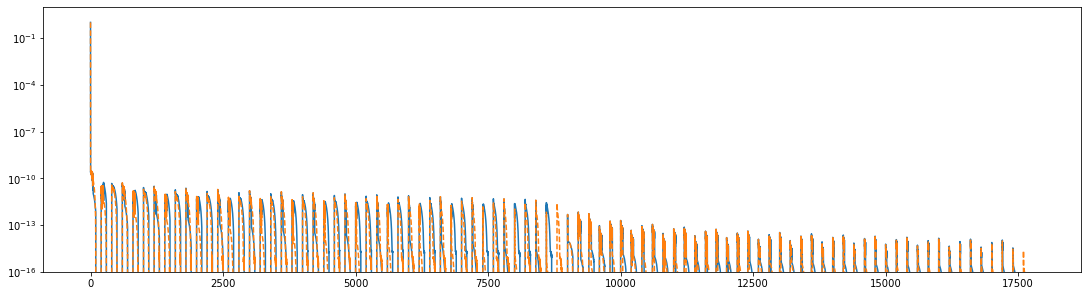

In [26]:
fig, ax = plt.subplots(figsize=(15, 4), layout='constrained')
ax.semilogy(np.abs(eigenvecs_sec[0, 0, :eigenvecs_sec.shape[-1]//2]))
ax.semilogy(np.abs(eigenvecs_cmp[0, 0, 0, :eigenvecs_cmp.shape[-1]//2]), '--')
ax.set_ylim([1e-16, 10])
plt.show()

Optional: Mask unreliable eigenvalues

In [24]:
# eigenvals[np.min(err, axis=-1) >= 0.3] = np.nan + np.nan*1j
eigenvals[~np.max(conv_filter, axis=-1)] = np.nan + np.nan*1j

#### Eigenvalue variation

In [39]:
eigendiff = eigenvals - eig_0

Eigenvalue grid for plotting analytical solution

In [16]:
Em_pred = np.logspace(np.log10(Em_list[0]), np.log10(Em_list[-1]), num=100)
Le_pred = np.logspace(np.log10(Le_list[0]), np.log10(Le_list[-1]), num=100)

##### All eigenvalues

C:\Users\gentle\AppData\Local\Temp\ipykernel_9308\1636260109.py:19: RuntimeWarning: invalid value encountered in log10
  ax.scatter(np.log10(Le_mesh), np.log10(Em_mesh), np.log10(-np.real(eigendiff)))


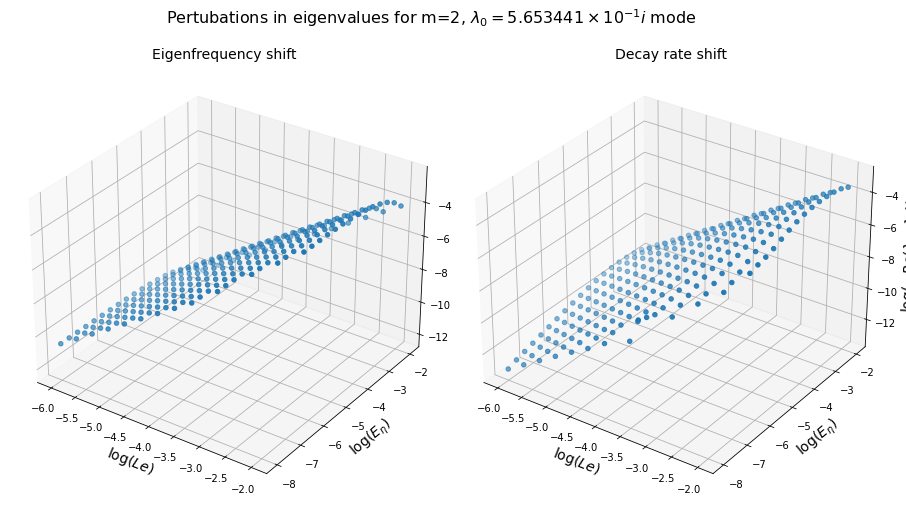

In [151]:
save_name = f'./runs/Axial_Le_Eeta_mesh_m1/eigvals_spinover_Le_Eeta_3d'
save_name = None
overwrite = False

elev_view = 30
azim_view = -55 # - 90 - 15

fig = plt.figure(figsize=(18, 8))

ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.scatter(np.log10(Le_mesh), np.log10(Em_mesh), np.log10(np.sign(np.imag(eigendiff[0, 0]))*np.imag(eigendiff)))
ax.set_xlabel(r'$\log(Le)$', fontsize=14)
ax.set_ylabel(r'$\log(E_\eta)$', fontsize=14)
ax.set_zlabel(r'$\log(|Im(\lambda - \lambda_0)|)$', fontsize=14)
ax.view_init(elev=elev_view, azim=azim_view, roll=0)
ax.set_title('Eigenfrequency shift', fontsize=14)

ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.scatter(np.log10(Le_mesh), np.log10(Em_mesh), np.log10(-np.real(eigendiff)))
ax.set_xlabel(r'$\log(Le)$', fontsize=14)
ax.set_ylabel(r'$\log(E_\eta)$', fontsize=14)
ax.set_zlabel(r'$\log(-Re(\lambda - \lambda_0))$', fontsize=14)
ax.view_init(elev=elev_view, azim=azim_view, roll=0)
ax.set_title('Decay rate shift', fontsize=14)

imag_dec = pgpy_utils.decimal_decomp(eig_0.imag)
fig.suptitle(r'Pertubations in eigenvalues for m=%d, $\lambda_0=%.6f\times10^{%d}i$ mode' % (m_val, *imag_dec,), fontsize=16)

plt.subplots_adjust(wspace=-0.2, hspace=0)
if save_name is not None:
    if os.path.exists(save_name + '.png') and not overwrite:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")
plt.show()

Optional: trim Le & Em

##### Fixed Lehnert number

- Quick check

In [41]:
i_Le = 6

print('Le = {:.3e}'.format(Le_list[i_Le]))
for i_Em, Em in enumerate(Em_list):
    print('Em = {:.3e} | dlambda = {:+.8e} | lambda = {:+.15e}'.format(Em_list[i_Em], eigendiff[i_Le, i_Em], eigenvals[i_Le, i_Em]))

Le = 1.000e-04
Em = 1.000e-08 | dlambda = -8.13166271e-10+2.92504369e-07j | lambda = -8.131662712594588e-10+5.653444066562602e-01j
Em = 2.154e-08 | dlambda = -1.63183625e-09+2.91024564e-07j | lambda = -1.631836250751146e-09+5.653444051764558e-01j
Em = 4.642e-08 | dlambda = -2.04866819e-09+2.90221301e-07j | lambda = -2.048668190880528e-09+5.653444043731926e-01j
Em = 1.000e-07 | dlambda = -3.00792075e-09+2.89292827e-07j | lambda = -3.007920749474765e-09+5.653444034447184e-01j
Em = 2.154e-07 | dlambda = -4.40423287e-09+2.87857461e-07j | lambda = -4.404232867151309e-09+5.653444020093525e-01j
Em = 4.642e-07 | dlambda = -6.40648043e-09+2.85748191e-07j | lambda = -6.406480428115358e-09+5.653443999000823e-01j
Em = 1.000e-06 | dlambda = -9.26220642e-09+2.82652537e-07j | lambda = -9.262206422285205e-09+5.653443968044286e-01j
Em = 2.154e-06 | dlambda = -1.32846650e-08+2.78117215e-07j | lambda = -1.328466502699827e-08+5.653443922691064e-01j
Em = 4.642e-06 | dlambda = -1.88398875e-08+2.71491853e-07

In [278]:
for Em in Em_list:
    print('Em = {:.3e} | dlambda = {:+.8e}'.format(Em, Le_list[i_Le]**2*(lambda_2_0 + lambda_2_1*np.sqrt(Em))))

Em = 1.000e-08 | dlambda = -7.95495129e-12+3.74920450e-08j
Em = 2.154e-08 | dlambda = -1.16762717e-11+3.74883237e-08j
Em = 4.642e-08 | dlambda = -1.71384230e-11+3.74828616e-08j
Em = 1.000e-07 | dlambda = -2.51557647e-11+3.74748442e-08j
Em = 2.154e-07 | dlambda = -3.69236131e-11+3.74630764e-08j
Em = 4.642e-07 | dlambda = -5.41964522e-11+3.74458035e-08j
Em = 1.000e-06 | dlambda = -7.95495129e-11+3.74204505e-08j
Em = 2.154e-06 | dlambda = -1.16762717e-10+3.73832373e-08j
Em = 4.642e-06 | dlambda = -1.71384230e-10+3.73286158e-08j
Em = 1.000e-05 | dlambda = -2.51557647e-10+3.72484424e-08j
Em = 2.154e-05 | dlambda = -3.69236131e-10+3.71307639e-08j
Em = 4.642e-05 | dlambda = -5.41964522e-10+3.69580355e-08j
Em = 1.000e-04 | dlambda = -7.95495129e-10+3.67045049e-08j
Em = 2.154e-04 | dlambda = -1.16762717e-09+3.63323728e-08j
Em = 4.642e-04 | dlambda = -1.71384230e-09+3.57861577e-08j
Em = 1.000e-03 | dlambda = -2.51557647e-09+3.49844235e-08j
Em = 2.154e-03 | dlambda = -3.69236131e-09+3.38076387e-0

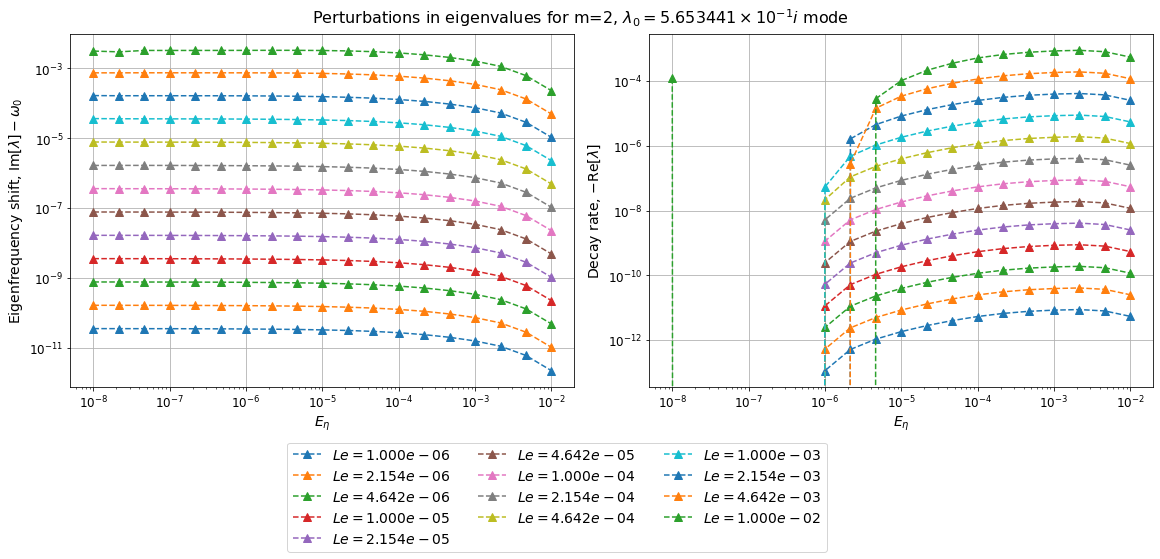

In [91]:
save_name = './runs/Axial_Le_Eeta_mesh/eigvals_spinover_fixedLe_all'
save_name = None
overwrite = False

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), layout='constrained')

plot_idx = np.arange(Le_list.size)
# plot_idx = [0,]

ax = axes[0]
for i_Le, Le in enumerate(Le_list[plot_idx]):
    ax.loglog(Em_list, np.sign(np.imag(eigendiff[6, 6]))*np.imag(eigendiff[i_Le, :]), '^--', markersize=8, 
              label=r'$Le=%.3e$' % (Le,))
ax.grid(which='major')
ax.tick_params(which='major', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
ax.set_ylabel('Eigenfrequency shift, $\mathrm{Im}[\lambda] - \omega_0$', fontsize=14)
# ax.legend(fontsize=12)

ax = axes[1]
line_handles = list()
for i_Le, Le in enumerate(Le_list[plot_idx]):
    line = ax.loglog(Em_list, - np.real(eigendiff[i_Le, :]), '^--', markersize=8, label=r'$Le=%.3e$' % (Le,))
    line_handles.append(*line)
ax.grid(which='major')
ax.tick_params(which='major', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
ax.set_ylabel('Decay rate, $-\mathrm{Re}[\lambda]$', fontsize=14)
# ax.legend(fontsize=12)

real_dec = pgpy_utils.decimal_decomp(eig_0.real)
imag_dec = pgpy_utils.decimal_decomp(eig_0.imag)
# fig.suptitle(r'Meridional slice, $\lambda=%+.6f\times10^{%d}i$' % \
#     imag_dec, fontsize=16)
fig.suptitle(r'Perturbations in eigenvalues for m=%d, $\lambda_0=%.6f\times10^{%d}i$ mode' % (m_val, *imag_dec,), fontsize=16)
fig.legend(handles=line_handles, ncol=3, bbox_to_anchor=(0.72, 0.0), fontsize=14)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not overwrite:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

In [51]:
lambda_2_0

0.0358579581928254j

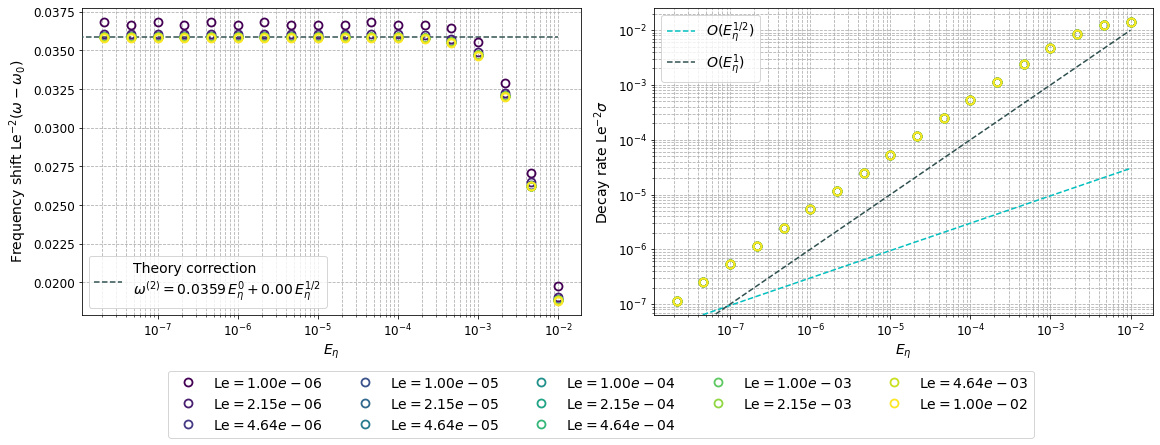

In [ ]:
save_name = f'./runs/T1_Le_Eeta_mesh_m1/evals-Em_{mode_code}-{B0_code}_log'
# save_name = None
overwrite = False

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5), layout='constrained')

plot_Le_range = [1e-7, 1e-2]
plot_Em_range = [2e-8, 1e-2]
plot_Le_idx = (Le_list >= plot_Le_range[0]) & (Le_list <= plot_Le_range[-1])
plot_Em_idx = (Em_list >= plot_Em_range[0]) & (Em_list <= plot_Em_range[-1])
clist = plt.cm.viridis(np.linspace(0, 1, num=np.sum(plot_Le_idx)))
# clist = plt.cm.turbo(np.linspace(0, 1, num=np.sum(plot_Le_idx)+2)[1:-1])
# clist = plt.cm.tab20((np.arange(np.sum(plot_Le_idx) + 0.5))/20)

ax = axes[0]
sgn_omega = np.sign(np.imag(eigendiff[4, 4]))
sgn_omega = 1
for i_Le, Le in enumerate(Le_list):
    if not plot_Le_idx[i_Le]:
        continue
    ax.plot(Em_list[plot_Em_idx], sgn_omega*np.imag(eigendiff[i_Le, plot_Em_idx])/Le**2, 'o', markersize=8, 
        color=clist[i_Le], markerfacecolor='none', markeredgewidth=1.8,
        label=r'$\mathrm{Le}=%.2e$' % (Le,), zorder=5)
    # ax.plot(
    #     Em_list[plot_Em_idx], 
    #     np.imag(eigendiff[i_Le, plot_Em_idx])/Le**2 - (np.imag(lambda_2_0)), 
    #     'o', markersize=8, color=clist[i_Le], markerfacecolor='none', markeredgewidth=1.8,
    #     label=r'$\mathrm{Le}=%.2e$' % (Le,), zorder=5)
ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_yscale('symlog', linthresh=1e-7)
ax.autoscale(True)
ax.get_xlim()
# print(ax.get_xlim())
ax.autoscale(enable=False, axis='both')
line_theory = ax.plot(
    Em_pred, sgn_omega*(np.imag(lambda_2_0)*np.ones_like(Em_pred) + np.imag(lambda_2_1)*np.sqrt(Em_pred)), 
    '--', color='darkslategray', zorder=4,
    label='Theory correction \n$\\omega^{(2)}=%.4f \, E_\eta^0 %+.2f \, E_\eta^{1/2}$' % (np.imag(lambda_2_0), np.imag(lambda_2_1)),
)
# line1, = ax.plot(Em_pred, -1e-5*np.sqrt(Em_pred), '--', color='darkslategray', label=r'$E_\eta^{1/2}$', zorder=4)
# line2, = ax.plot(Em_pred, -1e+2*Em_pred**2, '--', color='cyan', label=r'$E_\eta^{2}$', zorder=4)
# line_theory = [line1, line2]
ax.grid(which='both', linestyle='--')
ax.tick_params(which='major', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
if sgn_omega >= 0:
    ax.set_ylabel(r'Frequency shift $\mathrm{Le}^{-2}(\omega - \omega_0)$', fontsize=14)
else:
    ax.set_ylabel(r'Frequency shift $\mathrm{Le}^{-2}(\omega_0 - \omega)$', fontsize=14)
ax.legend(handles=line_theory, fontsize=14).set_zorder(3)

ax = axes[1]
line_handles = list()
for i_Le, Le in enumerate(Le_list):
    if not plot_Le_idx[i_Le]:
        continue
    line = ax.plot(Em_list[plot_Em_idx], - np.real(eigendiff[i_Le, plot_Em_idx])/Le**2, 'o', markersize=8, 
        color=clist[i_Le], markerfacecolor='none', markeredgewidth=1.8,
        label=r'$\mathrm{Le}=%.2e$' % Le, zorder=5)
    line_handles.append(*line)
ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_yscale('symlog', linthresh=0.1)
ax.autoscale(True)
ax.get_xlim()
# ax.set_ylim(-1, 10)
ax.autoscale(enable=False, axis='both')
# line_theory = ax.plot(
#     Em_pred, -np.real(lambda_2_0) -np.real(lambda_2_1)*np.sqrt(Em_pred), '--', color='darkslategray', 
#     label='Theory correction \n$\\sigma^{(2)}=%+.2f \, E_\eta^{0} %+.2f \, E_\eta^{1/2}$' % (-np.real(lambda_2_0), -np.real(lambda_2_1)), zorder=4
# )
line1, = ax.plot(Em_pred, 3e-4*np.sqrt(Em_pred), '--', color='c', label=r'$O(E_\eta^{1/2})$', zorder=4)
line2, = ax.plot(Em_pred, Em_pred, '--', color='darkslategray', label=r'$O(E_\eta^{1})$', zorder=4)
line_theory = [line1, line2]

ax.grid(which='both', linestyle='--')
ax.axhline(y=0, color='gray')
ax.tick_params(which='major', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
ax.set_ylabel('Decay rate $\mathrm{Le}^{-2}\sigma$', fontsize=14)
ax.legend(handles=line_theory, fontsize=14)

real_dec = pgpy_utils.decimal_decomp(eig_0.real)
imag_dec = pgpy_utils.decimal_decomp(eig_0.imag)
# fig.suptitle(r'Perturbations in eigenvalues for m=%d, $\lambda_0=%.6f\times10^{%d}i$ mode' % (m_val, *imag_dec,), fontsize=16)
fig.legend(handles=line_handles, ncol=5, bbox_to_anchor=(0.9, 0.0), fontsize=14)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not overwrite:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

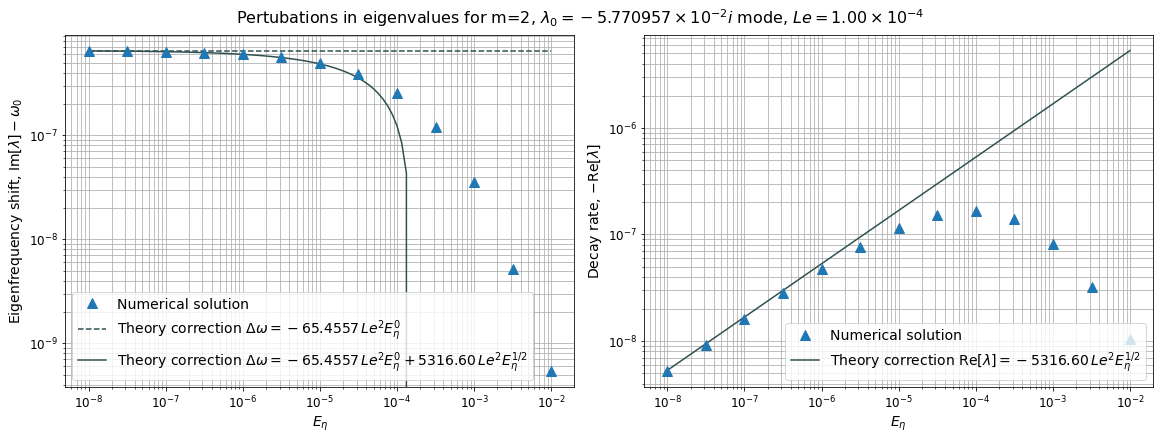

In [184]:
i_par_plot = 4
Le_val = Le_list[i_par_plot]
save_name = './runs/Axial_Le_Eeta_mesh/eigvals_spinover_fixedLe_{:.1e}_bl12'.format(Le_val)
save_name = None
overwrite = False

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), layout='constrained')

ax = axes[0]
sign = np.sign(np.imag(eigendiff[i_par_plot, 0]))
ax.plot(Em_list, sign*np.imag(eigendiff[i_par_plot, :]), '^', markersize=10, label='Numerical solution', zorder=5)
ax.plot(
    Em_pred, Le_val**2*sign*(np.imag(lambda_2_0)*np.ones_like(Em_pred)), 
    '--', color='darkslategray', 
    label='Theory correction $\\Delta\\omega=%.4f \, Le^2 E_\eta^0$' % (
        np.imag(lambda_2_0)
    )
)
ax.plot(
    Em_pred, Le_val**2*sign*(np.imag(lambda_2_0)*np.ones_like(Em_pred) + np.imag(lambda_2_1)*np.sqrt(Em_pred)), 
    '-', color='darkslategray', 
    label='Theory correction $\\Delta\\omega=%.4f \, Le^2 E_\eta^0 %+.2f \, Le^2 E_\eta^{1/2}$' % (
        np.imag(lambda_2_0), np.imag(lambda_2_1)
    )
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(which='both')
ax.tick_params(which='both', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
ax.set_ylabel('Eigenfrequency shift, $\mathrm{Im}[\lambda] - \omega_0$', fontsize=14)
ax.legend(fontsize=14, loc=3)

ax = axes[1]
line_handles = list()
ax.loglog(Em_list, - np.real(eigendiff[i_par_plot, :]), '^', markersize=10, label='Numerical solution', zorder=5)
# ax.loglog(Em_list[1:-2], 0.8*(-np.real(eigendiff[i_par_plot, 4])/Em_list[4]**(1/2))*Em_list[1:-2]**(1/2), '-', 
#     color='darkslategray', label=r'Scaling $E_\eta^{1/2}$')
ax.loglog(
    Em_pred, -np.real(lambda_2_1)*Le_val**2*np.sqrt(Em_pred), '-', 
    color='darkslategray', 
    label='Theory correction $\\mathrm{Re}[\\lambda]=%+.2f \, Le^2 E_\eta^{1/2}$' % (
        np.real(lambda_2_1)
    )
)
ax.grid(which='both')
ax.tick_params(which='both', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
ax.set_ylabel('Decay rate, $-\mathrm{Re}[\lambda]$', fontsize=14)
ax.legend(fontsize=14, loc=4)

real_dec = pgpy_utils.decimal_decomp(eig_0.real)
imag_dec = pgpy_utils.decimal_decomp(eig_0.imag)
Le_dec = pgpy_utils.decimal_decomp(Le_val)
# fig.suptitle(r'Meridional slice, $\lambda=%+.6f\times10^{%d}i$' % \
#     imag_dec, fontsize=16)
fig.suptitle(r'Pertubations in eigenvalues for m=%d, $\lambda_0=%.6f\times10^{%d}i$ mode, $Le = %.2f\times10^{%d}$' % 
    (m_val, *imag_dec, *Le_dec), fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not overwrite:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

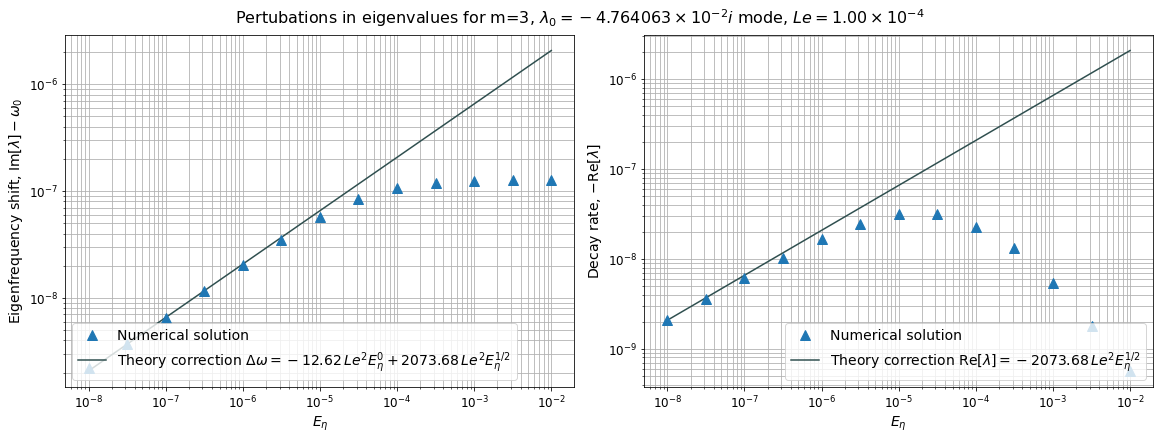

In [32]:
i_par_plot = 4
Le_val = Le_list[i_par_plot]
save_name = './runs/Axial_Le_Eeta_mesh/eigvals_spinover_fixedLe_{:.1e}_bl12'.format(Le_val)
save_name = None
overwrite = False

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), layout='constrained')

ax = axes[0]
sign = np.sign(np.imag(eigendiff[i_par_plot, 0]))
sign2 = np.sign(np.imag(eigendiff[i_par_plot, 0]) - Le_val**2*np.imag(lambda_2_0))
ax.plot(Em_list, sign2*(np.imag(eigendiff[i_par_plot, :]) - Le_val**2*(np.imag(lambda_2_0))), '^', markersize=10, label='Numerical solution', zorder=5)
ax.plot(
    Em_pred, Le_val**2*sign2*(np.imag(lambda_2_1)*np.sqrt(Em_pred)), 
    '-', color='darkslategray', 
    label='Theory correction $\\Delta\\omega=%.2f \, Le^2 E_\eta^0 %+.2f \, Le^2 E_\eta^{1/2}$' % (
        np.imag(lambda_2_0), np.imag(lambda_2_1)
    )
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(which='both')
ax.tick_params(which='both', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
ax.set_ylabel('Eigenfrequency shift, $\mathrm{Im}[\lambda] - \omega_0$', fontsize=14)
ax.legend(fontsize=14, loc=3)

ax = axes[1]
line_handles = list()
ax.loglog(Em_list, - np.real(eigendiff[i_par_plot, :]), '^', markersize=10, label='Numerical solution', zorder=5)
# ax.loglog(Em_list[1:-2], 0.8*(-np.real(eigendiff[i_par_plot, 4])/Em_list[4]**(1/2))*Em_list[1:-2]**(1/2), '-', 
#     color='darkslategray', label=r'Scaling $E_\eta^{1/2}$')
ax.loglog(
    Em_pred, -np.real(lambda_2_1)*Le_val**2*np.sqrt(Em_pred), '-', 
    color='darkslategray', 
    label='Theory correction $\\mathrm{Re}[\\lambda]=%+.2f \, Le^2 E_\eta^{1/2}$' % (
        np.real(lambda_2_1)
    )
)
ax.grid(which='both')
ax.tick_params(which='both', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
ax.set_ylabel('Decay rate, $-\mathrm{Re}[\lambda]$', fontsize=14)
ax.legend(fontsize=14, loc=4)

real_dec = pgpy_utils.decimal_decomp(eig_0.real)
imag_dec = pgpy_utils.decimal_decomp(eig_0.imag)
Le_dec = pgpy_utils.decimal_decomp(Le_val)
# fig.suptitle(r'Meridional slice, $\lambda=%+.6f\times10^{%d}i$' % \
#     imag_dec, fontsize=16)
fig.suptitle(r'Pertubations in eigenvalues for m=%d, $\lambda_0=%.6f\times10^{%d}i$ mode, $Le = %.2f\times10^{%d}$' % 
    (m_val, *imag_dec, *Le_dec), fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not overwrite:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

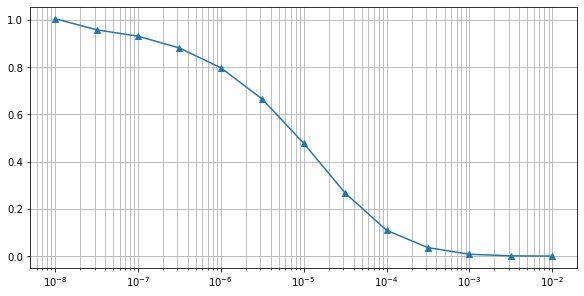

In [30]:
fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
ax.semilogx(Em_list, np.real(eigendiff[i_par_plot, :])/np.real(lambda_2_1*Le_val**2*np.sqrt(Em_list)), '^-')
ax.grid(which='both')
plt.show()

##### Fixed magnetic Ekman number

- Quick check

In [45]:
i_Em = 6

print('Em = {:.3e}'.format(Em_list[i_Em]))
for i_Le, Le in enumerate(Le_list):
    print('Le = {:.3e} | lambda = {:.15e} | dlambda = {:.8e}'.format(Le_list[i_Le], eigenvals[i_Le, i_Em], eigendiff[i_Le, i_Em]))

Em = 1.000e-06
Le = 1.000e-06 | lambda = -9.268831842156085e-13+5.653441141801534e-01j | dlambda = -9.26883184e-13+2.82617263e-11j
Le = 2.154e-06 | lambda = -4.302199221477771e-12+5.653441142830888e-01j | dlambda = -4.30219922e-12+1.31197164e-10j
Le = 4.642e-06 | lambda = -1.996894033990049e-11+5.653441147608581e-01j | dlambda = -1.99689403e-11+6.08966433e-10j
Le = 1.000e-05 | lambda = -9.268715724200562e-11+5.653441169784625e-01j | dlambda = -9.26871572e-11+2.82657087e-09j
Le = 2.154e-05 | lambda = -4.302044318332785e-10+5.653441272716524e-01j | dlambda = -4.30204432e-10+1.31197607e-08j
Le = 4.642e-05 | lambda = -1.996598537208957e-09+5.653441750482707e-01j | dlambda = -1.99659854e-09+6.08963791e-08j
Le = 1.000e-04 | lambda = -9.262206422285205e-09+5.653443968044286e-01j | dlambda = -9.26220642e-09+2.82652537e-07j
Le = 2.154e-04 | lambda = -4.288085029969183e-08+5.653454260349192e-01j | dlambda = -4.28808503e-08+1.31188303e-06j
Le = 4.642e-04 | lambda = -1.966814385327834e-07+5.653502

In [75]:
for Le in Le_list:
    print('{:.8e}'.format(Le**2*(lambda_2_0 + lambda_2_1*np.sqrt(Em_list[i_Em]))))

-7.95495129e-16+3.74920450e-12j
-3.69236131e-15+1.74022658e-11j
-1.71384230e-14+8.07741625e-11j
-7.95495129e-14+3.74920450e-10j
-3.69236131e-13+1.74022658e-09j
-1.71384230e-12+8.07741625e-09j
-7.95495129e-12+3.74920450e-08j
-3.69236131e-11+1.74022658e-07j
-1.71384230e-10+8.07741625e-07j
-7.95495129e-10+3.74920450e-06j
-3.69236131e-09+1.74022658e-05j
-1.71384230e-08+8.07741625e-05j
-7.95495129e-08+3.74920450e-04j


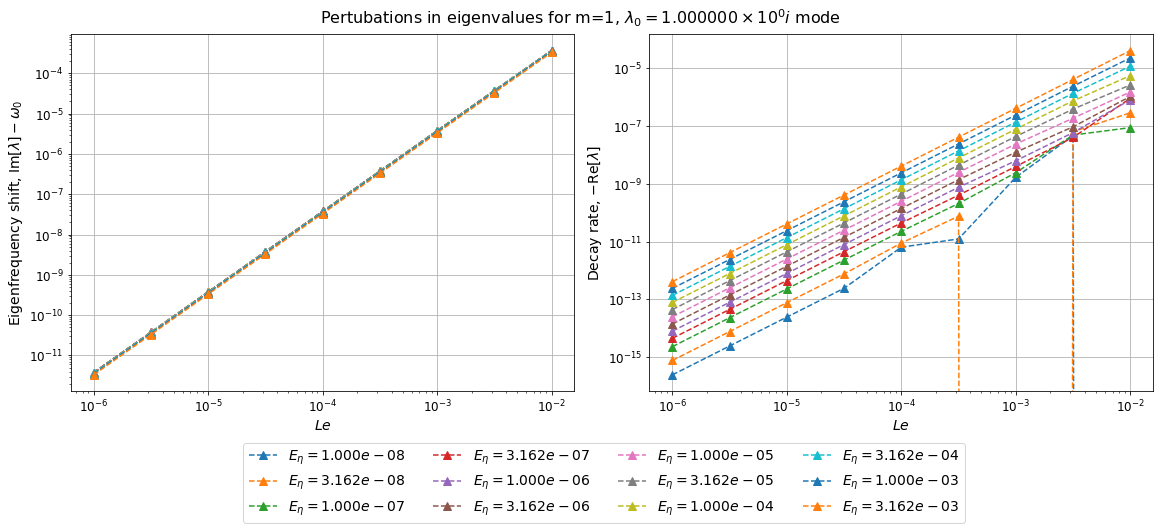

In [ ]:
save_name = './runs/Axial_Le_Eeta_mesh/eigvals_spinover_fixedEm_all'
save_name = None
overwrite = False

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), layout='constrained')

plot_idx = np.arange(Em_list.size-1)

ax = axes[0]
for i_Em, Em in enumerate(Em_list[plot_idx]):
    ax.loglog(Le_list, np.sign(np.imag(eigendiff[0, 0]))*np.imag(eigendiff[:, i_Em]), '^--', 
        markersize=8, 
        label=r'$E_\eta=%.3e$' % (Em,))
ax.grid(which='major')
ax.tick_params(which='major', labelsize=12)
ax.set_xlabel('$Le$', fontsize=14)
ax.set_ylabel('Eigenfrequency shift, $\mathrm{Im}[\lambda] - \omega_0$', fontsize=14)
# ax.legend(fontsize=12)

ax = axes[1]
line_handles = list()
for i_Em, Em in enumerate(Em_list[plot_idx]):
    line = ax.loglog(Le_list, - np.real(eigendiff[:, i_Em]), '^--', markersize=8, label=r'$E_\eta=%.3e$' % (Em,))
    line_handles.append(*line)
ax.grid(which='major')
ax.tick_params(which='major', labelsize=12)
ax.set_xlabel('$Le$', fontsize=14)
ax.set_ylabel('Decay rate, $-\mathrm{Re}[\lambda]$', fontsize=14)
# ax.legend(fontsize=12)

real_dec = pgpy_utils.decimal_decomp(eig_0.real)
imag_dec = pgpy_utils.decimal_decomp(eig_0.imag)
# fig.suptitle(r'Meridional slice, $\lambda=%+.6f\times10^{%d}i$' % \
#     imag_dec, fontsize=16)
fig.suptitle(r'Pertubations in eigenvalues for m=%d, $\lambda_0=%.6f\times10^{%d}i$ mode' % (m_val, *imag_dec,), fontsize=16)
fig.legend(handles=line_handles, ncol=4, bbox_to_anchor=(0.84, 0.0), fontsize=14)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not overwrite:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

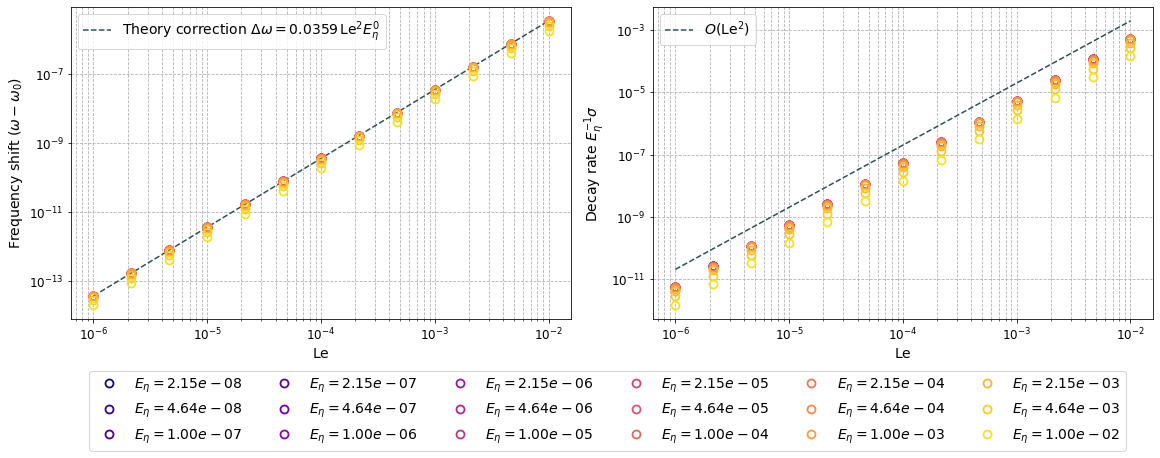

In [66]:
save_name = f'./runs/T1_Le_Eeta_mesh_m1/evals-Le_{mode_code}-{B0_code}'
# save_name = None
overwrite = False

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5), layout='constrained')

plot_Le_range = [1e-7, 1e-2]
plot_Em_range = [2e-8, 1e-2]
plot_Le_idx = (Le_list >= plot_Le_range[0]) & (Le_list <= plot_Le_range[-1])
plot_Em_idx = (Em_list >= plot_Em_range[0]) & (Em_list <= plot_Em_range[-1])
clist = plt.cm.plasma(np.linspace(0, 1, num=np.sum(plot_Em_idx)+1)[:-1])
# clist = plt.cm.turbo(np.linspace(0, 1, num=np.sum(plot_Em_idx)+2)[1:-1])
# clist = plt.cm.tab20((np.arange(np.sum(plot_Em_idx) + 0.5))/20)
# clist = plt.cm.turbo(np.linspace(0, 1, num=plot_idx.size+2)[1:-1])
# clist = plt.cm.tab20((np.arange(plot_idx.size + 0.5))/20)

ax = axes[0]
sgn_omega = np.sign(np.imag(eigendiff[4, 2]))
n_line = 0
for i_Em, Em in enumerate(Em_list):
    if not plot_Em_idx[i_Em]:
        continue
    ax.loglog(Le_list[plot_Le_idx], sgn_omega*np.imag(eigendiff[plot_Le_idx, i_Em]), 'o', markersize=8, 
        color=clist[n_line], markerfacecolor='none', markeredgewidth=1.8,
        label=r'$E_\eta=%.3e$' % (Em,), zorder=5)
    n_line += 1
line_theory = ax.loglog(
    Le_pred, sgn_omega*(np.imag(lambda_2_0)*Le_pred**2), 
    '--', color='darkslategray', zorder=4,
    label='Theory correction $\\Delta \\omega=%.4f \, \mathrm{Le}^{2} E_\eta^0$' % (np.imag(lambda_2_0)),
)
ax.grid(which='both', linestyle='--')
ax.tick_params(which='major', labelsize=12)
ax.set_xlabel('$\mathrm{Le}$', fontsize=14)
if sgn_omega >= 0:
    ax.set_ylabel(r'Frequency shift $(\omega - \omega_0)$', fontsize=14)
else:
    ax.set_ylabel(r'Frequency shift $(\omega_0 - \omega)$', fontsize=14)
ax.legend(handles=line_theory, fontsize=14)

ax = axes[1]
line_handles = list()
n_line = 0
for i_Em, Em in enumerate(Em_list):
    if not plot_Em_idx[i_Em]:
        continue
    line = ax.plot(Le_list[plot_Le_idx], - np.real(eigendiff[plot_Le_idx, i_Em])/np.sqrt(Em)**2, 'o', markersize=8, 
        color=clist[n_line], markerfacecolor='none', markeredgewidth=1.8,
        label=r'$E_\eta=%.2e$' % Em, zorder=5)
    line_handles.append(*line)
    n_line += 1
# line_theory = ax.plot(
#     Le_pred, -np.real(lambda_2_1)*Le_pred**2, '--', color='darkslategray', 
#     label='Theory correction $E_\eta^{-1/2} \\Delta \\sigma=%+.2f \mathrm{Le}^2$' % (np.real(lambda_2_1)), zorder=4
# )
line_theory = ax.plot(
    Le_pred, 20*Le_pred**2, '--', color='darkslategray', 
    label=r'$O(\mathrm{Le}^2)$', zorder=4
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(which='both', linestyle='--')
ax.tick_params(which='major', labelsize=12)
ax.set_xlabel('$\mathrm{Le}$', fontsize=14)
# ax.set_ylabel('Decay rate $E_\eta^{-1/2}\sigma$', fontsize=14)
ax.set_ylabel('Decay rate $E_\eta^{-1}\sigma$', fontsize=14)
ax.legend(handles=line_theory, fontsize=14)

real_dec = pgpy_utils.decimal_decomp(eig_0.real)
imag_dec = pgpy_utils.decimal_decomp(eig_0.imag)
# fig.suptitle(r'Perturbations in eigenvalues for m=%d, $\lambda_0=%.6f\times10^{%d}i$ mode' % (m_val, *imag_dec,), fontsize=16)
fig.legend(handles=line_handles, ncol=6, bbox_to_anchor=(0.98, 0.0), fontsize=14)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not overwrite:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

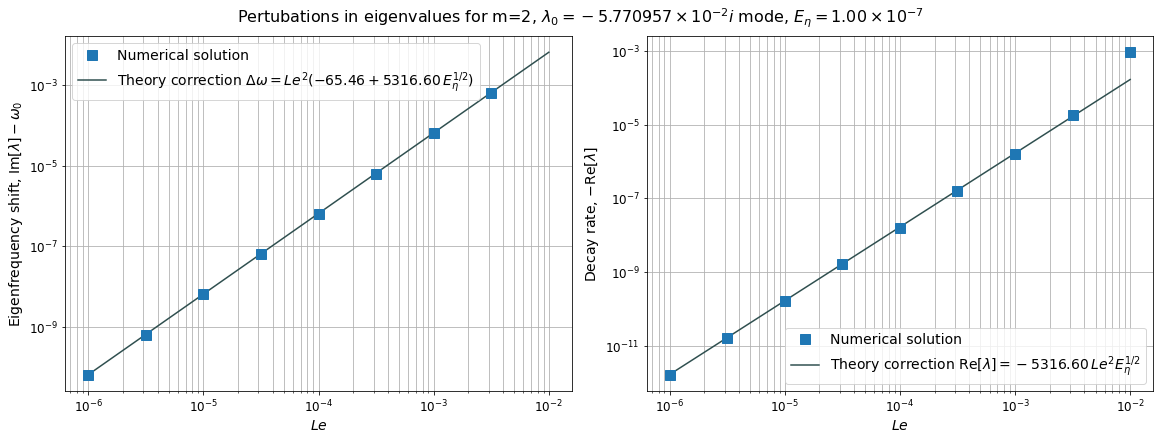

In [191]:
i_par_plot = 2
Em_val = Em_list[i_par_plot]
save_name = './runs/Axial_Le_Eeta_mesh/eigvals_spinover_fixedEm_{:.1e}_bl2'.format(Em_val)
save_name = None
overwrite = True

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), layout='constrained')

ax = axes[0]
sign = np.sign(np.imag(eigendiff[0, 0]))
ax.loglog(Le_list, sign*np.imag(eigendiff[:, i_par_plot]), 's', markersize=10, label='Numerical solution', zorder=5)
# ax.loglog(Le_list, Le_list**2*sign*np.imag(lambda_2_0), 
#     '-', color='darkslategray', label='Theory correction $\\Delta\\omega=%.2f \, Le^2 E_\eta^0$' % (np.imag(lambda_2_0),))
ax.loglog(
    Le_pred, Le_pred**2*sign*(np.imag(lambda_2_0)), 
    '-', color='darkslategray', 
    label='Theory correction $\\Delta\\omega=Le^2 (%.2f %+.2f \, E_\eta^{1/2})$' % (
        np.imag(lambda_2_0), np.imag(lambda_2_1)
    )
)
ax.grid(which='both')
ax.tick_params(which='both', labelsize=12)
ax.set_xlabel('$Le$', fontsize=14)
ax.set_ylabel('Eigenfrequency shift, $\mathrm{Im}[\lambda] - \omega_0$', fontsize=14)
ax.legend(fontsize=14, loc=2)

ax = axes[1]
line_handles = list()
ax.loglog(Le_list, - np.real(eigendiff[:, i_par_plot]), 's', markersize=10, label='Numerical solution', zorder=5)
# ax.loglog(Le_list, 0.8*(-np.real(eigendiff[2, i_par_plot])/Le_list[2]**2)*Le_list**2, '-', 
#     color='darkslategray', label=r'Scaling $Le^2$')
ax.loglog(
    Le_pred, -np.real(lambda_2_1)*Le_pred**2*np.sqrt(Em_val), '-', 
    color='darkslategray', 
    label='Theory correction $\\mathrm{Re}[\\lambda]=%+.2f \, Le^2 E_\eta^{1/2}$' % (
        np.real(lambda_2_1)
    )
)
ax.grid(which='both')
ax.tick_params(which='both', labelsize=12)
ax.set_xlabel('$Le$', fontsize=14)
ax.set_ylabel('Decay rate, $-\mathrm{Re}[\lambda]$', fontsize=14)
ax.legend(fontsize=14, loc=4)

real_dec = pgpy_utils.decimal_decomp(eig_0.real)
imag_dec = pgpy_utils.decimal_decomp(eig_0.imag)
Em_dec = pgpy_utils.decimal_decomp(Em_val)
# fig.suptitle(r'Meridional slice, $\lambda=%+.6f\times10^{%d}i$' % \
#     imag_dec, fontsize=16)
fig.suptitle(r'Pertubations in eigenvalues for m=%d, $\lambda_0=%.6f\times10^{%d}i$ mode, $E_\eta = %.2f\times10^{%d}$' % 
    (m_val, *imag_dec, *Em_dec), fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not overwrite:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

#### Deviation from theory

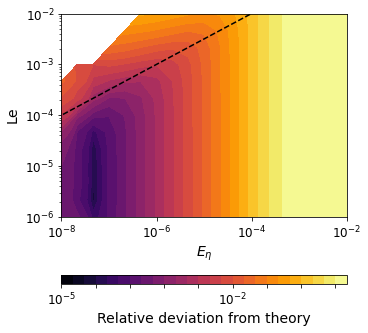

In [43]:
import matplotlib as mpl

fname = f'./runs/S1_Le_Eeta_mesh_m2/dev-Le-Eeta_{mode_code}-{B0_code}'
fname = None

eigendiff_theory = np.outer(Le_list**2, (lambda_2_0 + lambda_2_1*np.sqrt(Em_list)))
deviation_view = np.abs(eigendiff - eigendiff_theory)/np.abs(eigendiff_theory)
# deviation_view = deviation_view/np.nanmin(deviation_view, axis=-1, keepdims=True)
# deviation_view = np.log10(deviation_view)

fig, ax = plt.subplots(figsize=(5, 4.5), layout='constrained')
# im = ax.imshow(deviation_view)
# im = ax.pcolormesh(Em_mesh, Le_mesh, deviation_view, cmap='inferno', shading='nearest', norm=mpl.colors.LogNorm())
# im = ax.pcolormesh(Le_mesh.T, Em_mesh.T, deviation_view.T, cmap='inferno', shading='nearest', norm=mpl.colors.LogNorm())
im = ax.contourf(Em_mesh, Le_mesh, deviation_view, np.logspace(-5, 0, num=26), cmap='inferno', norm=mpl.colors.LogNorm())
ax.set_xscale('log')
ax.set_yscale('log')
ax.autoscale(True)
ax.get_xlim()
# ax.set_ylim(-1, 10)
ax.autoscale(enable=False, axis='both')
ax.plot(np.r_[1e-9, Em_pred], np.sqrt(np.r_[1e-9, Em_pred]), '--', color='k')
# ax.plot(np.r_[1e-9, Em_pred], 3*np.sqrt(np.r_[1e-9, Em_pred]), '--', color='k')
# ax.plot(np.r_[1e-9, Em_pred], .3*np.sqrt(np.r_[1e-9, Em_pred]), '--', color='k')
ax.tick_params(which='both', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
ax.set_ylabel('$\mathrm{Le}$', fontsize=14)
cbar = plt.colorbar(im, ax=ax, location='bottom', aspect=30)
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel('Relative deviation from theory', fontsize=14)

if fname is not None:
    plt.savefig(fname + '.png', dpi=150, bbox_inches='tight')
plt.show()

#### Overall visualisation

In [27]:
nr, maxnl, m_val = 120, 100, 1
Nr = 201
Nt = 201

rg = specfun.roots_chebyt(Nr*2 - (Nr % 2))[0][-Nr:]
tg = np.linspace(0, np.pi, Nt)
rr, tt = np.meshgrid(rg, tg)
X1, X2 = rr*np.sin(tt), rr*np.cos(tt)

worland_transform = WorlandTransform(nr, maxnl, m_val, r_grid=rg)
plm_transform = AssociatedLegendreTransformSingleM(maxnl, m_val, tg)

c:\Users\gentle\Documents\Projects\Modes_3D\MCmodes\operators\associated_legendre_transform.py:25: RuntimeWarning: divide by zero encountered in true_divide
  self._operators['dtheta2plm'] = (self.m**2*self._operators['plmdivsin'] - c_t*self._operators['dthetaplm'])/s_t \


In [54]:
i_Le = 6
i_Em = 3

Ndim = eigenvecs.shape[-1]
usp = VectorFieldSingleM(nr, maxnl, m_val, eigenvecs[i_Le, i_Em, :Ndim//2])
bsp = VectorFieldSingleM(nr, maxnl, m_val, eigenvecs[i_Le, i_Em, Ndim//2:])
u_sph = usp.physical_field(worland_transform, plm_transform).data
b_sph = bsp.physical_field(worland_transform, plm_transform).data

max_id = np.unravel_index(np.argmax(np.abs(u_sph['phi'])), u_sph['phi'].shape)
max_phi_val = np.max(np.abs(u_sph['phi']))
arg_0 = -np.angle(u_sph['phi'][max_id])
for comp in u_sph:
    u_sph[comp] *= np.exp(1j*arg_0)/max_phi_val
    b_sph[comp] *= np.exp(1j*arg_0)/max_phi_val

u0_sph_val = [
    np.ones_like(rr)*sym.lambdify([m_inert.r, m_inert.theta], u_comp.subs(parsub), modules=['numpy', 'scipy'])(rr, tt) 
    for u_comp in u0_sph
]
b1_in_sph_val = [
    Le_list[i_Le]*np.ones_like(rr)*sym.lambdify([m_inert.r, m_inert.theta], b_comp.subs(parsub).expand(), modules=['numpy', 'scipy'])(rr, tt) 
    for b_comp in b1_in_sph
]
max_int_id = np.argmax(np.abs(u0_sph_val[2]).flatten())
max_int_val = u0_sph_val[2].flatten()[max_int_id]
for comp in range(len(u0_sph_val)):
    u0_sph_val[comp] /= max_int_val
    b1_in_sph_val[comp] /= max_int_val
    
fields = {
    'v0_r': u0_sph_val[0], 
    'v0_t': u0_sph_val[1],
    'v0_p': u0_sph_val[2], 
    'v0_s': (u0_sph_val[0]*np.sin(tt) + u0_sph_val[1]*np.cos(tt)), 
    'v0_z': (u0_sph_val[0]*np.cos(tt) - u0_sph_val[1]*np.sin(tt)),
    'v_r': u_sph['r'], 
    'v_t': u_sph['theta'],
    'v_p': u_sph['phi'], 
    'v_s': (u_sph['r']*np.sin(tt) + u_sph['theta']*np.cos(tt)), 
    'v_z': (u_sph['r']*np.cos(tt) - u_sph['theta']*np.sin(tt)),
    'b_r': b_sph['r'], 
    'b_t': b_sph['theta'],
    'b_p': b_sph['phi'], 
    'b_s': (b_sph['r']*np.sin(tt) + b_sph['theta']*np.cos(tt)), 
    'b_z': (b_sph['r']*np.cos(tt) - b_sph['theta']*np.sin(tt)),
    'b1_in_r': b1_in_sph_val[0], 
    'b1_in_t': b1_in_sph_val[1],
    'b1_in_p': b1_in_sph_val[2], 
    'b1_in_s': (b1_in_sph_val[0]*np.sin(tt) + b1_in_sph_val[1]*np.cos(tt)), 
    'b1_in_z': (b1_in_sph_val[0]*np.cos(tt) - b1_in_sph_val[1]*np.sin(tt)),
}
print(Le_list[i_Le], Em_list[i_Em])

0.0001 1e-07


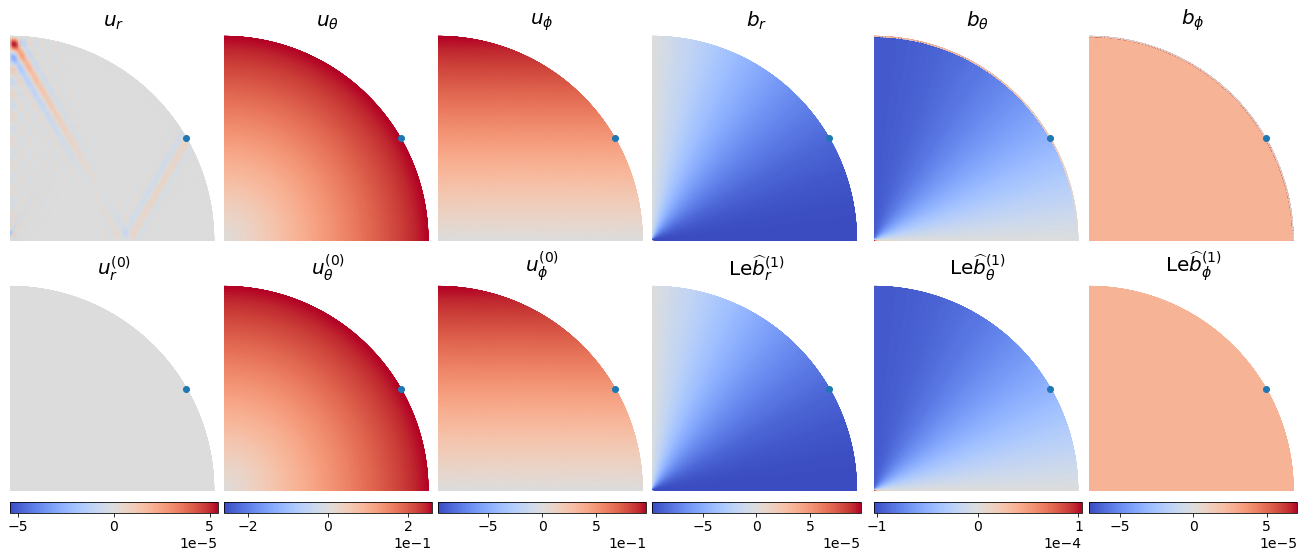

In [55]:
lon_view = 15
# save_name = "./runs/Axial_Le_Eeta_mesh/v_md_ie01_u_compare_v2"
save_name = f"./runs/Axial_Le_Eeta_mesh_m1/v_md_{mode_code}-{B0_code}_Le1e-4_Em1e-7_ub"
# save_name = None
override = True

plot_fields = [
    # ['v_s', 'v_z', 'v_p'],
    # ['v0_s', 'v0_z', 'v0_p'],
    # ['v_r', 'v_t', 'v_p'],
    # ["b_r", "b_t", "b_p"],
    # ["b1_in_r", "b1_in_t", "b1_in_p"],
    ['v_r', 'v_t', 'v_p', 'b_r', 'b_t', 'b_p'],
    ['v0_r', 'v0_t', 'v0_p', "b1_in_r", "b1_in_t", "b1_in_p"]
]
plot_fnames = [
    # [r"$v_s$", r"$v_z$", r"$v_\phi$"],
    # [r"$v_{0s}$", r"$v_{0z}$", r"$v_{0\phi}$"],
    # [r"$v_r$", r"$v_\theta$", r"$v_\phi$"],
    # [r"$b_r$", r"$b_\theta$", r"$b_\phi$"],
    # [r"$\widehat{b}_r^{(1)}$", r"$\widehat{b}_\theta^{(1)}$", r"$\widehat{b}_\phi^{(1)}$"],
    [r"$u_r$", r"$u_\theta$", r"$u_\phi$", r"$b_r$", r"$b_\theta$", r"$b_\phi$"],
    [r"${u}_r^{(0)}$", r"${u}_\theta^{(0)}$", r"${u}_\phi^{(0)}$", r"$\mathrm{Le}\widehat{b}_r^{(1)}$", r"$\mathrm{Le}\widehat{b}_\theta^{(1)}$", r"$\mathrm{Le}\widehat{b}_\phi^{(1)}$"],
]

force_symmetric_cmap = True
phase = np.exp(1j*m_val*np.radians(lon_view))
norm = np.max(np.abs(fields['v_p']))
nrows, ncols = len(plot_fields), len(plot_fields[0])
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3.8), layout='constrained')
# fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2.4, nrows*2.1), layout='constrained')
axes = np.atleast_2d(axes)

maxvals = np.zeros(np.asarray(plot_fields).shape)
minvals = np.zeros(np.asarray(plot_fields).shape)
for i_r in range(nrows):
    for i_c in range(ncols):
        fname = plot_fields[i_r][i_c]
        if fname is None:
            maxvals[i_r, i_c] = np.nan
            minvals[i_r, i_c] = np.nan
            continue
        field_plot = np.real(fields[fname]*phase)/norm
        maxvals[i_r, i_c] = np.max(field_plot)
        minvals[i_r, i_c] = np.min(field_plot)
t_crit = np.arccos(0.5)

for i_r in range(nrows):
    for i_c in range(ncols):
        fname = plot_fields[i_r][i_c]
        ax = axes[i_r][i_c]
        if fname is None:
            ax.remove()
            continue
        field_plot = np.real(fields[fname]*phase)/norm
        # if np.abs(field_plot).max() > 1e-7:
        if np.nanmax(np.abs([maxvals[0, i_c], maxvals[1, i_c], minvals[0, i_c], minvals[1, i_c]])) > 1e-7:
            if force_symmetric_cmap:
                # climit = np.max(np.abs(field_plot))
                # climit = 0.7
                climit = np.nanmax(np.abs([maxvals[0, i_c], maxvals[1, i_c], minvals[0, i_c], minvals[1, i_c]]))
                vmin, vmax = -climit, +climit
                cm = ax.pcolormesh(X1, X2, field_plot, shading="gouraud", cmap="coolwarm", vmin=vmin, vmax=vmax)
                ax.scatter([np.sin(t_crit), np.sin(t_crit)], [np.cos(t_crit), -np.cos(t_crit)])
                # plt.colorbar(cm, ax=ax)
            else:
                vmin, vmax = np.nanmin(minvals[:, i_c]), np.nanmax(maxvals[:, i_c])
                cm = ax.pcolormesh(X1, X2, field_plot, shading="gouraud", cmap="coolwarm", vmin=vmin, vmax=vmax)
                # plt.colorbar(cm, ax=ax)
        else:
            cm = ax.pcolormesh(X1, X2, field_plot, shading="gouraud", cmap="coolwarm", vmin=-1e-7, vmax=+1e-7)
            # plt.colorbar(cm, ax=ax)
        
        if i_r == nrows - 1:
            cbar = plt.colorbar(cm, ax=ax, orientation='horizontal')
            cbar.formatter.set_powerlimits((0,0))
            cbar.ax.tick_params(labelsize=14)
            cbar.ax.xaxis.get_offset_text().set_fontsize(14)
        
        ax.set_title(plot_fnames[i_r][i_c], fontsize=20)
        ax.set_aspect('equal', 'box')
        # ax.grid()
        ax.set_xlim([0, 1.02])
        ax.set_ylim([0, 1.02])
        ax.axis("off")

real_dec = pgpy_utils.decimal_decomp(eigenvals[i_Le, i_Em].real)
imag_dec = pgpy_utils.decimal_decomp(eigenvals[i_Le, i_Em].imag)
Le_dec = pgpy_utils.decimal_decomp(Le_list[i_Le])
Em_dec = pgpy_utils.decimal_decomp(Em_list[i_Em])
# fig.suptitle(
#     r'Mode at $Le=%.1f\times10^{%d}$, $E_\eta=%.1f\times10^{%d}$, slice at $\phi=%.0f^\circ$ [$\lambda=%+.2f\times10^{%d}%+.6f\times10^{%d}i$]' % \
#     (*Le_dec, *Em_dec, lon_view, *real_dec, *imag_dec), fontsize=16)
# fig.suptitle(
#     r'Mode %s under %s at $\mathrm{Le}=%.1f\times10^{%d}$, $E_\eta=%.1f\times10^{%d}$, slice at $\phi=%.0f^\circ$' % \
#     (mode_name, B0_name, *Le_dec, *Em_dec, lon_view), fontsize=20)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not override:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")
        # plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")

plt.show()

#### Radial profile at a latitude

In [204]:
Nr = 201
cla = np.radians(75)

# rg = specfun.roots_chebyt(Nr*2 - (Nr % 2))[0][-Nr:]
rg = np.sqrt((1 + specfun.roots_jacobi(nr, -.5, maxnl - 0.5)[0])/2)
tpt = np.array([cla])

worland_transform = WorlandTransform(nr, maxnl, m_val, r_grid=rg)
plm_transform = AssociatedLegendreTransformSingleM(maxnl, m_val, tpt)

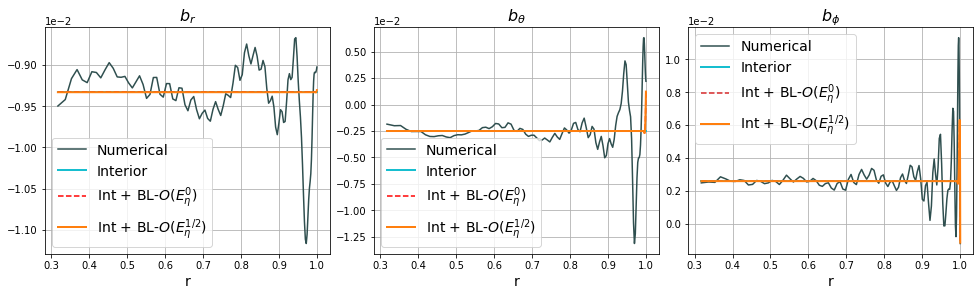

In [207]:
i_Le, i_Em = 12, 6
Le_val, Em_val = Le_list[i_Le], Em_list[i_Em]
r_min = 0.0
lon_view = 15
plot_BL = True

save_name = f"./runs/Axial_Le_Eeta_mesh/profile_b_{mode_code}-{B0_code}_Le1e-4_Em1e-6_lat15_part_BL2"
save_name = None
override = False

i_rg = rg > r_min
num_marker = '.-' if r_min >= 0.8 else '-'

phase = np.exp(1j*m_val*np.radians(lon_view))

Ndim = eigenvecs.shape[-1]
u_prof = VectorFieldSingleM(nr, maxnl, m_val, eigenvecs[i_Le, i_Em, :Ndim//2]).physical_field(worland_transform, plm_transform).data
b_prof = VectorFieldSingleM(nr, maxnl, m_val, eigenvecs[i_Le, i_Em, Ndim//2:]).physical_field(worland_transform, plm_transform).data
for comp in u_prof:
    u_prof[comp] = np.squeeze(u_prof[comp])*np.exp(1j*arg_0)*phase/max_phi_val
    b_prof[comp] = np.squeeze(b_prof[comp])*np.exp(1j*arg_0)*phase/max_phi_val

u0_prof = [
    np.ones_like(rg)*sym.lambdify([m_inert.r, m_inert.theta], u_comp.subs(parsub), modules=['numpy', 'scipy'])(rg, tpt[0]) for u_comp in u0_sph
]
b1_in_prof = [
    Le_val*np.ones_like(rg)*sym.lambdify([m_inert.r, m_inert.theta], b_comp.subs(parsub), modules=['numpy', 'scipy'])(rg, tpt[0]) for b_comp in b1_in_sph
]
t_bl = np.sqrt(2*Em_list[i_Em]/np.abs(float(sym.im(lambda_0))))
b1_bl_prof = [
    np.zeros_like(rg),
    Le_val*np.squeeze(f_b1t_bl(tpt))*np.exp(-(1 + np.sign(np.imag(complex(lambda_0)))*1j)*(1 - rg)/t_bl),
    Le_val*np.squeeze(f_b1p_bl(tpt))*np.exp(-(1 + np.sign(np.imag(complex(lambda_0)))*1j)*(1 - rg)/t_bl)
]
b1_blh_prof = [
    Le_val*np.sqrt(Em_val)*np.squeeze(f_b1hr_bl0(tpt))*np.exp(-(1 + np.sign(np.imag(complex(lambda_0)))*1j)*(1 - rg)/t_bl),
    Le_val*np.sqrt(Em_val)*np.squeeze(f_b1ht_bl1(tpt)*(1 - rg)/np.sqrt(Em_val) + f_b1ht_bl0(tpt))*np.exp(-(1 + np.sign(np.imag(complex(lambda_0)))*1j)*(1 - rg)/t_bl),
    Le_val*np.sqrt(Em_val)*np.squeeze(f_b1hp_bl1(tpt)*(1 - rg)/np.sqrt(Em_val) + f_b1hp_bl0(tpt))*np.exp(-(1 + np.sign(np.imag(complex(lambda_0)))*1j)*(1 - rg)/t_bl)
]
for comp in range(len(u0_prof)):
    u0_prof[comp] = u0_prof[comp]*(phase/max_int_val)
    b1_in_prof[comp] = b1_in_prof[comp]*(phase/max_int_val)
    b1_bl_prof[comp] = b1_bl_prof[comp]*(phase/max_int_val)
    b1_blh_prof[comp] = b1_blh_prof[comp]*(phase/max_int_val)

profiles = {
    'v_r': u_prof['r'], 'v_t': u_prof['theta'], 'v_p': u_prof['phi'],
    'b_r': b_prof['r'], 'b_t': b_prof['theta'], 'b_p': b_prof['phi'],
    'v0_r': u0_prof[0], 'v0_t': u0_prof[1], 'v0_p': u0_prof[2],
    'b1_in_r': b1_in_prof[0], 'b1_in_t': b1_in_prof[1], 'b1_in_p': b1_in_prof[2],
    'b1_bl_r': b1_bl_prof[0], 'b1_bl_t': b1_bl_prof[1], 'b1_bl_p': b1_bl_prof[2],
    'b1_blh_r': b1_blh_prof[0], 'b1_blh_t': b1_blh_prof[1], 'b1_blh_p': b1_blh_prof[2],
}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(3*4.5, 4), layout='constrained')
label_int = r'Interior'
label_BL1 = r'Int + BL-$O(E_\eta^0)$'
label_BL2 = r'Int + BL-$O(E_\eta^{1/2})$'

ax = axes[0]
ax.plot(rg[i_rg], np.real(profiles['b_r'][i_rg]), num_marker, color='darkslategray', label='Numerical')
ax.plot(rg[i_rg], np.real(profiles['b1_in_r'][i_rg]), '-', color='tab:cyan', linewidth=2, label=label_int)
        # label=r'$\widehat{b}_r^{(1)}$')
if plot_BL:
    ax.plot(rg[i_rg], np.real(profiles['b1_in_r'][i_rg]), '--', color='red', label=label_BL1)
            # label=r'$\widehat{b}_r^{(1)} + \widetilde{b}_r^{(1,0)}$')
    ax.plot(rg[i_rg], np.real(profiles['b1_in_r'][i_rg] + profiles['b1_blh_r'][i_rg]), 
        '-', color='tab:orange', linewidth=2, label=label_BL2)
        # label=r'$\widehat{b}_r^{(1)} + \widetilde{b}_r^{(1,0)} + \widetilde{b}_r^{(1,\frac{1}{2})}$')
# ax.yaxis.formatter.set_powerlimits((0,0))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title('$b_r$', fontsize=16)

ax = axes[1]
ax.plot(rg[i_rg], np.real(profiles['b_t'][i_rg]), num_marker, color='darkslategray', label='Numerical')
ax.plot(rg[i_rg], np.real(profiles['b1_in_t'][i_rg]), '-', color='tab:cyan', linewidth=2, label=label_int)
    # label=r'$\widehat{b}_\theta^{(1)}$')
if plot_BL:
    ax.plot(rg[i_rg], np.real(profiles['b1_in_t'][i_rg] + profiles['b1_bl_t'][i_rg]), '--', color='red', label=label_BL1)
        # label=r'$\widehat{b}_\theta^{(1)} + \widetilde{b}_\theta^{(1,0)}$')
    ax.plot(rg[i_rg], np.real(profiles['b1_in_t'][i_rg] + profiles['b1_bl_t'][i_rg] + profiles['b1_blh_t'][i_rg]), 
        '-', color='tab:orange', linewidth=2, label=label_BL2)
        # label=r'$\widehat{b}_\theta^{(1)} + \widetilde{b}_\theta^{(1,0)} + \widetilde{b}_\theta^{(1,\frac{1}{2})}$')
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title(r'$b_\theta$', fontsize=16)

ax = axes[2]
ax.plot(rg[i_rg], np.real(profiles['b_p'][i_rg]), num_marker, color='darkslategray', label='Numerical')
ax.plot(rg[i_rg], np.real(profiles['b1_in_p'][i_rg]), '-', color='tab:cyan', linewidth=2, label=label_int)
    # label=r'$\widehat{b}_\phi^{(1)}$')
if plot_BL:
    ax.plot(rg[i_rg], np.real(profiles['b1_in_p'][i_rg] + profiles['b1_bl_p'][i_rg]), '--', color='tab:red', label=label_BL1)
        # label=r'$\widehat{b}_\phi^{(1)} + \widetilde{b}_\phi^{(1,0)}$')
    ax.plot(rg[i_rg], np.real(profiles['b1_in_p'][i_rg] + profiles['b1_bl_p'][i_rg] + profiles['b1_blh_p'][i_rg]), 
        '-', color='tab:orange', linewidth=2, label=label_BL2)
        # label=r'$\widehat{b}_\phi^{(1)} + \widetilde{b}_\phi^{(1,0)} + \widetilde{b}_\phi^{(1,\frac{1}{2})}$')
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title(r'$b_\phi$', fontsize=16)

real_dec = pgpy_utils.decimal_decomp(float(sym.re(lambda_0)))
imag_dec = pgpy_utils.decimal_decomp(float(sym.im(lambda_0)))
Le_dec = pgpy_utils.decimal_decomp(Le_val)
Em_dec = pgpy_utils.decimal_decomp(Em_val)
# fig.suptitle(r'Mode %s under %s at $Le=%.1f\times10^{%d}, E_\eta=%.1f\times10^{%d}$, r-profile at $\phi=%.0f^\circ$, $\theta=%.0f^\circ$' 
#     % (mode_name, B0_name, *Le_dec, *Em_dec, lon_view, np.degrees(cla)), fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not override:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")

plt.show()

In [113]:
Le_val, Em_val

(0.001, 1e-05)

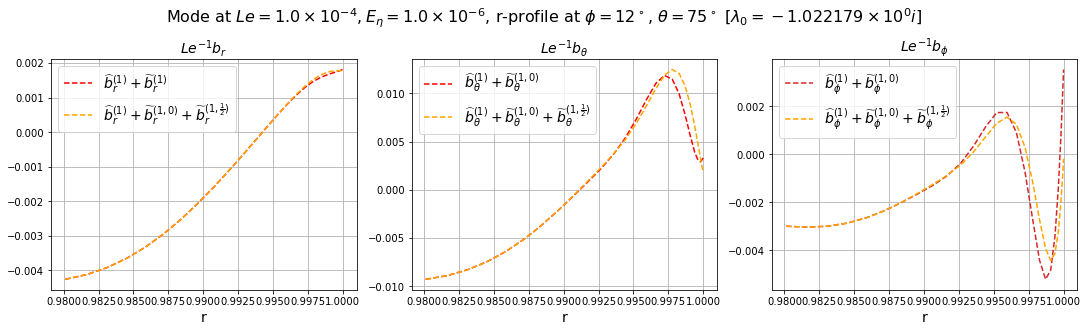

In [143]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(3*5, 4.5), layout='constrained')

ax = axes[0]
# ax.plot(rg[i_rg], np.real(profiles['b1_in_r'][i_rg] - profiles['b_r'][i_rg]), '-', color='tab:cyan', linewidth=2, label=r'$\widehat{b}_r^{(1)}$')
if plot_BL:
    ax.plot(rg[i_rg], np.real(profiles['b1_in_r'][i_rg] - profiles['b_r'][i_rg]), '--', color='red', label=r'$\widehat{b}_r^{(1)} + \widetilde{b}_r^{(1)}$')
    ax.plot(rg[i_rg], np.real(profiles['b1_in_r'][i_rg] + profiles['b1_blh_r'][i_rg] - profiles['b_r'][i_rg]), 
        '--', color='orange',
        label=r'$\widehat{b}_r^{(1)} + \widetilde{b}_r^{(1,0)} + \widetilde{b}_r^{(1,\frac{1}{2})}$')
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title('$Le^{-1}b_r$', fontsize=14)

ax = axes[1]
# ax.plot(rg[i_rg], np.real(profiles['b1_in_t'][i_rg] - profiles['b_t'][i_rg]), '-', color='tab:cyan', linewidth=2,
#     label=r'$\widehat{b}_\theta^{(1)}$')
if plot_BL:
    ax.plot(rg[i_rg], np.real(profiles['b1_in_t'][i_rg] + profiles['b1_bl_t'][i_rg] - profiles['b_t'][i_rg]), '--', color='red',
        label=r'$\widehat{b}_\theta^{(1)} + \widetilde{b}_\theta^{(1,0)}$')
    ax.plot(rg[i_rg], np.real(profiles['b1_in_t'][i_rg] + profiles['b1_bl_t'][i_rg] + profiles['b1_blh_t'][i_rg] - profiles['b_t'][i_rg]), 
        '--', color='orange',
        label=r'$\widehat{b}_\theta^{(1)} + \widetilde{b}_\theta^{(1,0)} + \widetilde{b}_\theta^{(1,\frac{1}{2})}$')
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title(r'$Le^{-1}b_\theta$', fontsize=14)

ax = axes[2]
# ax.plot(rg[i_rg], np.real(profiles['b1_in_p'][i_rg] - profiles['b_p'][i_rg]), '-', color='tab:cyan', linewidth=2,
#     label=r'$\widehat{b}_\phi^{(1)}$')
if plot_BL:
    ax.plot(rg[i_rg], np.real(profiles['b1_in_p'][i_rg] + profiles['b1_bl_p'][i_rg] - profiles['b_p'][i_rg]), '--', color='tab:red', 
        label=r'$\widehat{b}_\phi^{(1)} + \widetilde{b}_\phi^{(1,0)}$')
    ax.plot(rg[i_rg], np.real(profiles['b1_in_p'][i_rg] + profiles['b1_bl_p'][i_rg] + profiles['b1_blh_p'][i_rg] - profiles['b_p'][i_rg]), 
        '--', color='orange',
        label=r'$\widehat{b}_\phi^{(1)} + \widetilde{b}_\phi^{(1,0)} + \widetilde{b}_\phi^{(1,\frac{1}{2})}$')
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title(r'$Le^{-1}b_\phi$', fontsize=14)

real_dec = pgpy_utils.decimal_decomp(float(sym.re(lambda_0)))
imag_dec = pgpy_utils.decimal_decomp(float(sym.im(lambda_0)))
Le_dec = pgpy_utils.decimal_decomp(Le_val)
Em_dec = pgpy_utils.decimal_decomp(Em_val)
fig.suptitle(r'Mode at $Le=%.1f\times10^{%d}, E_\eta=%.1f\times10^{%d}$, r-profile at $\phi=%.0f^\circ$, $\theta=%.0f^\circ$ [$\lambda_0=%+.6f\times10^{%d}i$]' 
    % (*Le_dec, *Em_dec, lon_view, np.degrees(cla), *imag_dec), fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not override:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")

plt.show()

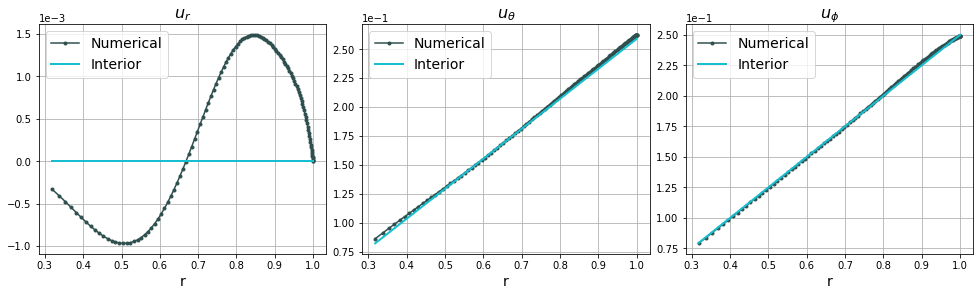

In [206]:
i_Le, i_Em = 12, 15
Le_val, Em_val = Le_list[i_Le], Em_list[i_Em]
r_min = 0.0
lon_view = 15

save_name = f"./runs/Axial_Le_Eeta_mesh/profile_v_{mode_code}-{B0_code}_Le1e-4_Em1e-6_lat15_part_BL2"
save_name = None
override = False

i_rg = rg > r_min
# num_marker = '.-' if r_min >= 0.8 else '-'
num_marker = '.-'

phase = np.exp(1j*m_val*np.radians(lon_view))

Ndim = eigenvecs.shape[-1]
u_prof = VectorFieldSingleM(nr, maxnl, m_val, eigenvecs[i_Le, i_Em, :Ndim//2]).physical_field(worland_transform, plm_transform).data
b_prof = VectorFieldSingleM(nr, maxnl, m_val, eigenvecs[i_Le, i_Em, Ndim//2:]).physical_field(worland_transform, plm_transform).data
for comp in u_prof:
    u_prof[comp] = np.squeeze(u_prof[comp])*np.exp(1j*arg_0)*phase/max_phi_val
    b_prof[comp] = np.squeeze(b_prof[comp])*np.exp(1j*arg_0)*phase/max_phi_val/Le_val

u0_prof = [
    np.ones_like(rg)*sym.lambdify([m_inert.r, m_inert.theta], u_comp.subs(parsub), modules=['numpy', 'scipy'])(rg, tpt[0]) for u_comp in u0_sph
]
b1_in_prof = [
    Le_list[i_Le]*np.ones_like(rg)*sym.lambdify([m_inert.r, m_inert.theta], b_comp.subs(parsub), modules=['numpy', 'scipy'])(rg, tpt[0]) for b_comp in b1_in_sph
]
t_bl = np.sqrt(2*Em_list[i_Em]/np.abs(float(sym.im(lambda_0))))
b1_bl_prof = [
    np.zeros_like(rg),
    Le_val*np.squeeze(f_b1t_b(tpt) - f_b1t_b_int(tpt))*np.exp(-(1 + np.sign(np.imag(complex(lambda_0)))*1j)*(1 - rg)/t_bl),
    Le_val*np.squeeze(f_b1p_b(tpt) - f_b1p_b_int(tpt))*np.exp(-(1 + np.sign(np.imag(complex(lambda_0)))*1j)*(1 - rg)/t_bl)
]
for comp in range(len(u0_prof)):
    u0_prof[comp] = u0_prof[comp]*(phase/max_int_val)
    b1_in_prof[comp] = b1_in_prof[comp]*(phase/max_int_val)/Le_val
    b1_bl_prof[comp] = b1_bl_prof[comp]*(phase/max_int_val)/Le_val

profiles = {
    'v_r': u_prof['r'], 'v_t': u_prof['theta'], 'v_p': u_prof['phi'],
    'b_r': b_prof['r'], 'b_t': b_prof['theta'], 'b_p': b_prof['phi'],
    'v0_r': u0_prof[0], 'v0_t': u0_prof[1], 'v0_p': u0_prof[2],
    'b1_in_r': b1_in_prof[0], 'b1_in_t': b1_in_prof[1], 'b1_in_p': b1_in_prof[2],
    'b1_bl_r': b1_bl_prof[0], 'b1_bl_t': b1_bl_prof[1], 'b1_bl_p': b1_bl_prof[2],
}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(3*4.5, 4), layout='constrained')

ax = axes[0]
ax.plot(rg[i_rg], np.real(profiles['v_r'][i_rg]), num_marker, color='darkslategray', label='Numerical')
ax.plot(rg[i_rg], np.real(profiles['v0_r'][i_rg]), '-', color='tab:cyan', linewidth=2, label='Interior')
    # label=r'$u_{r}^{(0)}$')
if np.max(np.abs(np.real(profiles['v_r'][i_rg]))) < 1e-5:
    ax.set_ylim([-1e-5, 1e-5])
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title('$u_r$', fontsize=16)

ax = axes[1]
ax.plot(rg[i_rg], np.real(profiles['v_t'][i_rg]), num_marker, color='darkslategray', label='Numerical')
ax.plot(rg[i_rg], np.real(profiles['v0_t'][i_rg]), '-', color='tab:cyan', linewidth=2, label='Interior')
    # label=r'$u_{\theta}^{(0)}$')
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title(r'$u_\theta$', fontsize=16)

ax = axes[2]
ax.plot(rg[i_rg], np.real(profiles['v_p'][i_rg]), num_marker, color='darkslategray', label='Numerical')
ax.plot(rg[i_rg], np.real(profiles['v0_p'][i_rg]), '-', color='tab:cyan', linewidth=2, label='Interior')
    # label=r'$u_{\phi}^{(0)}$')
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title(r'$u_\phi$', fontsize=16)

real_dec = pgpy_utils.decimal_decomp(float(sym.re(lambda_0)))
imag_dec = pgpy_utils.decimal_decomp(float(sym.im(lambda_0)))
Le_dec = pgpy_utils.decimal_decomp(Le_val)
Em_dec = pgpy_utils.decimal_decomp(Em_val)
# fig.suptitle(r'Mode at $Le=%.1f\times10^{%d}, E_\eta=%.1f\times10^{%d}$, r-profile at $\phi=%.0f^\circ$, $\theta=%.0f^\circ$ [$\lambda_0=%+.6f\times10^{%d}i$]' 
#     % (*Le_dec, *Em_dec, lon_view, np.degrees(cla), *imag_dec), fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not override:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")

plt.show()

---
## Eigenspectra evolution

In [57]:
import re

fname = './runs/S1_Le_Eeta_mesh_m2/spectrum.h5'
meta_pattern = re.compile(r'Le=(?P<Le>[\+-e\.0-9]+)\|Em=(?P<Em>[\+-e\.0-9]+)')

def load_metas(fname: str):
    with h5py.File(fname, 'r') as fread:
        metas = list()
        for key in fread:
            meta_info = meta_pattern.match(key).groupdict()
            meta_info = {'name': key} | {field: float(val) for field, val in meta_info.items()}
            metas.append(meta_info)
    return metas

par_list = load_metas(fname)
# par_list = list(filter(lambda x: np.allclose(x['Em'], 1e-6), par_list))
par_list = list(filter(lambda x: np.allclose(x['Le'], 1e-4), par_list))
par_list.sort(key=lambda x: x['Em'])
print(*par_list, sep='\n')

{'name': 'Le=1.0e-04|Em=1.0e-08', 'Le': 0.0001, 'Em': 1e-08}
{'name': 'Le=1.0e-04|Em=2.2e-08', 'Le': 0.0001, 'Em': 2.2e-08}
{'name': 'Le=1.0e-04|Em=4.6e-08', 'Le': 0.0001, 'Em': 4.6e-08}
{'name': 'Le=1.0e-04|Em=1.0e-07', 'Le': 0.0001, 'Em': 1e-07}
{'name': 'Le=1.0e-04|Em=2.2e-07', 'Le': 0.0001, 'Em': 2.2e-07}
{'name': 'Le=1.0e-04|Em=4.6e-07', 'Le': 0.0001, 'Em': 4.6e-07}
{'name': 'Le=1.0e-04|Em=1.0e-06', 'Le': 0.0001, 'Em': 1e-06}
{'name': 'Le=1.0e-04|Em=2.2e-06', 'Le': 0.0001, 'Em': 2.2e-06}
{'name': 'Le=1.0e-04|Em=4.6e-06', 'Le': 0.0001, 'Em': 4.6e-06}
{'name': 'Le=1.0e-04|Em=1.0e-05', 'Le': 0.0001, 'Em': 1e-05}
{'name': 'Le=1.0e-04|Em=2.2e-05', 'Le': 0.0001, 'Em': 2.2e-05}
{'name': 'Le=1.0e-04|Em=4.6e-05', 'Le': 0.0001, 'Em': 4.6e-05}
{'name': 'Le=1.0e-04|Em=1.0e-04', 'Le': 0.0001, 'Em': 0.0001}
{'name': 'Le=1.0e-04|Em=2.2e-04', 'Le': 0.0001, 'Em': 0.00022}
{'name': 'Le=1.0e-04|Em=4.6e-04', 'Le': 0.0001, 'Em': 0.00046}
{'name': 'Le=1.0e-04|Em=1.0e-03', 'Le': 0.0001, 'Em': 0.001}
{'n

Raw spectra

In [3]:
spectra = list()
resolution = 'Nr=64|Nt=64|m=2'

with h5py.File(fname, 'r') as fp:
    for i, pars in enumerate(par_list):
        eigvals = -fp[pars['name']][resolution][()]
        spectra.append(eigvals)

Multiple resolution

In [19]:
spec_list = list()
res_list = ['Nr=48|Nt=48|m=2', 'Nr=64|Nt=64|m=2']

with h5py.File(fname, 'r') as fp:
    for i, pars in enumerate(par_list):
        spectrum_tmp = list()
        for res_name in res_list:
            eigvals = -fp[pars['name']][res_name][()]
            spectrum_tmp.append(eigvals)
        spec_list.append(spectrum_tmp)

Filtered spectra

In [58]:
import pgpy_utils as nutils

spectra = list()
ifilter = list()
res_base = 'Nr=64|Nt=64|m=2'
res_comp = 'Nr=48|Nt=48|m=2'
thresh = 1e+2

with h5py.File(fname, 'r') as fp:
    for i, pars in enumerate(par_list):
        gp = fp[pars['name']]
        eigvals_base = -gp[res_base][()]
        spectra.append(eigvals_base)
        if res_comp in gp:
            eigvals_comp = -gp[res_comp][()]
            drift, i_drift = nutils.eigen_drift(eigvals_base, eigvals_comp)
            inv_drift = 1/drift
            i_converged = inv_drift > thresh
            ifilter.append(i_converged)
        else:
            # spectra.append(eigvals_base)
            ifilter.append(np.full(spectra.shape, True))

Multi-resolution plot

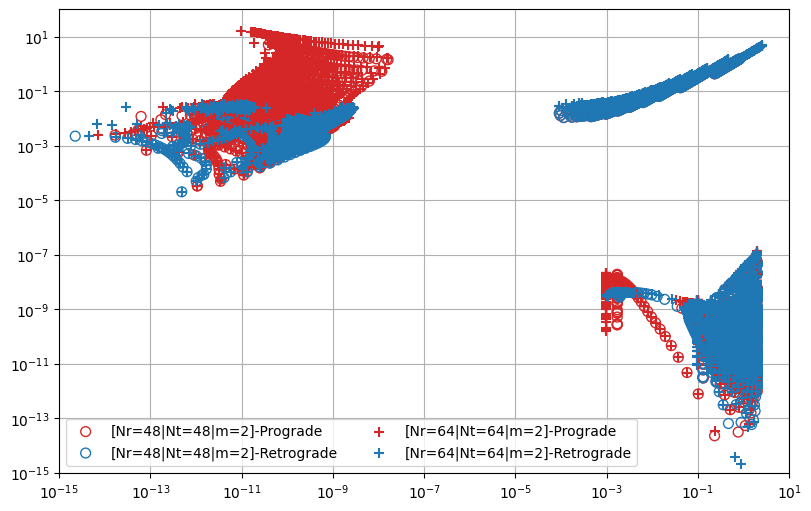

In [25]:
fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
markers_pro = [
    # {'marker': 's', 'facecolor': 'none', 'edgecolors': 'tab:red'},
    {'marker': 'o', 'facecolor': 'none', 'edgecolors': 'tab:red'}, 
    # {'marker': 'x', 'c': 'tab:red'}, 
    {'marker': '+', 'c': 'tab:red'}, 
]
markers_retro = [
    # {'marker': 's', 'facecolor': 'none', 'edgecolors': 'tab:blue'},
    {'marker': 'o', 'facecolor': 'none', 'edgecolors': 'tab:blue'}, 
    # {'marker': 'x', 'c': 'tab:blue'}, 
    {'marker': '+', 'c': 'tab:blue'}, 
]

for i_res, eigvals in enumerate(spec_list[0]):
    eig_view = eigvals[np.imag(eigvals) < 0]
    ax.scatter(np.abs(np.imag(eig_view)), -np.real(eig_view), 50, label='[{}]-Prograde'.format(res_list[i_res]), 
        **markers_pro[i_res], zorder=5)

    eig_view = eigvals[np.imag(eigvals) > 0]
    ax.scatter(np.abs(np.imag(eig_view)), -np.real(eig_view), 50, label='[{}]-Retrograde'.format(res_list[i_res]), 
        **markers_retro[i_res], zorder=5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.get_ylim()
ax.autoscale(enable=False, axis='y')
# ax.set_xlim(1e-1, 1e+1)
# ax.set_ylim(1e-15, 1e-7)
ax.set_xlim(1e-15, 1e+1)
ax.set_ylim(1e-15, 1e+2)

ax.grid(which='major')
ax.legend(ncols=2, loc=3)
plt.show()

In [30]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
ax.set_xscale('log')
# ax.set_yscale('symlog', linthresh=1e-2, linscale=0.1)
ax.set_yscale('log')
ax.set_xlim(1e-7, 1e+1)
# ax.set_ylim(-1e+3, 1e+3)
ax.set_ylim(1e-15, 1e+2)

eigvals = spectra[0][ifilter[0]]
eig_view = eigvals[np.imag(eigvals) < 0]
sc_pro = ax.scatter(np.abs(np.imag(eig_view)), -np.real(eig_view), 40, label='Prograde', 
    marker='>', edgecolors='tab:red', facecolor='none', zorder=5)

eig_view = eigvals[np.imag(eigvals) > 0]
sc_retro = ax.scatter(np.abs(np.imag(eig_view)), -np.real(eig_view), 40, label='Retrograde', 
    marker='<', edgecolors='tab:blue', facecolor='none', zorder=5)

# l_range = np.arange(4, 16)
# ax.vlines(2*m/l_range/(l_range+1), -1e+3, 1e+3, label='Rossby wave frequencies', 
#     colors='silver', linestyles='--', zorder=4)

ax.grid(which='major')
ax.legend(loc=3)

pars = par_list[0]
Em, Le, m = pars['Em'], pars['Le'], 2
title = ax.set_title('Em={:.2e}|Le={:.2e}|m={:d}'.format(Em, Le, m))

def animate(i):
    eigvals = spectra[i][ifilter[i]]
    eig_view = eigvals[np.imag(eigvals) < 0]
    sc_pro.set_offsets(np.stack([np.abs(np.imag(eig_view)), -np.real(eig_view)], axis=-1))

    eig_view = eigvals[np.imag(eigvals) > 0]
    sc_retro.set_offsets(np.stack([np.abs(np.imag(eig_view)), -np.real(eig_view)], axis=-1))

    pars = par_list[i]
    Em, Le, m = pars['Em'], pars['Le'], 2
    title.set_text('Em={:.2e}|Le={:.2e}|m={:d}'.format(Em, Le, m))

anima = animation.FuncAnimation(fig, animate, frames=len(spectra))
plt.close()
HTML(anima.to_jshtml())

In [72]:
import matplotlib.animation as animation
from IPython.display import HTML

markers = {
    ('Pro', 'Conv'): {'marker': '>', 'c': 'm', 'label': 'Prograde', 'zorder': 5},
    ('Pro', 'N/Conv'): {'marker': '>', 'c': 'thistle', 'label': 'Prograde (N/Converged)', 'zorder': 4}, 
    ('Retro', 'Conv'): {'marker': '<', 'c': 'teal', 'label': 'Retrograde', 'zorder': 5}, 
    ('Retro', 'N/Conv'): {'marker': '<', 'c': 'turquoise', 'label': 'Retrograde (N/Converged)', 'zorder': 4}, 
}

def plot_spectrum_subset(ax, spectrum, i_subset, marker_key):
    x, y = np.abs(np.imag(spectrum[i_subset])), -np.real(spectrum[i_subset])
    # print(markers[marker_key]['label'], np.sum(i_subset))
    sc = ax.scatter(x, y, **markers[marker_key])
    return sc

fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
ax.set_xscale('log')
# ax.set_yscale('symlog', linthresh=1e-2, linscale=0.1)
ax.set_yscale('log')
ax.set_xlabel(r'$|\omega|$', fontsize=12)
ax.set_ylabel(r'$\sigma$', fontsize=12)
ax.set_xlim(1e-2, 3e+0)
# ax.set_ylim(-1e+3, 1e+3)
ax.set_ylim(1e-15, 1e-3)

sc_pro_conv = plot_spectrum_subset(ax, spectra[0], (np.imag(spectra[0]) < 0) & ifilter[0], ('Pro', 'Conv'))
sc_pro_ncon = plot_spectrum_subset(ax, spectra[0], (np.imag(spectra[0]) < 0) & (~ifilter[0]), ('Pro', 'N/Conv'))
# sc_ret_conv = plot_spectrum_subset(ax, spectra[0], (np.imag(spectra[0]) > 0) & ifilter[0], ('Retro', 'Conv'))
# sc_ret_ncon = plot_spectrum_subset(ax, spectra[0], (np.imag(spectra[0]) > 0) & (~ifilter[0]), ('Retro', 'N/Conv'))

ax.grid(which='major')
ax.legend(loc=3)

pars = par_list[0]
Em, Le, m = pars['Em'], pars['Le'], 2
title = ax.set_title('Em={:.2e}|Le={:.2e}|m={:d}'.format(Em, Le, m))

def animate(i):
    eig_view = spectra[i][ifilter[i] & (np.imag(spectra[i]) < 0)]
    sc_pro_conv.set_offsets(np.stack([np.abs(np.imag(eig_view)), -np.real(eig_view)], axis=-1))

    eig_view = spectra[i][(~ifilter[i]) & (np.imag(spectra[i]) < 0)]
    sc_pro_ncon.set_offsets(np.stack([np.abs(np.imag(eig_view)), -np.real(eig_view)], axis=-1))

    # eig_view = spectra[i][ifilter[i] & (np.imag(spectra[i]) > 0)]
    # sc_ret_conv.set_offsets(np.stack([np.abs(np.imag(eig_view)), -np.real(eig_view)], axis=-1))

    # eig_view = spectra[i][(~ifilter[i]) & (np.imag(spectra[i]) > 0)]
    # sc_ret_ncon.set_offsets(np.stack([np.abs(np.imag(eig_view)), -np.real(eig_view)], axis=-1))

    pars = par_list[i]
    Em, Le, m = pars['Em'], pars['Le'], 2
    title.set_text('Em={:.2e}|Le={:.2e}|m={:d}'.format(Em, Le, m))

anima = animation.FuncAnimation(fig, animate, frames=len(spectra))
plt.close()
HTML(anima.to_jshtml())

In [73]:
anima.save('./runs/S1_Le_Eeta_mesh_m2/spectrum/var_Em/evolution_iw_pograde.mp4', dpi=120, fps=8)

Output individual frames

1/9 spectra output.
2/9 spectra output.
3/9 spectra output.
4/9 spectra output.
5/9 spectra output.
6/9 spectra output.
7/9 spectra output.
8/9 spectra output.
9/9 spectra output.


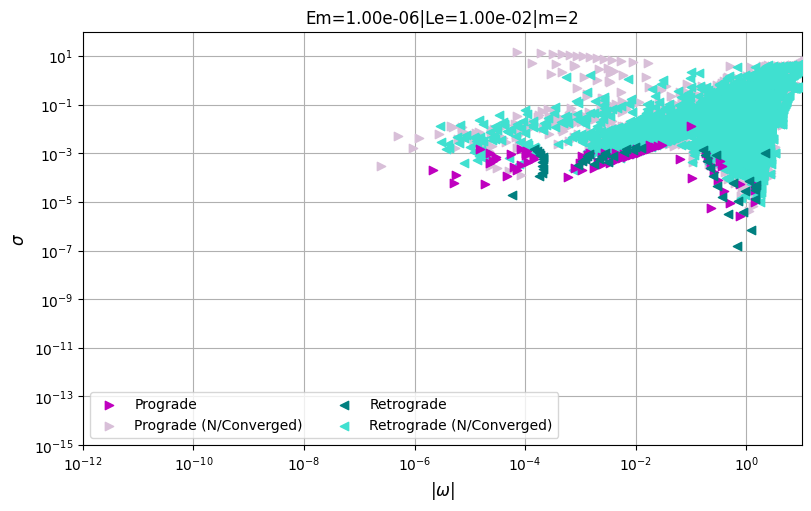

In [50]:
markers = {
    ('Pro', 'Conv'): {'marker': '>', 'c': 'm', 'label': 'Prograde', 'zorder': 5},
    ('Pro', 'N/Conv'): {'marker': '>', 'c': 'thistle', 'label': 'Prograde (N/Converged)', 'zorder': 4}, 
    ('Retro', 'Conv'): {'marker': '<', 'c': 'teal', 'label': 'Retrograde', 'zorder': 5}, 
    ('Retro', 'N/Conv'): {'marker': '<', 'c': 'turquoise', 'label': 'Retrograde (N/Converged)', 'zorder': 4}, 
}
out_dir = './runs/S1_Le_Eeta_mesh_m2/spectrum/var_Le'

def plot_spectrum_subset(ax, spectrum, i_subset, marker_key):
    x, y = np.abs(np.imag(spectrum[i_subset])), -np.real(spectrum[i_subset])
    sc = ax.scatter(x, y, **markers[marker_key])
    return sc

fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$|\omega|$', fontsize=12)
ax.set_ylabel(r'$\sigma$', fontsize=12)
ax.set_xlim(1e-12, 1e+1)
ax.set_ylim(1e-15, 1e+2)

sc_pro_conv = plot_spectrum_subset(ax, spectra[0], (np.imag(spectra[0]) < 0) & ifilter[0], ('Pro', 'Conv'))
sc_pro_ncon = plot_spectrum_subset(ax, spectra[0], (np.imag(spectra[0]) < 0) & (~ifilter[0]), ('Pro', 'N/Conv'))
sc_ret_conv = plot_spectrum_subset(ax, spectra[0], (np.imag(spectra[0]) > 0) & ifilter[0], ('Retro', 'Conv'))
sc_ret_ncon = plot_spectrum_subset(ax, spectra[0], (np.imag(spectra[0]) > 0) & (~ifilter[0]), ('Retro', 'N/Conv'))

ax.grid(which='major')
ax.legend(ncols=2, loc=3)

pars = par_list[0]
Em, Le, m = pars['Em'], pars['Le'], 2
title = ax.set_title('Em={:.2e}|Le={:.2e}|m={:d}'.format(Em, Le, m))

for i in range(len(spectra)):
    eig_view = spectra[i][ifilter[i] & (np.imag(spectra[i]) < 0)]
    sc_pro_conv.set_offsets(np.stack([np.abs(np.imag(eig_view)), -np.real(eig_view)], axis=-1))

    eig_view = spectra[i][(~ifilter[i]) & (np.imag(spectra[i]) < 0)]
    sc_pro_ncon.set_offsets(np.stack([np.abs(np.imag(eig_view)), -np.real(eig_view)], axis=-1))

    eig_view = spectra[i][ifilter[i] & (np.imag(spectra[i]) > 0)]
    sc_ret_conv.set_offsets(np.stack([np.abs(np.imag(eig_view)), -np.real(eig_view)], axis=-1))

    eig_view = spectra[i][(~ifilter[i]) & (np.imag(spectra[i]) > 0)]
    sc_ret_ncon.set_offsets(np.stack([np.abs(np.imag(eig_view)), -np.real(eig_view)], axis=-1))

    pars = par_list[i]
    Em, Le, m = pars['Em'], pars['Le'], 2
    title.set_text('Em={:.2e}|Le={:.2e}|m={:d}'.format(Em, Le, m))

    plt.savefig(os.path.join(out_dir, f'{i}.png'), dpi=120)
    print(f'{i+1}/{len(spectra)} spectra output.')

plt.show()

---
## Spheroical coordinate system

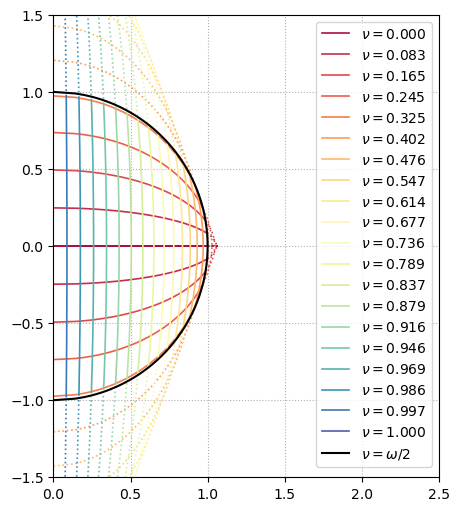

In [155]:
def spheroidal_lines(nu, mu, omega = 1.):
    s = 1/np.sqrt(1 - omega**2/4)*np.sqrt(1 - nu**2)*np.sqrt(1 - mu**2)
    z = 2/omega*nu*mu
    return s, z

def plot_coordinate_line(s, z, ax, label=None, **kwargs):
    i_interior = np.sqrt(s**2 + z**2) <= 1.
    s_tmp, z_tmp = s.copy(), z.copy()
    s_tmp[~i_interior] = np.nan
    z_tmp[~i_interior] = np.nan
    ax.plot(s_tmp, z_tmp, '-', label=label, **kwargs)
    s_tmp, z_tmp = s.copy(), z.copy()
    s_tmp[i_interior] = np.nan
    z_tmp[i_interior] = np.nan
    ax.plot(s_tmp, z_tmp, ':', **kwargs)

omega_coord = 0.66666
mu_array = np.linspace(-1, 1, num=200)
# nu_array = np.array([0., 0.1, 0.2, 0.3, 0.4, 0.5])*omega_coord
# nu_array = np.linspace(0., 1., num=20)
nu_array = np.sin(np.linspace(0., np.pi/2, num=20))
nu_colors = plt.cm.Spectral((np.arange(nu_array.size) + 0.5)/nu_array.size)

fig, ax = plt.subplots(figsize=(4.5, 5), layout='constrained')
for i_nu, nu in enumerate(nu_array):
    s_pts, z_pts = spheroidal_lines(nu, mu_array, omega=omega_coord)
    # ax.plot(s_pts, z_pts, '-', label=r'$\nu=%.3f$' % nu, color=nu_colors[i_nu])
    plot_coordinate_line(s_pts, z_pts, ax, label=r'$\nu=%.3f$' % nu, color=nu_colors[i_nu], linewidth=1.2)
s_pts, z_pts = spheroidal_lines(omega_coord/2, mu_array, omega=omega_coord)
# ax.plot(s_pts, z_pts, 'k-', label=r'$\nu=\omega/2$')
plot_coordinate_line(s_pts, z_pts, ax, label=r'$\nu=\omega/2$', color='k')

ax.set_aspect('equal')
ax.set_xlim([+0.0, +2.5])
ax.set_ylim([-1.5, +1.5])
ax.legend(fontsize=10)
ax.grid(which='both', linestyle=':')

fname = f'./docs/Inertial_modes/spheroidal_coordinates_omega_{omega_coord:.3f}'
# fname = None
if fname is not None:
    plt.savefig(fname + '.pdf', bbox_inches='tight')
    plt.savefig(fname + '.png', bbox_inches='tight', dpi=300)
plt.show()

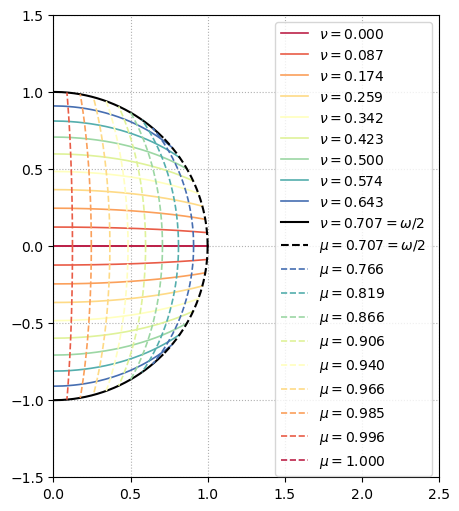

In [7]:
def spheroidal_lines(nu, mu, omega = 1.):
    s = 1/np.sqrt(1 - omega**2/4)*np.sqrt(1 - nu**2)*np.sqrt(1 - mu**2)
    z = 2/omega*nu*mu
    return s, z

def plot_coordinate_line(s, z, ax, *args, label=None, **kwargs):
    ax.plot(s, z, *args, label=label, **kwargs)
    # i_interior = np.sqrt(s**2 + z**2) <= 1.
    # s_tmp, z_tmp = s.copy(), z.copy()
    # s_tmp[~i_interior] = np.nan
    # z_tmp[~i_interior] = np.nan
    # ax.plot(s_tmp, z_tmp, '-', label=label, **kwargs)
    # s_tmp, z_tmp = s.copy(), z.copy()
    # s_tmp[i_interior] = np.nan
    # z_tmp[i_interior] = np.nan
    # ax.plot(s_tmp, z_tmp, ':', **kwargs)

omega_coord = np.sqrt(2)
nu_list = np.sin(np.linspace(0., np.arcsin(omega_coord/2), num=10))[:-1]
mu_list = np.sin(np.linspace(np.arcsin(omega_coord/2), np.pi/2, num=10))[1:]
nu_array = np.r_[-np.linspace(0, omega_coord/2, num=200), np.nan, np.linspace(0, omega_coord/2, num=200)]
mu_array = np.r_[-np.linspace(omega_coord/2, 1, num=200), np.nan, np.linspace(omega_coord/2, 1, num=200)]
nu_colors = plt.cm.Spectral((np.arange(nu_list.size) + 0.5)/nu_list.size)
mu_colors = plt.cm.Spectral_r((np.arange(mu_list.size) + 0.5)/mu_list.size)

fig, ax = plt.subplots(figsize=(4.5, 5), layout='constrained')
for i_nu, nu in enumerate(nu_list):
    s_pts, z_pts = spheroidal_lines(nu, mu_array, omega=omega_coord)
    # plot_coordinate_line(s_pts, z_pts, ax, label=r'$\nu=%.3f$' % nu, color=nu_colors[i_nu], linewidth=1.2)
    plot_coordinate_line(s_pts, z_pts, ax, '-', label=r'$\nu=%.3f$' % nu, color=nu_colors[i_nu], linewidth=1.2)
s_pts, z_pts = spheroidal_lines(omega_coord/2, mu_array, omega=omega_coord)
# ax.plot(s_pts, z_pts, 'k-', label=r'$\nu=\omega/2$')
plot_coordinate_line(s_pts, z_pts, ax, label=r'$\nu=%.3f=\omega/2$' % (omega_coord/2), color='k')
s_pts, z_pts = spheroidal_lines(nu_array, omega_coord/2, omega=omega_coord)
# ax.plot(s_pts, z_pts, 'k-', label=r'$\nu=\omega/2$')
plot_coordinate_line(s_pts, z_pts, ax, '--', label=r'$\mu=%.3f=\omega/2$' % (omega_coord/2,), color='k')
for i_mu, mu in enumerate(mu_list):
    s_pts, z_pts = spheroidal_lines(nu_array, mu, omega=omega_coord)
    # plot_coordinate_line(s_pts, z_pts, ax, label=r'$\mu=%.3f$' % mu, color=mu_colors[i_nu], linewidth=1.2)
    plot_coordinate_line(s_pts, z_pts, ax, '--', label=r'$\mu=%.3f$' % mu, color=mu_colors[i_mu], linewidth=1.2)

ax.set_aspect('equal')
ax.set_xlim([+0.0, +2.5])
ax.set_ylim([-1.5, +1.5])
ax.legend(fontsize=10)
ax.grid(which='both', linestyle=':')

fname = f'./docs/Inertial_modes/spheroidal_coordinates_omega_{omega_coord:.3f}_mu-nu'
# fname = None
if fname is not None:
    plt.savefig(fname + '.pdf', bbox_inches='tight')
    plt.savefig(fname + '.png', bbox_inches='tight', dpi=300)
plt.show()

----
## Misc data manipulation

In [ ]:
model_dir = './runs/Axial_Le_Eeta_mesh/'
Le_list = np.logspace(-6, -2, num=9)
Em_list = np.logspace(-8, -2, num=13)
Le_mesh, Em_mesh = np.meshgrid(Le_list, Em_list, indexing='ij')

with h5py.File(os.path.join(model_dir, 'emodes_mesh.h5'), 'w') as fwrite:
    n_gp = 0
    fwrite.create_dataset('Le', data=Le_list)
    fwrite.create_dataset('Em', data=Em_list)
    
    with h5py.File(os.path.join(model_dir, 'emodes.h5'), 'r') as fread:
        n_eigs = fread['eigenvals'].shape[1]
        n_evs = fread['eigenvals'].shape[-1]
        shape = (Le_list.size, Em_list.size, n_evs)
        
        for i_eig in range(n_eigs):
            gp = fwrite.create_group(f'eig_{n_gp}')
            gp.create_dataset('eigenvals', data=np.reshape(fread['eigenvals'][:, i_eig, :], shape))
            gp.create_dataset('eigenvecs', data=np.reshape(fread['eigenvecs'][:, i_eig, ...], (*shape, -1)))
            n_gp += 1

---
## Solar inertial modes

In [2]:
import sympy as sym
from inertial_modes import s, z, r, phi, theta
alpha = sym.Symbol(r'\alpha')

map_cyl2sph = {s: r*sym.sin(theta), z: r*sym.cos(theta)}

def cross(vA, vB):
    prod_A_B = [
        vA[1]*vB[2] - vA[2]*vB[1],
        vA[2]*vB[0] - vA[0]*vB[2],
        vA[0]*vB[1] - vA[1]*vB[0],
    ]
    return prod_A_B

def dot(vA, vB):
    prod_A_B = vA[0]*vB[0] + vA[1]*vB[1] + vA[2]*vB[2]
    return prod_A_B

def conj(vA):
    v_conj = [sym.conjugate(v_comp) for v_comp in vA]
    return v_conj

def curl_sph_m(v, m_val):
    curl_v = [
        (sym.diff(sym.sin(theta)*v[2], theta) - sym.I*m_val*v[1])/(r*sym.sin(theta)),
        (sym.I*m_val*v[0]/sym.sin(theta) - sym.diff(r*v[2], r))/r,
        (sym.diff(r*v[1], r) - sym.diff(v[0], theta))/r
    ]
    return curl_v

def curl_cyl_m(v, m_val):
    curl_v = [
        sym.I*m_val/s*v[2] - sym.diff(v[1], z),
        sym.diff(v[0], z) - sym.diff(v[2], s),
        sym.diff(s*v[1], s)/s - sym.I*m_val/s*v[0]
    ]
    return curl_v

In [3]:
Omega0 = 456        # [nHz]

def rossby_thin_shell(m, l):
    return 2*m/l/(l + 1)

def sectoral_rossby(m):
    return float(m_inert.eigenfreq_inviscid(0, m, parity='a', n=18)[0])

def hfr_full_sphere(m):
    return float(m_inert.eigenfreq_inviscid(1, m, parity='s', n=18)[1])

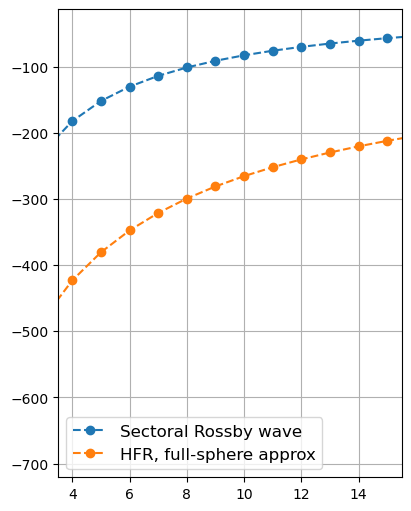

In [4]:
m_arr = np.arange(1, 20)
omega_sec_rossby = np.array([sectoral_rossby(m_tmp) for m_tmp in m_arr])
omega_hfr = np.array([hfr_full_sphere(m_tmp) for m_tmp in m_arr])

fig, ax = plt.subplots(figsize=(4, 5), layout='constrained')
ax.plot(m_arr, -Omega0*omega_sec_rossby, 'o--', label='Sectoral Rossby wave')
ax.plot(m_arr, -Omega0*omega_hfr, 'o--', label='HFR, full-sphere approx')
ax.grid(which='major')
ax.set_xlim([3.5, 15.5])
ax.legend(fontsize=12)
plt.show()

### Polynomial inertial solution

In [18]:
m_val = 3
N_geo = 1
i_val = 1
symmetry = 'S'
n_sph = m_val + 2*N_geo + (symmetry=='A')

mode_name = f'({m_val},{N_geo},{i_val+1}){symmetry}'
mode_code = f'{m_val}{N_geo}{i_val+1}{symmetry}'
mode_name_sph = f'({m_val},{n_sph},{i_val+1})'
mode_code_sph = f'{m_val}{n_sph}{i_val+1}'

# Frequency
omega_list = m_inert.eigenfreq_inviscid(N_geo, m_val, parity=symmetry.lower(), n=18)
omega_0 = omega_list[i_val]
sigma_0 = omega_0/2
lambda_0 = sym.I*omega_0
print(omega_list)

# Pressure
p_cyl = m_inert.pressure_mode_invisicid(N_geo, parity=symmetry.lower()).subs({m_inert.m: m_val})
p_sph = p_cyl.subs(map_cyl2sph)

# Velocity
u0_cyl = m_inert.eigenmode_poly_inviscid(N_geo, parity=symmetry.lower())
u0_cyl = [u_comp.subs({m_inert.m: m_val}) for u_comp in u0_cyl]
u0_sph = [u_comp.subs(map_cyl2sph) for u_comp in u0_cyl]
u0_sph = [
    u0_sph[0]*sym.sin(theta) + u0_sph[2]*sym.cos(theta), 
    u0_sph[0]*sym.cos(theta) - u0_sph[2]*sym.sin(theta),
    u0_sph[1]
]

parsub = {
    m_inert.elamb: lambda_0, 
    m_inert.sigma: sigma_0, 
    alpha: (1 + sym.I*sym.sign(sym.im(lambda_0)))*sym.sqrt(sym.Abs(sym.im(lambda_0))/2)}
print(mode_name, ':', lambda_0)
print(mode_name_sph, ':', lambda_0)

[-0.253197264742180826 1.05319726474218083]
(3,1,2)S : 1.05319726474218083*I
(3,5,2) : 1.05319726474218083*I


z-profiles

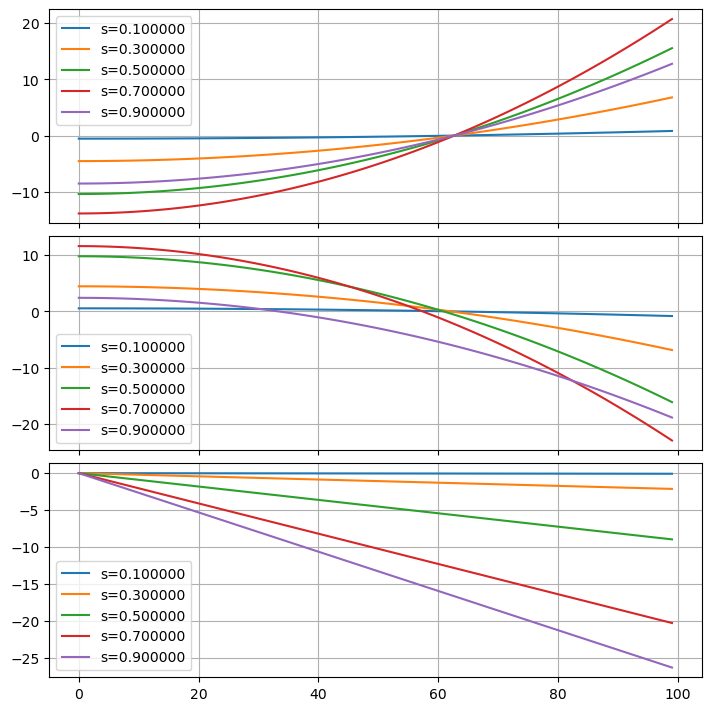

In [19]:
u0_f = [sym.lambdify([m_inert.s, m_inert.z, m_inert.sigma], comp, modules=['scipy', 'numpy'])
    for comp in u0_cyl]

s_locs = [0.1, 0.3, 0.5, 0.7, 0.9]
z_arr = np.linspace(0., 1., num=100)

def plot_profile(f, s_loc, z, sigma, ax, label=None):
    H = np.sqrt(1 - s_loc**2)
    f_vals = f(s_loc, H*z, sigma)
    ax.plot(np.real(f_vals) + np.imag(f_vals), label=label)

fig, axes = plt.subplots(nrows=3, figsize=(7, 7), layout='constrained', sharex=True)
for i_comp in range(3):
    ax = axes[i_comp]
    for i_s, s_tmp in enumerate(s_locs):
        plot_profile(u0_f[i_comp], s_tmp, z_arr, float(sigma_0), ax, label='s=%f' % s_tmp)
    ax.legend(fontsize=10)
    ax.grid(True, which='both')
    
plt.show()

Poloidal vs toroidal, spherical harmonic

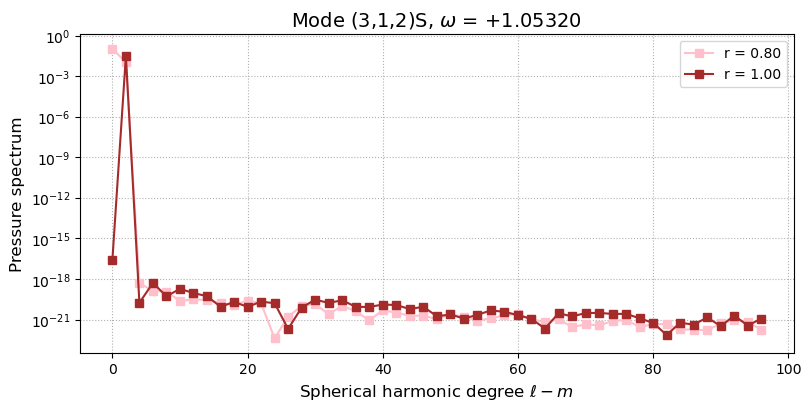

In [20]:
N_SH = 100

p_func = sym.lambdify([r, theta], p_sph.subs(parsub), modules=['numpy', 'scipy'])
r_list = [0.8, 1.0]
r_colors = ['pink', 'brown']
# r_colors = plt.cm.tab10(np.linspace(0., 1., num=len(r_list)))
l_arr = np.arange(m_val, N_SH + 1)
i_0 = slice(0, None, 2)
i_1 = slice(1, None, 2)

code_sphtp = 'Mode {}, $\\omega$ = {:+.5f}'.format(mode_name, complex(lambda_0).imag)

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
for ir, r_SH in enumerate(r_list):
    p_SHc = m_inert.transform_SH(lambda cla: p_func(r_SH, cla), N_SH, m_val=m_val)
    # ax.plot(np.abs(p_SHc), 's:', label='r = {:.2f}'.format(r_SH), color=r_colors[ir])
    if symmetry == 'S':
        ax.plot(l_arr[i_0] - m_val, np.abs(p_SHc[i_0]), 's-', label='r = {:.2f}'.format(r_SH), color=r_colors[ir])
    else:
        ax.plot(l_arr[i_1] - m_val, np.abs(p_SHc[i_1]), 's-', label='r = {:.2f}'.format(r_SH), color=r_colors[ir])
ax.set_yscale('log')
ax.set_xlabel('Spherical harmonic degree $\\ell - m$', fontsize=12)
ax.set_ylabel('Pressure spectrum', fontsize=12)
ax.grid(which='both', linestyle=':')
ax.set_title(code_sphtp, fontsize=14)
ax.legend(fontsize=10)

fname = f'./docs/Inertial_modes/SHc-p_{mode_code}'
fname = None
if fname is not None:
    plt.savefig(fname + '.png', bbox_inches='tight', dpi=150)
    plt.savefig(fname + '.pdf', bbox_inches='tight')
plt.show()

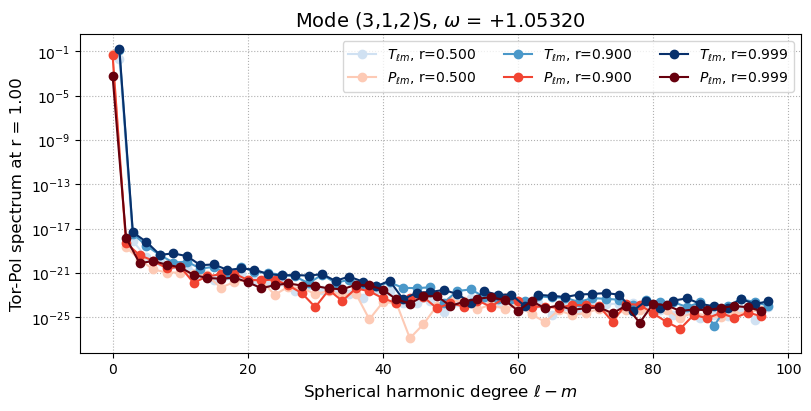

In [21]:
N_SH = 100

u0_r_func = sym.lambdify([r, theta], u0_sph[0].subs(parsub), modules=['numpy', 'scipy'])
curl_u0_r_func = sym.lambdify([r, theta], curl_sph_m(u0_sph, m_val=m_val)[0].subs(parsub), modules=['numpy', 'scipy'])

r_list = [0.5, 0.9, 1. - 1e-3]
# r_colors_pol = plt.cm.Reds(np.array(r_list))
# r_colors_tor = plt.cm.Blues(np.array(r_list))
r_colors_pol = plt.cm.Reds(np.linspace(0.2, 1., num=len(r_list)))
r_colors_tor = plt.cm.Blues(np.linspace(0.2, 1., num=len(r_list)))
l_arr = np.arange(m_val, N_SH + 1)
i_0 = slice(0, None, 2)
i_1 = slice(1, None, 2)

code_sphtp = 'Mode {}, $\\omega$ = {:+.5f}'.format(mode_name, complex(lambda_0).imag)

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
for ir, r_SH in enumerate(r_list):
    pol_SHc = m_inert.transform_SH(lambda z: u0_r_func(r_SH, z), N_SH, m_val=m_val)/(l_arr*(l_arr+1))
    tor_SHc = m_inert.transform_SH(lambda z: curl_u0_r_func(r_SH, z), N_SH, m_val=m_val)/(l_arr*(l_arr+1))
    # ax.plot(np.abs(tor_SHc), 'o:', label=r'$T_{\ell m}$, r=%.3f' % r_SH, color=r_colors_tor[ir])
    # ax.plot(np.abs(pol_SHc), 'o:', label=r'$P_{\ell m}$, r=%.3f' % r_SH, color=r_colors_pol[ir])
    if symmetry == 'S':
        ax.plot(l_arr[i_1] - m_val, np.abs(tor_SHc[i_1]), 'o-', label=r'$T_{\ell m}$, r=%.3f' % r_SH, color=r_colors_tor[ir])
        ax.plot(l_arr[i_0] - m_val, np.abs(pol_SHc[i_0]), 'o-', label=r'$P_{\ell m}$, r=%.3f' % r_SH, color=r_colors_pol[ir])
    else:
        ax.plot(l_arr[i_0] - m_val, np.abs(tor_SHc[i_0]), 'o-', label=r'$T_{\ell m}$, r=%.3f' % r_SH, color=r_colors_tor[ir])
        ax.plot(l_arr[i_1] - m_val, np.abs(pol_SHc[i_1]), 'o-', label=r'$P_{\ell m}$, r=%.3f' % r_SH, color=r_colors_pol[ir])
ax.set_yscale('log')
ax.grid(which='both', linestyle=':')
ax.set_xlabel('Spherical harmonic degree $\\ell - m$', fontsize=12)
ax.set_ylabel('Tor-Pol spectrum at r = {:.2f}'.format(r_SH), fontsize=12)
ax.legend(ncol=3)
ax.set_title(code_sphtp, fontsize=14)

fname = f'./docs/Inertial_modes/SHc-u_{mode_code}'
fname = None
if fname is not None:
    plt.savefig(fname + '.png', bbox_inches='tight', dpi=150)
    plt.savefig(fname + '.pdf', bbox_inches='tight')
plt.show()

In [22]:
nr, maxnl = 120, 100
Nr = 201
Nt = 201

rg = specfun.roots_chebyt(Nr*2 - (Nr % 2))[0][-Nr:]
tg = np.linspace(0, np.pi, Nt)
rr, tt = np.meshgrid(rg, tg)
X1, X2 = rr*np.sin(tt), rr*np.cos(tt)

u0_sph_val = [
    np.ones_like(rr)*sym.lambdify([m_inert.r, m_inert.theta], u_comp.subs(parsub), modules=['numpy', 'scipy'])(rr, tt)
    for u_comp in u0_sph
]

max_int_id = np.argmax(np.abs(u0_sph_val[2]).flatten())
max_int_val = u0_sph_val[2].flatten()[max_int_id]
for comp in range(len(u0_sph_val)):
    u0_sph_val[comp] /= max_int_val
    
fields = {
    'v0_r': u0_sph_val[0], 
    'v0_t': u0_sph_val[1],
    'v0_p': u0_sph_val[2], 
    'v0_s': (u0_sph_val[0]*np.sin(tt) + u0_sph_val[1]*np.cos(tt)), 
    'v0_z': (u0_sph_val[0]*np.cos(tt) - u0_sph_val[1]*np.sin(tt)),
}

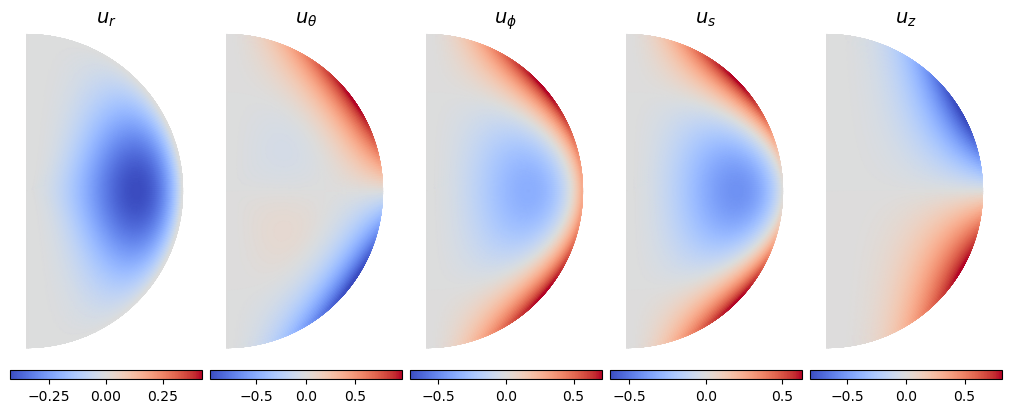

In [23]:
lon_view = 15
# save_name = f"./runs/Axial_Le_Eeta_mesh_m1/v_md_{mode_code}-{B0_code}_Le1e-4_Em1e-7_ub"
save_name = None
override = False

plot_fields = [
    ['v0_r', 'v0_t', 'v0_p', 'v0_s', 'v0_z'],
]
plot_fnames = [
    [r"$u_r$", r"$u_\theta$", r"$u_\phi$", r"$u_s$", r"$u_z$"],
]

force_symmetric_cmap = True
phase = np.exp(1j*m_val*np.radians(lon_view))
norm = np.max(np.abs(fields['v0_p']))
nrows, ncols = len(plot_fields), len(plot_fields[0])
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2, nrows*4), layout='constrained')
# fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2.4, nrows*2.1), layout='constrained')
axes = np.atleast_2d(axes)

maxvals = np.zeros(np.asarray(plot_fields).shape)
minvals = np.zeros(np.asarray(plot_fields).shape)
for i_r in range(nrows):
    for i_c in range(ncols):
        fname = plot_fields[i_r][i_c]
        if fname is None:
            maxvals[i_r, i_c] = np.nan
            minvals[i_r, i_c] = np.nan
            continue
        field_plot = np.real(fields[fname]*phase)/norm
        maxvals[i_r, i_c] = np.max(field_plot)
        minvals[i_r, i_c] = np.min(field_plot)
t_crit = np.arccos(0.5)

for i_r in range(nrows):
    for i_c in range(ncols):
        fname = plot_fields[i_r][i_c]
        ax = axes[i_r][i_c]
        if fname is None:
            ax.remove()
            continue
        field_plot = np.real(fields[fname]*phase)/norm
        if np.abs(field_plot).max() > 1e-7:
            if force_symmetric_cmap:
                climit = np.max(np.abs(field_plot))
                # climit = 0.7
                # climit = np.nanmax(np.abs([maxvals[0, i_c], maxvals[1, i_c], minvals[0, i_c], minvals[1, i_c]]))
                vmin, vmax = -climit, +climit
                cm = ax.pcolormesh(X1, X2, field_plot, shading="gouraud", cmap="coolwarm", vmin=vmin, vmax=vmax)
                # ax.scatter([np.sin(t_crit), np.sin(t_crit)], [np.cos(t_crit), -np.cos(t_crit)])
                plt.colorbar(cm, ax=ax, orientation='horizontal')
            else:
                cm = ax.pcolormesh(X1, X2, field_plot, shading="gouraud", cmap="coolwarm")
                plt.colorbar(cm, ax=ax, orientation='horizontal')
        else:
            cm = ax.pcolormesh(X1, X2, field_plot, shading="gouraud", cmap="coolwarm", vmin=-1e-7, vmax=+1e-7)
            plt.colorbar(cm, ax=ax, orientation='horizontal')
        
        ax.set_title(plot_fnames[i_r][i_c], fontsize=14)
        ax.set_aspect('equal', 'box')
        # ax.grid()
        ax.set_xlim([0, 1.02])
        ax.set_ylim([-1.02, 1.02])
        ax.axis("off")

if save_name is not None:
    if os.path.exists(save_name + '.png') and not override:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")
plt.show()

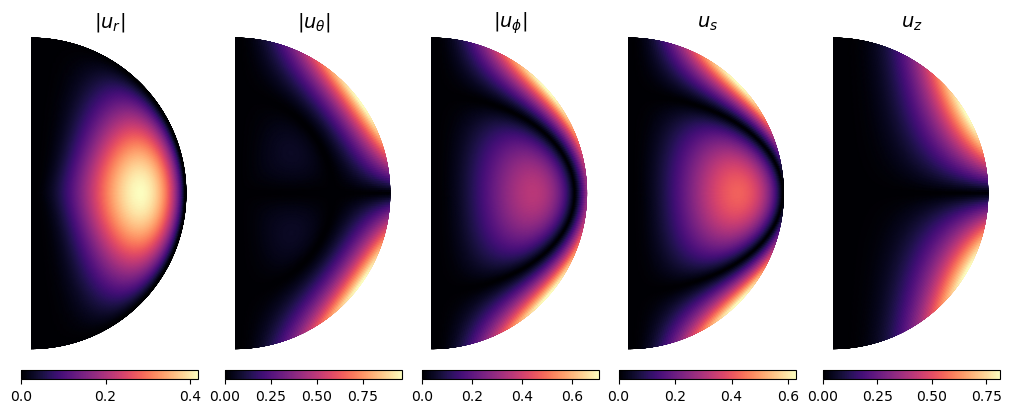

In [24]:
lon_view = 15
# save_name = f"./runs/Axial_Le_Eeta_mesh_m1/v_md_{mode_code}-{B0_code}_Le1e-4_Em1e-7_ub"
save_name = None
override = False

plot_fields = [
    ['v0_r', 'v0_t', 'v0_p', 'v0_s', 'v0_z'],
]
plot_fnames = [
    [r"$|u_r|$", r"$|u_\theta|$", r"$|u_\phi|$", r"$u_s$", r"$u_z$"],
]

force_symmetric_cmap = False
phase = np.exp(1j*m_val*np.radians(lon_view))
norm = np.max(np.abs(fields['v0_p']))
nrows, ncols = len(plot_fields), len(plot_fields[0])
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2, nrows*4), layout='constrained')
# fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2.4, nrows*2.1), layout='constrained')
axes = np.atleast_2d(axes)

maxvals = np.zeros(np.asarray(plot_fields).shape)
minvals = np.zeros(np.asarray(plot_fields).shape)
for i_r in range(nrows):
    for i_c in range(ncols):
        fname = plot_fields[i_r][i_c]
        if fname is None:
            maxvals[i_r, i_c] = np.nan
            minvals[i_r, i_c] = np.nan
            continue
        field_plot = np.real(fields[fname]*phase)/norm
        maxvals[i_r, i_c] = np.max(field_plot)
        minvals[i_r, i_c] = np.min(field_plot)
t_crit = np.arccos(0.5)

for i_r in range(nrows):
    for i_c in range(ncols):
        fname = plot_fields[i_r][i_c]
        ax = axes[i_r][i_c]
        if fname is None:
            ax.remove()
            continue
        field_plot = np.abs(np.real(fields[fname]*phase)/norm)
        if np.abs(field_plot).max() > 1e-7:
            cm = ax.pcolormesh(X1, X2, field_plot, shading="gouraud", cmap="magma")
            plt.colorbar(cm, ax=ax, orientation='horizontal')
        else:
            cm = ax.pcolormesh(X1, X2, field_plot, shading="gouraud", cmap="magma", vmin=0, vmax=+1e-7)
            plt.colorbar(cm, ax=ax, orientation='horizontal')
        
        ax.set_title(plot_fnames[i_r][i_c], fontsize=14)
        ax.set_aspect('equal', 'box')
        # ax.grid()
        ax.set_xlim([0, 1.02])
        ax.set_ylim([-1.02, 1.02])
        ax.axis("off")

if save_name is not None:
    if os.path.exists(save_name + '.png') and not override:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")
plt.show()

<lambdifygenerated-20>:2: RuntimeWarning: invalid value encountered in divide
  return (-3*1j*(-1j*(-55.4497764370146063*sin(Dummy_93)**4 - 138.389061035461346*sin(Dummy_93)**2*cos(Dummy_93)**2 + 55.4497764370146063*sin(Dummy_93)**2)*cos(Dummy_93) + 82.9392845984467401*1j*sin(Dummy_93)**4*cos(Dummy_93)) + (17.6986586220876376*sin(Dummy_93)**3*cos(Dummy_93) - 276.778122070922693*sin(Dummy_93)*cos(Dummy_93)**3 + 110.899552874029213*sin(Dummy_93)*cos(Dummy_93))*sin(Dummy_93) + (-64.7698658622087638*sin(Dummy_93)**4 - 138.389061035461346*sin(Dummy_93)**2*cos(Dummy_93)**2 + 55.4497764370146063*sin(Dummy_93)**2)*cos(Dummy_93))/sin(Dummy_93)


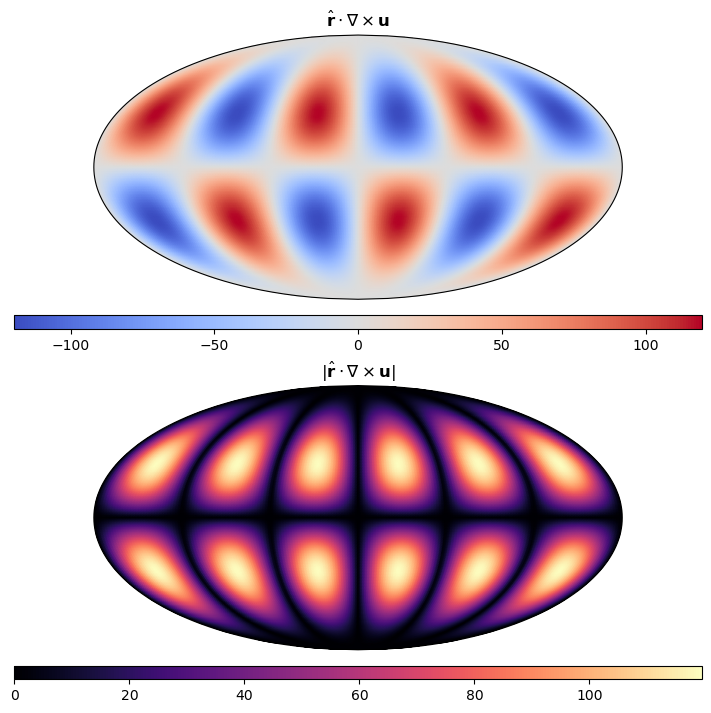

In [29]:
Np = 201
pg = np.linspace(-np.pi, +np.pi, num=Np)
tg = np.linspace(0, np.pi, num=Nt)

f_vorticity_r = sym.lambdify(
    [m_inert.theta], curl_sph_m(u0_sph, m_val)[0].subs({r: 1}).subs(parsub), modules=['numpy', 'scipy']
)
vorticity_r = np.outer(1j*f_vorticity_r(tg), np.exp(1j*m_val*pg))

import cartopy.crs as ccrs

lat_mesh, lon_mesh = np.meshgrid(90. - np.degrees(tg), np.degrees(pg), indexing='ij')

fig = plt.figure(figsize=(7, 7), layout='constrained')
ax = fig.add_subplot(2, 1, 1, projection=ccrs.Mollweide())
im = ax.pcolormesh(lon_mesh, lat_mesh, np.real(vorticity_r), 
    cmap='coolwarm', transform=ccrs.PlateCarree(), shading='gouraud')
ax.set_title(r'$\hat{\mathbf{r}}\cdot \nabla\times \mathbf{u}$')
plt.colorbar(im, ax=ax, orientation='horizontal', aspect=50)

ax = fig.add_subplot(2, 1, 2, projection=ccrs.Mollweide())
im = ax.pcolormesh(lon_mesh, lat_mesh, np.abs(np.real(vorticity_r)), 
    cmap='magma', transform=ccrs.PlateCarree(), shading='gouraud')
ax.set_title(r'$|\hat{\mathbf{r}}\cdot \nabla\times \mathbf{u}|$')
plt.colorbar(im, ax=ax, orientation='horizontal', aspect=50)

plt.show()

### Rossby waves

In [46]:
l_SH, m_SH = 15, 15

arr_lon = np.linspace(-180., +180., num=200)
arr_lat = np.linspace(-90., +90., num=200)
arr_cla = 90. - arr_lat
mesh_lat, mesh_lon = np.meshgrid(arr_lat, arr_lon, indexing='ij')

Plm, dPlm = specfun.sph_legendre_p(l_SH, m_SH, np.radians(arr_cla), diff_n=1)
m_phase = np.exp(1j*m_SH*np.radians(arr_lon))
Ylm = np.outer(Plm, m_phase)
surfcurl_Ylm_cla = np.outer(-1j*m_SH*Plm/np.sin(np.radians(arr_cla)), m_phase)
# surfcurl_Ylm_lon = np.outer(+dPlm*np.sin(np.radians(arr_cla)), m_phase)
surfcurl_Ylm_lon = np.outer(+dPlm, m_phase)

C:\Users\gentle\AppData\Local\Temp\ipykernel_24312\3685352661.py:11: RuntimeWarning: invalid value encountered in divide
  surfcurl_Ylm_cla = np.outer(-1j*m_SH*Plm/np.sin(np.radians(arr_cla)), m_phase)


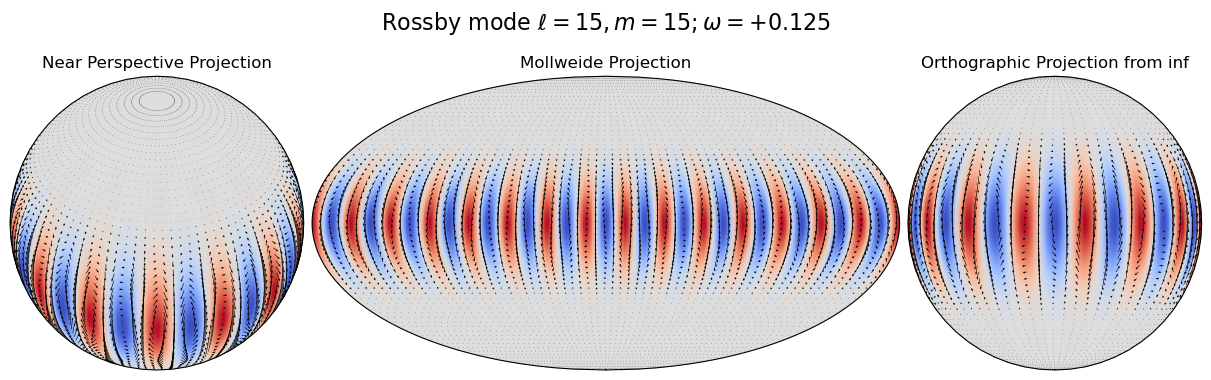

In [47]:
import cartopy.crs as ccrs

fig = plt.figure(figsize=(12, 4), layout='constrained')
gs = fig.add_gridspec(1, 4)

ax = fig.add_subplot(gs[0], projection=ccrs.NearsidePerspective(central_longitude=60, central_latitude=40))
ax.pcolormesh(mesh_lon, mesh_lat, np.real(Ylm), cmap='coolwarm', transform=ccrs.PlateCarree(), shading='gouraud')
i_lon = slice(0, None, 2)
i_lat = slice(0, -5, 3)
ax.quiver(
    arr_lon[i_lon], arr_lat[i_lat], 
    np.real(surfcurl_Ylm_lon[i_lat, i_lon]), np.real(-surfcurl_Ylm_cla[i_lat, i_lon]),
    scale=100, width=0.002, headlength=3, transform=ccrs.PlateCarree(), zorder=5
)
ax.set_title('Near Perspective Projection')

ax = fig.add_subplot(gs[1:3], projection=ccrs.Mollweide())
ax.pcolormesh(mesh_lon, mesh_lat, np.real(Ylm), cmap='coolwarm', transform=ccrs.PlateCarree(), shading='gouraud')
i_lon = slice(0, None, 3)
i_lat = slice(0, None, 3)
ax.quiver(
    arr_lon[i_lon], arr_lat[i_lat], 
    np.real(surfcurl_Ylm_lon[i_lat, i_lon]), np.real(-surfcurl_Ylm_cla[i_lat, i_lon]),
    scale=300, width=0.001, headlength=2, transform=ccrs.PlateCarree(), zorder=5
)
ax.set_title('Mollweide Projection')

ax = fig.add_subplot(gs[3], projection=ccrs.Orthographic())
ax.pcolormesh(mesh_lon, mesh_lat, np.real(Ylm), cmap='coolwarm', transform=ccrs.PlateCarree(), shading='gouraud')
i_lon = slice(0, None, 3)
i_lat = slice(0, None, 3)
ax.quiver(
    arr_lon[i_lon], arr_lat[i_lat], 
    np.real(surfcurl_Ylm_lon[i_lat, i_lon]), np.real(-surfcurl_Ylm_cla[i_lat, i_lon]),
    scale=100, width=0.002, headlength=3, transform=ccrs.PlateCarree(), zorder=5
)
ax.set_title('Orthographic Projection from inf')

fig.suptitle(r'Rossby mode $\ell=%d, m=%d; \omega=%+.3f$' % (l_SH, m_SH, 2*m_SH/l_SH/(l_SH+1)), fontsize=16)
plt.show()

### Damped harmonic oscillator plot

In [39]:
np.sqrt(np.e**2 - 1)

np.float64(2.5276582243117143)

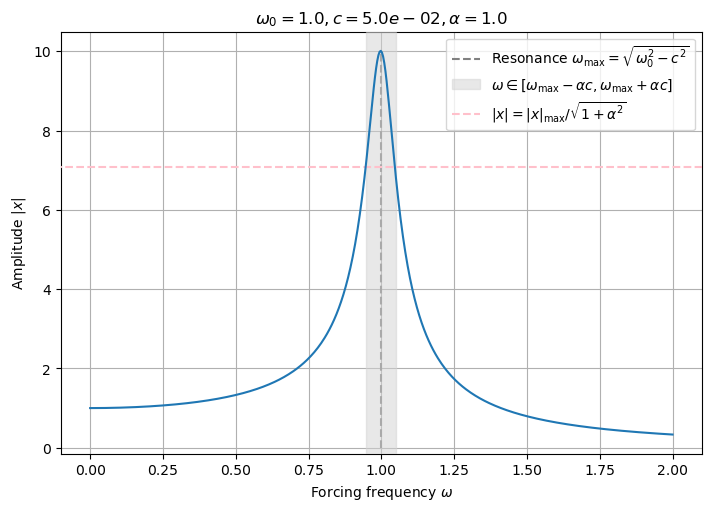

In [49]:
omega_i = 1.
c_damp = 0.05
omega_peak = np.sqrt(omega_i**2 - c_damp**2)
alpha = 1
# alpha = np.sqrt(np.e**1 - 1)
omega_scan = np.linspace(0., 2, num=500)
x_amp = np.abs(1/(omega_i**2 - omega_scan**2 + 2j*c_damp*omega_scan))
x_max = np.abs(1/(omega_i**2 - omega_peak**2 + 2j*c_damp*omega_peak))

fig, ax = plt.subplots(figsize=(7, 5), layout='constrained')
ax.plot(omega_scan, x_amp, '-', zorder=5)
ax.autoscale(enable=True)
ax.get_xlim()
ax.autoscale(enable=False)
ax.vlines([omega_peak], 0, 10, 
    label=r'Resonance $\omega_\mathrm{max} = \sqrt{\omega_0^2 - c^2}$', color='gray', linestyle='--', zorder=3)
ax.axvspan(omega_peak - alpha*c_damp, omega_peak + alpha*c_damp, 
    label=r'$\omega \in [\omega_\mathrm{max}-\alpha c, \omega_\mathrm{max}+\alpha c]$', color='lightgray', alpha=0.5, zorder=3)
ax.hlines([x_max/np.sqrt(1 + alpha**2)], -0.5, 2.5, 
    label=r'$|x| = |x|_\mathrm{max}/\sqrt{1 + \alpha^2}$', color='pink', linestyle='--', zorder=3)
ax.grid(which='major')
ax.legend()
ax.set_xlabel(r'Forcing frequency $\omega$')
ax.set_ylabel(r'Amplitude $|x|$')
ax.set_title(r'$\omega_0 = %.1f, c = %.1e, \alpha = %.1f$' % (omega_i, c_damp, alpha))
plt.show()